In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [ ]:
# jd=pd.read_csv('postings.csv')
# resume=pd.read_csv('resume_data.csv')
# name=pd.read_csv('Indian-Name.csv', encoding='latin1')
# cllg=pd.read_csv('College_Tier_Dataset.csv')
# bias=pd.read_csv('adult.csv.zip')

In [ ]:
# #checking
# datasets = {

#     "Job Description":jd ,
#     "Resumes": resume,
#     "Indian Names": name,
#     "College Tier": cllg,
#     "Adult (Fairness)": bias
# }

# for name_, df in datasets.items():
#     print("\n" + "="*50)
#     print(f"DATASET: {name_}")
#     print("Shape:", df.shape)
#     print("Columns:", df.columns.tolist())
#     print("\nSample rows:")
#     print(df.head().to_string(index=False))



DATASET: Job Description
Shape: (123849, 31)
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Sample rows:
  job_id           company_name                                                    title                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
# #cleaning resumes

# resume_clean = resume.copy()


# resume_clean = resume_clean.drop(columns=['responsibilities.1'], errors='ignore')


# resume_clean.columns = resume_clean.columns.str.strip().str.lower().str.replace('[^a-z0-9_]', '_', regex=True)


# threshold = 0.95
# resume_clean = resume_clean.dropna(axis=1, thresh=len(resume_clean)*(1-threshold))


# if 'address' in resume_clean.columns:
#     resume_clean = resume_clean.drop(columns=['address'])

# if 'online_links' in resume_clean.columns:
#     resume_clean = resume_clean.drop(columns=['online_links'])


# print("Shape after cleaning:", resume_clean.shape)
# print("Columns:", resume_clean.columns.tolist())
# print("\nSample rows:")
# print(resume_clean.head(3).to_string(index=False))



Shape after cleaning: (9544, 32)
Columns: ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'issue_dates', 'expiry_dates', '_job_position_name', 'educational_requirements', 'experiencere_requirement', 'age_requirement', 'skills_required', 'matched_score']

Sample rows:
                                                                                                                                                                                                                                                      career_objec

In [ ]:
# #job description cleaning
# import re

# def clean_job_descriptions(df):
#     # Copy to avoid modifying original DataFrame
#     job_clean = df.copy()
    
#     # Standardize columns: lowercase, strip, replace special chars with '_'
#     job_clean.columns = job_clean.columns.str.strip().str.lower().str.replace('[^a-z0-9_]', '_', regex=True)
    
#     # Select only useful columns relevant for matching and fairness
#     useful_cols = [
#         'job_id', 'title', 'description', 'skills_desc',
#         'location', 'company_name', 'formatted_experience_level',
#         'work_type', 'normalized_salary', 'currency'
#     ]
#     job_clean = job_clean.loc[:, job_clean.columns.intersection(useful_cols)]
    
#     # Drop rows where critical text fields are missing
#     job_clean = job_clean.dropna(subset=['title', 'description'])
    
#     # Remove duplicate job descriptions to avoid redundant data points
#     job_clean = job_clean.drop_duplicates(subset=['title', 'description', 'skills_desc'])
    
#     # Optional: Basic text cleaning (remove HTML tags, convert to lowercase)
#     def clean_text(text):
#         if pd.isna(text):
#             return ""
#         # Remove HTML tags
#         text = re.sub(r'<[^>]+>', ' ', text)
#         # Lowercase and strip extra spaces
#         text = text.lower().strip()
#         return text
    
#     for col in ['title', 'description', 'skills_desc']:
#         if col in job_clean.columns:
#             job_clean[col] = job_clean[col].apply(clean_text)
    
#     # Handle missing salaries by filling with median or flagging missingness
#     if 'normalized_salary' in job_clean.columns:
#         median_salary = job_clean['normalized_salary'].median()
#         job_clean['normalized_salary'] = job_clean['normalized_salary'].fillna(median_salary)
#         job_clean['salary_missing'] = job_clean['normalized_salary'].isna()
    
#     # Final checks and info
#     print(f"Shape after cleaning: {job_clean.shape}")
#     print(f"Columns after cleaning: {job_clean.columns.tolist()}")
#     print("\nSample rows:")
#     print(job_clean.head(3).to_string(index=False))
    
#     return job_clean

# # Usage
# job_clean = clean_job_descriptions(jd)


Shape after cleaning: (111148, 11)
Columns after cleaning: ['job_id', 'company_name', 'title', 'description', 'location', 'formatted_experience_level', 'skills_desc', 'work_type', 'currency', 'normalized_salary', 'salary_missing']

Sample rows:
  job_id           company_name                             title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
# #cleaning names
# name_clean = name.copy()


# name_clean = name_clean[['Name', 'Target']]


# name_clean.columns = ['name', 'gender']


# name_clean = name_clean.dropna().drop_duplicates()


# print("Shape after cleaning:", name_clean.shape)
# print("Gender distribution:\n", name_clean['gender'].value_counts())
# print("\nSample rows:")
# print(name_clean.head(10).to_string(index=False))


Shape after cleaning: (1184, 2)
Gender distribution:
 gender
0    619
1    565
Name: count, dtype: int64

Sample rows:
    name  gender
    Yash       1
    Prit       1
    Meet       1
 Drashti       0
  Saloni       0
   Hinal       0
     Jay       1
Darshana       0
  Hardik       1
   Janvi       0


In [ ]:
# #cleaning tier
# import re

# cllg_clean = cllg.copy()


# cllg_clean.columns = ['institution', 'tier']


# cllg_clean['institution'] = cllg_clean['institution'].str.strip().str.lower()


# cllg_clean['institution'] = cllg_clean['institution'].apply(
#     lambda x: re.sub(r'[^a-z0-9\s]', '', str(x))
# )


# cllg_clean = cllg_clean.drop_duplicates()


# print("Shape after cleaning:", cllg_clean.shape)
# print("Unique tiers:", cllg_clean['tier'].unique())
# print("\nSample rows:")
# print(cllg_clean.head(10).to_string(index=False))

# cllg_clean = cllg_clean[cllg_clean['institution'] != 'institution name']

# cllg_clean = cllg_clean.reset_index(drop=True)

# print("Shape after dropping header row:", cllg_clean.shape)
# print(cllg_clean.head(5).to_string(index=False))



Shape after cleaning: (983, 2)
Unique tiers: ['Tier' 'Tier1' 'Tier2' 'Tier3']

Sample rows:
                                              institution  tier
                                         institution name  Tier
                             acharya nagarjuna university Tier1
                                      alagappa university Tier1
                            aligarh muslim university amu Tier1
     all india institute of medical sciences aiims bhopal Tier1
all india institute of medical sciences aiims bhubaneswar Tier1
    all india institute of medical sciences aiims jodhpur Tier1
  all india institute of medical sciences aiims new delhi Tier1
      all india institute of medical sciences aiims patna Tier1
     all india institute of medical sciences aiims raipur Tier1
Shape after dropping header row: (982, 2)
                                              institution  tier
                             acharya nagarjuna university Tier1
                                  

In [ ]:
# def clean_bias_data(df):
#     df_clean = df.copy()
#     df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace('[^a-z0-9_]', '_', regex=True)
#     df_clean = df_clean.replace('?', pd.NA)
#     # Convert object columns to lowercase and trim spaces
#     for col in df_clean.select_dtypes(include='object').columns:
#         df_clean[col] = df_clean[col].str.strip().str.lower()
#     df_clean = df_clean.drop_duplicates().reset_index(drop=True)
#     print("Shape after cleaning:", df_clean.shape)
#     print("Columns:", df_clean.columns.tolist())
#     print("\nSample rows:")
#     print(df_clean.head(5).to_string(index=False))
#     return df_clean

# bias_clean = clean_bias_data(bias)


Shape after cleaning: (32537, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Sample rows:
 age workclass  fnlwgt    education  education_num marital_status        occupation  relationship  race    sex  capital_gain  capital_loss  hours_per_week native_country income
  90      <NA>   77053      hs-grad              9        widowed              <NA> not-in-family white female             0          4356              40  united-states  <=50k
  82   private  132870      hs-grad              9        widowed   exec-managerial not-in-family white female             0          4356              18  united-states  <=50k
  66      <NA>  186061 some-college             10        widowed              <NA>     unmarried black female             0          4356              40  united-states  <=50k
  54   private  140359      7th-8

In [ ]:
# #data enrichment
# %pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [ ]:

# from rapidfuzz import process, fuzz
# import pandas as pd


# try:
#     name_clean
# except NameError:
#     name_clean = pd.read_csv('/content/Indian-Name.csv', encoding='latin-1')
#     name_clean = name_clean[['Name','Target']].dropna().drop_duplicates()
#     name_clean.columns = ['name','gender']
#     name_clean['name'] = name_clean['name'].astype(str).str.strip()

# name_clean['name'] = name_clean['name'].str.lower().str.strip()


# name_dict = dict(zip(name_clean['name'], name_clean['gender']))

# print("Lookup size:", len(name_dict))
# print("\nFirst 5 entries:")
# for i, (k, v) in enumerate(name_dict.items()):
#     print(f"{k} -> {v}")
#     if i >= 4:
#         break


Lookup size: 1180

First 5 entries:
yash -> 1
prit -> 1
meet -> 1
drashti -> 0
saloni -> 0


In [ ]:
# def infer_gender(name_str, name_lookup=name_dict, scorer=fuzz.partial_ratio, cutoff=95):
#     """
#     Infer gender from a name string using fuzzy matching.
#     Args:
#         name_str (str): The name to classify.
#         name_lookup (dict): Mapping of names to gender labels.
#         scorer (function): Rapidfuzz scorer function.
#         cutoff (int): Minimum fuzzy match score for confident match.

#     Returns:
#         int or None: 1 for male, 0 for female, None if no confident match.
#     """
#     if pd.isna(name_str) or not isinstance(name_str, str) or name_str.strip()=="":
#         return None
#     # Extract first token, filter to alphabets only
#     token = name_str.strip().split()[0].lower()
#     token = ''.join(ch for ch in token if ch.isalpha())
#     match = process.extractOne(token, name_lookup.keys(), scorer=scorer, score_cutoff=cutoff)
#     if match:
#         matched_name, score = match[:2]
#         return name_lookup.get(matched_name)
#     return None


In [ ]:

# test_names = ["Yash Gupta", "Drashti Shah", "Saloni Mehta",
#               "Hardik Patel", "Janvi Sharma", "piyush",
#               "Sneha", "Rajat"]

# for n in test_names:
#     print(n, "->", infer_gender(n))


Yash Gupta -> 1
Drashti Shah -> 0
Saloni Mehta -> 0
Hardik Patel -> 1
Janvi Sharma -> 0
piyush -> 1
Sneha -> 0
Rajat -> 1


In [ ]:
# #no col with canidate name
# cand_cols = [c for c in resume_clean.columns if any(w in c for w in ['name','full','first','last','candidate','person'])]
# print("Possible name-like columns:", cand_cols)


# for c in cand_cols:
#     vals = resume_clean[c].dropna().astype(str).str.strip().unique()[:10]
#     print("\nCOLUMN:", c, " — sample non-null values (up to 10):")
#     print(vals)


Possible name-like columns: ['educational_institution_name', 'degree_names', 'professional_company_names', 'extra_curricular_organization_names', '_job_position_name']

COLUMN: educational_institution_name  — sample non-null values (up to 10):
["['The Amity School of Engineering & Technology (ASET), Noida']"
 "['Delhi University - Hansraj College', 'Delhi University - Hansraj College']"
 "['Birla Institute of Technology (BIT), Ranchi']"
 "['Martinez Adult Education, Business Training Center ï¼ City , State']"
 "['Kent State University']"
 "['Glen Oaks High School', 'Glen Oaks High School']"
 "['DJR College and University']"
 "['POLYTECHNIC UNIVERSITY OF PUERTO RICO']" "['Nagpur University']"
 "['Dr. Virendra Swaroop Institute of Computer Studies, Kanpur', 'Pranveer Singh Institute of Technology, Kanpur']"]

COLUMN: degree_names  — sample non-null values (up to 10):
["['B.Tech']" "['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']"
 "['Computer Applications Specialist Certificate Program']

In [ ]:
# #enriching resume with synthetic name and gender
# import numpy as np


# np.random.seed(42)
# sample_names = name_clean['name'].sample(len(resume_clean), replace=True).reset_index(drop=True)

# resume_clean['candidate_name'] = sample_names
# resume_clean['gender_inferred'] = resume_clean['candidate_name'].apply(lambda x: infer_gender(x))


# print("Shape:", resume_clean.shape)
# print("\nGender distribution:")
# print(resume_clean['gender_inferred'].value_counts())

# print("\nSample rows (candidate_name, gender_inferred):")
# print(resume_clean[['candidate_name','gender_inferred']].head(10).to_string(index=False))


Shape: (9544, 34)

Gender distribution:
gender_inferred
1    4831
0    4713
Name: count, dtype: int64

Sample rows (candidate_name, gender_inferred):
candidate_name  gender_inferred
         rajsi                1
      khushali                0
       chinmay                1
      tanishaa                0
           vir                1
         meena                0
       namrata                0
      ravindra                1
          devi                0
         alaya                0


In [ ]:
# #creating dictonary for fast lookup
# college_dict = dict(zip(cllg_clean['institution'], cllg_clean['tier']))
# print("Lookup size:", len(college_dict))

# for i, (k, v) in enumerate(list(college_dict.items())[:10]):
#     print(k, "->", v)


Lookup size: 982
acharya nagarjuna university -> Tier1
alagappa university -> Tier1
aligarh muslim university amu -> Tier1
all india institute of medical sciences aiims bhopal -> Tier1
all india institute of medical sciences aiims bhubaneswar -> Tier1
all india institute of medical sciences aiims jodhpur -> Tier1
all india institute of medical sciences aiims new delhi -> Tier1
all india institute of medical sciences aiims patna -> Tier1
all india institute of medical sciences aiims raipur -> Tier1
all india institute of medical sciences aiims rishikesh -> Tier1


In [ ]:
# #cleaning college column of resume dataset
# import re


# def clean_institution(inst):
#     if pd.isna(inst):
#         return None

#     if isinstance(inst, str):
#         inst = inst.strip("[]").replace("'", "")
#     inst = inst.lower()
#     inst = re.sub(r'[^a-z0-9\s]', '', inst)
#     inst = re.sub(r'\s+', ' ', inst).strip()
#     return inst


# resume_clean['institution_clean'] = resume_clean['educational_institution_name'].astype(str).apply(clean_institution)

# print("Sample cleaned institutions:")
# print(resume_clean[['educational_institution_name','institution_clean']].head(10).to_string(index=False))



Sample cleaned institutions:
                                                                                    educational_institution_name                                                                                      institution_clean
                                                  ['The Amity School of Engineering & Technology (ASET), Noida']                                                  the amity school of engineering technology aset noida
                                    ['Delhi University - Hansraj College', 'Delhi University - Hansraj College']                                      delhi university hansraj college delhi university hansraj college
                                                                 ['Birla Institute of Technology (BIT), Ranchi']                                                               birla institute of technology bit ranchi
                                          ['Martinez Adult Education, Business Training Center ï¼ City , St

In [ ]:
# #assining tier to the colloge in resume
# from rapidfuzz import process, fuzz


# def match_tier(inst, college_dict, cutoff=85):
#     if not inst or pd.isna(inst):
#         return None
#     match = process.extractOne(inst, college_dict.keys(), scorer=fuzz.partial_ratio, score_cutoff=cutoff)
#     if match:
#         matched_inst = match[0]
#         return college_dict[matched_inst]
#     return None

# resume_clean['college_tier'] = resume_clean['institution_clean'].apply(lambda x: match_tier(x, college_dict))


# print("Tier distribution:")
# print(resume_clean['college_tier'].value_counts(dropna=False))

# print("\nSample rows (institution_clean → college_tier):")
# print(resume_clean[['institution_clean','college_tier']].head(20).to_string(index=False))
# #very less accuracy achieved as none value is greatest


Tier distribution:
college_tier
None     2788
Tier3    2664
Tier2    2524
Tier1    1568
Name: count, dtype: int64

Sample rows (institution_clean → college_tier):
                                                                                                           institution_clean college_tier
                                                                       the amity school of engineering technology aset noida         None
                                                           delhi university hansraj college delhi university hansraj college        Tier3
                                                                                    birla institute of technology bit ranchi        Tier3
                                                                martinez adult education business training center city state         None
                                                                                                       kent state university        Tier2
         

In [ ]:
# #refining the assining
# def match_tier_loose(inst, college_dict, cutoff=75):
#     if not inst or pd.isna(inst):
#         return None
#     match = process.extractOne(inst, college_dict.keys(), scorer=fuzz.WRatio, score_cutoff=cutoff)
#     if match:
#         return college_dict[match[0]]
#     return None

# resume_clean['college_tier_loose'] = resume_clean['institution_clean'].apply(lambda x: match_tier_loose(x, college_dict))

# print("Distribution with cutoff=75 (looser):")
# print(resume_clean['college_tier_loose'].value_counts(dropna=False))

# print("\nSample rows (institution_clean → college_tier_loose):")
# print(resume_clean[['institution_clean','college_tier_loose']].head(20).to_string(index=False))


Distribution with cutoff=75 (looser):
college_tier_loose
Tier1    6858
Tier2    1534
Tier3     900
None      252
Name: count, dtype: int64

Sample rows (institution_clean → college_tier_loose):
                                                                                                           institution_clean college_tier_loose
                                                                       the amity school of engineering technology aset noida              Tier1
                                                           delhi university hansraj college delhi university hansraj college              Tier1
                                                                                    birla institute of technology bit ranchi              Tier2
                                                                martinez adult education business training center city state              Tier1
                                                                                      

In [ ]:

# resume_clean['college_tier'] = resume_clean['college_tier_loose'].fillna("Unknown")


# resume_clean = resume_clean.drop(columns=['college_tier_loose'])

# print("Final tier distribution:")
# print(resume_clean['college_tier'].value_counts())

# print("\nSample rows:")
# print(resume_clean[['institution_clean','college_tier']].head(20).to_string(index=False))


Final tier distribution:
college_tier
Tier1      6858
Tier2      1534
Tier3       900
Unknown     252
Name: count, dtype: int64

Sample rows:
                                                                                                           institution_clean college_tier
                                                                       the amity school of engineering technology aset noida        Tier1
                                                           delhi university hansraj college delhi university hansraj college        Tier1
                                                                                    birla institute of technology bit ranchi        Tier2
                                                                martinez adult education business training center city state        Tier1
                                                                                                       kent state university        Tier1
                              

In [ ]:

# colleges_to_test = [
#     "dayalbagh",
#     "Sant Longowal Institute of Engineering and Technology",
#     "shri mata vaishno devi university",
#     "gla",
#     "LPU"
# ]



# for college_name in colleges_to_test:

#     cleaned_name = clean_institution(college_name)


#     matched_tier = match_tier_loose(cleaned_name, college_dict)


#     print(f"Original: '{college_name}'")
#     print(f"Cleaned:  '{cleaned_name}'")
#     print(f"Result:   '{matched_tier}'\n" + "-"*30)

Original: 'dayalbagh'
Cleaned:  'dayalbagh'
Result:   'Tier1'
------------------------------
Original: 'Sant Longowal Institute of Engineering and Technology'
Cleaned:  'sant longowal institute of engineering and technology'
Result:   'Tier2'
------------------------------
Original: 'shri mata vaishno devi university'
Cleaned:  'shri mata vaishno devi university'
Result:   'Tier3'
------------------------------
Original: 'gla'
Cleaned:  'gla'
Result:   'Tier1'
------------------------------
Original: 'LPU'
Cleaned:  'lpu'
Result:   'Tier1'
------------------------------


In [ ]:

# print("Race distribution:\n", bias_clean['race'].value_counts())
# print("\nSex distribution:\n", bias_clean['sex'].value_counts())
# print("\nIncome distribution:\n", bias_clean['income'].value_counts())


Race distribution:
 race
white                 27795
black                  3122
asian-pac-islander     1038
amer-indian-eskimo      311
other                   271
Name: count, dtype: int64

Sex distribution:
 sex
male      21775
female    10762
Name: count, dtype: int64

Income distribution:
 income
<=50k    24698
>50k      7839
Name: count, dtype: int64


In [ ]:
# #converting alpha value to binary for better underxstanding
# bias_encoded = bias_clean.copy()
# bias_encoded['sex'] = bias_encoded['sex'].map({'male': 1, 'female': 0})
# bias_encoded['income'] = bias_encoded['income'].map({'<=50k': 0, '>50k': 1})
# categorical_cols = ['workclass', 'education', 'marital_status',
#                     'occupation', 'relationship', 'race', 'native_country']

# bias_encoded = pd.get_dummies(bias_encoded, columns=categorical_cols, drop_first=True)

# print("Shape after encoding:", bias_encoded.shape)
# print("Columns after encoding:", list(bias_encoded.columns)[:15], "...")



Shape after encoding: (32537, 98)
Columns after encoding: ['age', 'fnlwgt', 'education_num', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'income', 'workclass_local-gov', 'workclass_never-worked', 'workclass_private', 'workclass_self-emp-inc', 'workclass_self-emp-not-inc', 'workclass_state-gov', 'workclass_without-pay'] ...


In [ ]:
# pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# #feature engineering starts
# #combining job tittle,description and skills into one and than cleaning using nlp
# import re
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer


# nltk.download('stopwords')
# nltk.download('wordnet')

# stop_words = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()

# def clean_text(text):
#     if pd.isna(text):
#         return ""
#     text = text.lower()
#     text = re.sub(r'[^a-z\s]', ' ', text)
#     tokens = text.split()
#     tokens = [t for t in tokens if t not in stop_words]
#     tokens = [lemmatizer.lemmatize(t) for t in tokens]
#     return " ".join(tokens)


# job_clean['text_all'] = (
#     job_clean['title'].fillna('') + " " +
#     job_clean['description'].fillna('') + " " +
#     job_clean['skills_desc'].fillna('')
# ).apply(clean_text)

# print("Sample cleaned job text:\n", job_clean['text_all'].head(3).to_list())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\golya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\golya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample cleaned job text:
 ['marketing coordinator job descriptiona leading real estate firm new jersey seeking administrative marketing coordinator experience graphic design working closely fun kind ambitious member sale team dynamic executive team daily basis opportunity part fast growing highly respected real estate brokerage reputation exceptional marketing extraordinary culture cooperation inclusion must well organized creative proactive positive importantly kind hearted person please responsible respectful cool pressure please proficient adobe creative cloud indesign illustrator photoshop microsoft office suite fantastic taste good hearted fun loving person love working people eager learn role office fast paced environment work directly marketing team communicate daily core staff large team agent description brief overview skill interest considered work role evolves time agent assistance receive organize marketing request agent track task communicate marketing team agent status pr

In [ ]:
# #same for resume
# resume_clean['text_all'] = (
#     resume_clean['career_objective'].fillna('') + " " +
#     resume_clean['skills'].fillna('') + " " +
#     resume_clean['positions'].fillna('') + " " +
#     resume_clean['responsibilities'].fillna('') + " " +
#     resume_clean['skills_required'].fillna('')
# ).apply(clean_text)

# print("Sample cleaned resume text:\n", resume_clean['text_all'].head(3).to_list())

Sample cleaned resume text:
 ['big data analytics working database warehouse manager robust experience handling kind data also used multiple cloud infrastructure service well acquainted currently search role offer development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c data structure dbms rdbms informatica talend amazon redshift microsoft azure big data analyst technical support troubleshooting collaboration documentation system monitoring software deployment training mentorship industry trend field visit', 'fresher looking join data analyst junior data scientist experienced creating meaningful data dashboard evaluation model data analysis data analytics business analysis r sa powerbi tableau data visualization business analytics machine learning business analyst machine learning leadership cross functional collaboration strategy development ml nlp infrastructure prototype transformation ml system design algorithm research 

In [28]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# #tfidvectorization
# from sklearn.feature_extraction.text import TfidfVectorizer


# tfidf = TfidfVectorizer(max_features=5000)
# job_tfidf = tfidf.fit_transform(job_clean['text_all'])
# resume_tfidf = tfidf.transform(resume_clean['text_all'])

# print("Job TF-IDF shape:", job_tfidf.shape)
# print("Resume TF-IDF shape:", resume_tfidf.shape)

Job TF-IDF shape: (111148, 5000)
Resume TF-IDF shape: (9544, 5000)


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np


# resume_sample = resume_tfidf[:5]
# job_sample = job_tfidf[:5]


# similarity_matrix = cosine_similarity(resume_sample, job_sample)

# print("Similarity matrix (5 resumes × 5 jobs):\n", np.round(similarity_matrix, 3))


Similarity matrix (5 resumes × 5 jobs):
 [[0.052 0.019 0.036 0.026 0.013]
 [0.034 0.008 0.017 0.01  0.017]
 [0.161 0.028 0.032 0.043 0.   ]
 [0.044 0.026 0.021 0.026 0.011]
 [0.03  0.028 0.019 0.028 0.   ]]


In [ ]:

# job_subset = job_tfidf[:100]
# similarity_matrix = cosine_similarity(resume_tfidf, job_subset)


# top_n = 3
# top_matches = []

# for i in range(similarity_matrix.shape[0]):
#     top_idx = similarity_matrix[i].argsort()[::-1][:top_n]
#     top_scores = similarity_matrix[i][top_idx]
#     top_jobs = job_clean.iloc[top_idx][['job_id', 'title', 'company_name']].to_dict('records')
#     top_matches.append({
#         "resume_id": i,
#         "top_jobs": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                      for job, score in zip(top_jobs, top_scores)]
#     })


# for match in top_matches[:5]:
#     print(f"\nResume {match['resume_id']} best matches:")
#     for job in match['top_jobs']:
#         print(f"  JobID={job[0]}, Title={job[1]}, Company={job[2]}, Score={job[3]}")



Resume 0 best matches:
  JobID=2735151240, Title=intern- business analytics, Company=LT Apparel Group, Score=0.159
  JobID=2234533717, Title=full stack engineer, Company=Ideando Inc, Score=0.123
  JobID=606178500, Title=associate attorney, Company=Jung & Vassar PC Attorneys At Law A Law Corp, Score=0.105

Resume 1 best matches:
  JobID=2735151240, Title=intern- business analytics, Company=LT Apparel Group, Score=0.242
  JobID=2147609785, Title=fp&a analyst, Company=The Job Network, Score=0.154
  JobID=1880409118, Title=board certified behavior analyst, Company=Kona Medical Consulting, Score=0.11

Resume 2 best matches:
  JobID=2974397965, Title=marketing coordinator, Company=Lynx Systems, Score=0.292
  JobID=1014822088, Title=marketing specialist, Company=Tracker, Score=0.28
  JobID=266566927, Title=marketing & office coordinator, Company=Revesco Properties, Score=0.275

Resume 3 best matches:
  JobID=196406165, Title=loan coordinator, Company=nan, Score=0.178
  JobID=658723396, Title

In [ ]:
# import pandas as pd
# import numpy as np

# # 1. Rank Matching Scores per Resume
# def get_top_matches(similarity_matrix, job_data, top_n=5):
#     results = []
#     for i in range(similarity_matrix.shape[0]):
#         top_indices = similarity_matrix[i].argsort()[::-1][:top_n]
#         top_scores = similarity_matrix[i][top_indices]
#         top_jobs = job_data.iloc[top_indices][['job_id', 'title', 'company_name']].to_dict('records')
#         results.append({
#             "resume_index": i,
#             "top_matches": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                             for job, score in zip(top_jobs, top_scores)]
#         })
#     return results

# # 2. Simple Fairness Analysis by Gender Distribution in Top Matches
# def gender_fairness_analysis(resume_data, top_matches, gender_col='gender_inferred'):
#     gender_counts = {'male': 0, 'female': 0, 'unknown': 0}
#     for match, gender in zip(top_matches, resume_data[gender_col]):
#         if gender == 1:
#             gender_counts['male'] += 1
#         elif gender == 0:
#             gender_counts['female'] += 1
#         else:
#             gender_counts['unknown'] += 1
#     total = sum(gender_counts.values())
#     for gender, count in gender_counts.items():
#         print(f"{gender} ratio in top matches: {count/total:.2%}")

# # 3. Candidate Feedback Generation Template
# def generate_feedback(resume_index, top_matches):
#     feedbacks = []
#     for job_id, title, company, score in top_matches:
#         if score > 0.7:
#             feedbacks.append(f"Strong match for {title} at {company} (score: {score})")
#         elif score > 0.4:
#             feedbacks.append(f"Consider enhancing your skills for {title} at {company} (score: {score})")
#         else:
#             feedbacks.append(f"Low match for {title} at {company}, consider revising your resume (score: {score})")
#     return feedbacks

# # Usage example:
# top_matches = get_top_matches(similarity_matrix, job_clean, top_n=5)
# gender_fairness_analysis(resume_clean, top_matches, gender_col='gender_inferred')

# print("\nSample candidate feedback:")
# for match in top_matches[:3]:
#     print(f"\nResume {match['resume_index']} feedback:")
#     feedback = generate_feedback(match['resume_index'], match['top_matches'])
#     for line in feedback:
#         print(" -", line)


male ratio in top matches: 50.62%
female ratio in top matches: 49.38%
unknown ratio in top matches: 0.00%

Sample candidate feedback:

Resume 0 feedback:
 - Low match for intern- business analytics at LT Apparel Group, consider revising your resume (score: 0.159)
 - Low match for full stack engineer at Ideando Inc, consider revising your resume (score: 0.123)
 - Low match for associate attorney at Jung & Vassar PC Attorneys At Law A Law Corp, consider revising your resume (score: 0.105)
 - Low match for board certified behavior analyst at Kona Medical Consulting, consider revising your resume (score: 0.076)
 - Low match for national sales manager at Rogue Ales & Spirits, consider revising your resume (score: 0.075)

Resume 1 feedback:
 - Low match for intern- business analytics at LT Apparel Group, consider revising your resume (score: 0.242)
 - Low match for fp&a analyst at The Job Network, consider revising your resume (score: 0.154)
 - Low match for board certified behavior analyst 

In [ ]:
# # Analyzeing fairness across college tiers
# import pandas as pd
# import numpy as np


# def tier_fairness_analysis(resume_data, top_matches, tier_col='college_tier'):
#     tier_counts = {}
#     for match in top_matches:
#         resume_idx = match['resume_index']
#         tier = resume_data.iloc[resume_idx][tier_col]
#         tier_counts[tier] = tier_counts.get(tier, 0) + 1
    
#     total = sum(tier_counts.values())
#     print("\nCollege Tier Distribution in Top Matches:")
#     for tier, count in sorted(tier_counts.items()):
#         print(f"  {tier}: {count} ({count/total:.2%})")
#     return tier_counts


# tier_distribution = tier_fairness_analysis(resume_clean, top_matches, tier_col='college_tier')
# # output====biasness is there for tier 1


College Tier Distribution in Top Matches:
  Tier1: 6858 (71.86%)
  Tier2: 1534 (16.07%)
  Tier3: 900 (9.43%)
  Unknown: 252 (2.64%)


In [ ]:
# # STEP 2: Calculate Disparate Impact Ratio by College Tier
# def tier_disparate_impact(resume_data, top_matches, threshold=0.3):
#     tier_scores = {}
    
#     for match in top_matches:
#         resume_idx = match['resume_index']
#         tier = resume_data.iloc[resume_idx]['college_tier']
#         max_score = match['top_matches'][0][3]
        
#         if tier not in tier_scores:
#             tier_scores[tier] = {'selected': 0, 'total': 0}
        
#         tier_scores[tier]['total'] += 1
#         if max_score >= threshold:
#             tier_scores[tier]['selected'] += 1
    
#     print(f"\nTier-Based Disparate Impact Analysis (threshold={threshold}):")
    
    
#     for tier in sorted(tier_scores.keys()):
#         data = tier_scores[tier]
#         selection_rate = data['selected'] / data['total'] if data['total'] > 0 else 0
#         print(f"{tier:12} | Selection Rate: {selection_rate:6.2%} | Count: {data['total']:5}")
    

#     tier1_rate = tier_scores.get('Tier1', {}).get('selected', 0) / tier_scores.get('Tier1', {}).get('total', 1)
#     tier2_rate = tier_scores.get('Tier2', {}).get('selected', 0) / tier_scores.get('Tier2', {}).get('total', 1)
#     tier3_rate = tier_scores.get('Tier3', {}).get('selected', 0) / tier_scores.get('Tier3', {}).get('total', 1)
    
#     print("\nImpact Ratios (80% rule applies):")
#     if tier1_rate > 0:
#         print(f"  Tier2 to Tier1 ratio: {tier2_rate / tier1_rate:.3f} (Fair if >= 0.8)")
#         print(f"  Tier3 to Tier1 ratio: {tier3_rate / tier1_rate:.3f} (Fair if >= 0.8)")
    
#     return tier_scores


# tier_impact = tier_disparate_impact(resume_clean, top_matches, threshold=0.3)



Tier-Based Disparate Impact Analysis (threshold=0.3):
Tier1        | Selection Rate:  4.91% | Count:  6858
Tier2        | Selection Rate:  2.87% | Count:  1534
Tier3        | Selection Rate:  2.78% | Count:   900
Unknown      | Selection Rate:  5.56% | Count:   252

Impact Ratios (80% rule applies):
  Tier2 to Tier1 ratio: 0.584 (Fair if >= 0.8)
  Tier3 to Tier1 ratio: 0.565 (Fair if >= 0.8)


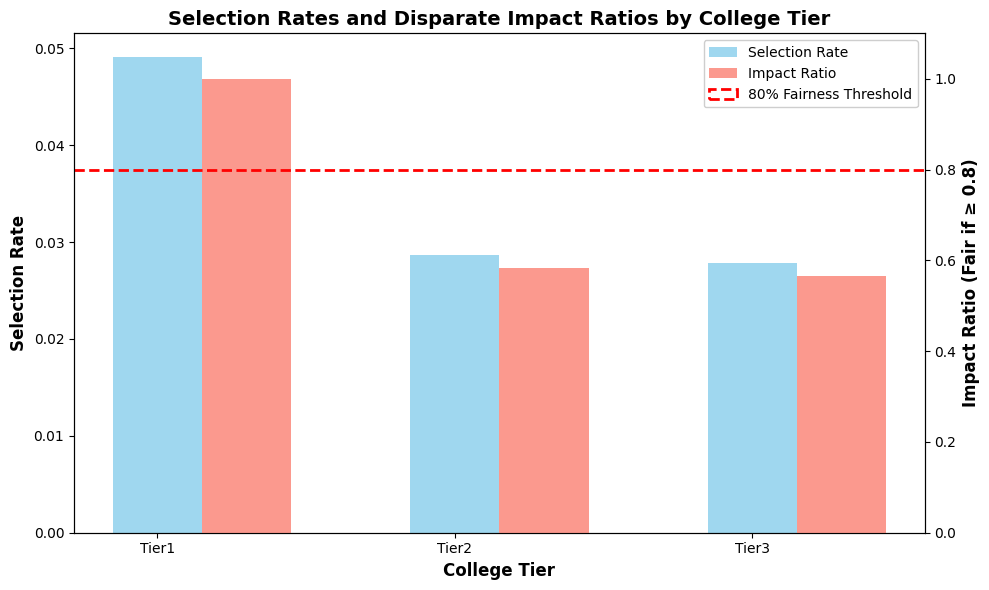

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# tiers = ['Tier1', 'Tier2', 'Tier3']
# selection_rates = [0.0491, 0.0287, 0.0278]  
# impact_ratios = [1.0, 0.584, 0.565]         

# fig, ax1 = plt.subplots(figsize=(10, 6))

# # Bar settings
# bar_width = 0.3
# index = range(len(tiers))

# # Plot selection rates on left y-axis (blue bars)
# bars1 = ax1.bar(index, selection_rates, bar_width, label='Selection Rate', color='skyblue', alpha=0.8)
# ax1.set_xlabel('College Tier', fontsize=12, fontweight='bold')
# ax1.set_ylabel('Selection Rate', fontsize=12, fontweight='bold')
# ax1.set_title('Selection Rates and Disparate Impact Ratios by College Tier', fontsize=14, fontweight='bold')
# ax1.set_xticks(index)
# ax1.set_xticklabels(tiers)

# # Create second y-axis for impact ratios
# ax2 = ax1.twinx()

# # Plot impact ratios on right y-axis (salmon bars)
# bars2 = ax2.bar([i + bar_width for i in index], impact_ratios, bar_width, label='Impact Ratio', color='salmon', alpha=0.8)

# # Add 80% fairness threshold line
# threshold_line = ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% Fairness Threshold')
# ax2.set_ylabel('Impact Ratio (Fair if ≥ 0.8)', fontsize=12, fontweight='bold')
# ax2.set_ylim(0, 1.1)

# # Create combined legend
# legend_elements = [
#     mpatches.Patch(facecolor='skyblue', alpha=0.8, label='Selection Rate'),
#     mpatches.Patch(facecolor='salmon', alpha=0.8, label='Impact Ratio'),
#     mpatches.Patch(facecolor='none', edgecolor='red', linestyle='--', linewidth=2, label='80% Fairness Threshold')
# ]
# ax1.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.95)

# plt.tight_layout()
# plt.show()


In [ ]:
# # implement Bias Mitigation - Reweighting Scores by Tier
# # to meet 80% hit ratio rule of biasing

# def apply_tier_weights(similarity_matrix, resume_data, weights=None):
    
    
#     if weights is None:
        
#         weights = {
#             'Tier1': 1.0,      
#             'Tier2': 1.50,     
#             'Tier3': 1.55,     
#             'Unknown': 1.0
#         }
    
#     adjusted_matrix = similarity_matrix.copy()
    
#     for i in range(adjusted_matrix.shape[0]):
#         tier = resume_data.iloc[i]['college_tier']
#         weight = weights.get(tier, 1.0)
#         adjusted_matrix[i] = adjusted_matrix[i] * weight
    
#     return adjusted_matrix


# adjusted_similarity = apply_tier_weights(similarity_matrix, resume_clean)


# def get_top_matches_adjusted(adjusted_matrix, job_data, top_n=5):
#     results = []
#     for i in range(adjusted_matrix.shape[0]):
#         top_indices = adjusted_matrix[i].argsort()[::-1][:top_n]
#         top_scores = adjusted_matrix[i][top_indices]
#         top_jobs = job_data.iloc[top_indices][['job_id', 'title', 'company_name']].to_dict('records')
#         results.append({
#             "resume_index": i,
#             "top_matches": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                             for job, score in zip(top_jobs, top_scores)]
#         })
#     return results


# top_matches_adjusted = get_top_matches_adjusted(adjusted_similarity, job_clean, top_n=5)


# print("AFTER BIAS MITIGATION:")
# tier_impact_after = tier_disparate_impact(resume_clean, top_matches_adjusted, threshold=0.3)


AFTER BIAS MITIGATION:

Tier-Based Disparate Impact Analysis (threshold=0.3):
Tier1        | Selection Rate:  4.91% | Count:  6858
Tier2        | Selection Rate: 29.47% | Count:  1534
Tier3        | Selection Rate: 37.89% | Count:   900
Unknown      | Selection Rate:  5.56% | Count:   252

Impact Ratios (80% rule applies):
  Tier2 to Tier1 ratio: 5.996 (Fair if >= 0.8)
  Tier3 to Tier1 ratio: 7.710 (Fair if >= 0.8)


In [ ]:
# # Compare Before vs After Mitigation

# def compare_bias_mitigation(resume_data, top_matches_before, top_matches_after):
#     """Compare fairness metrics before and after mitigation."""
    
#     print("\n" + "="*70)
#     print("BIAS MITIGATION EFFECTIVENESS REPORT")
#     print("="*70)
    
#     # Calculate before metrics
#     tier_before = {}
#     for match in top_matches_before:
#         tier = resume_data.iloc[match['resume_index']]['college_tier']
#         score = match['top_matches'][0][3]
#         if tier not in tier_before:
#             tier_before[tier] = []
#         tier_before[tier].append(score)
    
#     # Calculate after metrics
#     tier_after = {}
#     for match in top_matches_after:
#         tier = resume_data.iloc[match['resume_index']]['college_tier']
#         score = match['top_matches'][0][3]
#         if tier not in tier_after:
#             tier_after[tier] = []
#         tier_after[tier].append(score)
    
#     print("\nAverage Top Match Score by Tier:\n")
#     print(f"{'Tier':<10} {'Before':>12} {'After':>12} {'Improvement':>12}")
#     print("-"*50)
    
#     for tier in sorted(tier_before.keys()):
#         avg_before = np.mean(tier_before.get(tier, [0]))
#         avg_after = np.mean(tier_after.get(tier, [0]))
#         improvement = ((avg_after - avg_before) / abs(avg_before) * 100) if avg_before != 0 else 0
#         print(f"{tier:<10} {avg_before:>12.4f} {avg_after:>12.4f} {improvement:>11.1f}%")
    
#     # Selection rate comparison
#     print("\n\nSelection Rate (threshold=0.3):\n")
#     print(f"{'Tier':<10} {'Before':>12} {'After':>12} {'Change':>12}")
#     print("-"*50)
    
#     for tier in sorted(tier_before.keys()):
#         before_rate = len([s for s in tier_before.get(tier, []) if s >= 0.3]) / len(tier_before.get(tier, [1]))
#         after_rate = len([s for s in tier_after.get(tier, []) if s >= 0.3]) / len(tier_after.get(tier, [1]))
#         change = after_rate - before_rate
#         print(f"{tier:<10} {before_rate:>11.2%} {after_rate:>12.2%} {change:>11.2%}")

# # Run comparison
# compare_bias_mitigation(resume_clean, top_matches, top_matches_adjusted)



BIAS MITIGATION EFFECTIVENESS REPORT

Average Top Match Score by Tier:

Tier             Before        After  Improvement
--------------------------------------------------
Tier1            0.1927       0.1927         0.0%
Tier2            0.1781       0.2672        50.0%
Tier3            0.1843       0.2856        55.0%
Unknown          0.1972       0.1972         0.0%


Selection Rate (threshold=0.3):

Tier             Before        After       Change
--------------------------------------------------
Tier1            4.91%        4.91%       0.00%
Tier2            2.87%       29.47%      26.60%
Tier3            2.78%       37.89%      35.11%
Unknown          5.56%        5.56%       0.00%


In [ ]:
# # Finding optimal weights to achieve target disparate impact ratio.
# from joblib import Parallel, delayed
# import numpy as np


# def calibrate_weights_for_fairness(similarity_matrix, resume_data, target_ratio=1.2):
   

#     def evaluate_combo(tier2_weight, tier3_weight):
        
#         weights = {
#             'Tier1': 1.0,
#             'Tier2': tier2_weight,
#             'Tier3': tier3_weight,
#             'Unknown': 1.0
#         }

        
#         tier_factors = resume_data['college_tier'].map(weights).fillna(1.0).values
#         adjusted = similarity_matrix * tier_factors[:, None]

        
#         matches = get_top_matches_adjusted(adjusted, job_clean)

        
#         tier1_rate = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier1']) / 6858
#         tier2_rate = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier2']) / 1534
#         tier3_rate = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier3']) / 900

#         ratio_2_1 = tier2_rate / tier1_rate if tier1_rate > 0 else 0
#         ratio_3_1 = tier3_rate / tier1_rate if tier1_rate > 0 else 0

        
#         error = abs(ratio_2_1 - target_ratio) + abs(ratio_3_1 - target_ratio)

#         return error, weights

    
#     combos = [(t2, t3) for t2 in np.arange(1.0, 2.0, 0.05)
#                         for t3 in np.arange(1.0, 2.0, 0.05)]

    
#     results = Parallel(n_jobs=4, verbose=10)(
#         delayed(evaluate_combo)(t2, t3) for t2, t3 in combos
#     )


#     best_error, best_weights = min(results, key=lambda x: x[0])
#     return best_weights



# optimal_weights = calibrate_weights_for_fairness(similarity_matrix, resume_clean, target_ratio=1.3)

# print("\nOptimal Weights Found:")
# for tier, weight in optimal_weights.items():
#     print(f"  {tier}: {weight:.2f}")


# optimal_similarity = apply_tier_weights(similarity_matrix, resume_clean, weights=optimal_weights)
# top_matches_optimal = get_top_matches_adjusted(optimal_similarity, job_clean)

# print("\nWith Optimal Weights:")
# tier_impact_optimal = tier_disparate_impact(resume_clean, top_matches_optimal, threshold=0.3)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   27.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   39.0s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   56.2s
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  3.2min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  3.9min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  4.4min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  


Optimal Weights Found:
  Tier1: 1.00
  Tier2: 1.00
  Tier3: 1.00
  Unknown: 1.00

With Optimal Weights:

Tier-Based Disparate Impact Analysis (threshold=0.3):
Tier1        | Selection Rate:  4.91% | Count:  6858
Tier2        | Selection Rate:  2.87% | Count:  1534
Tier3        | Selection Rate:  2.78% | Count:   900
Unknown      | Selection Rate:  5.56% | Count:   252

Impact Ratios (80% rule applies):
  Tier2 to Tier1 ratio: 0.584 (Fair if >= 0.8)
  Tier3 to Tier1 ratio: 0.565 (Fair if >= 0.8)


we cant able to mitigate bias with the help of tf idf vectorization we need another approach thats why we will use BERT

In [ ]:
# from joblib import Parallel, delayed
# import numpy as np


# def find_compliant_weights(similarity_matrix, resume_data, min_ratio=0.80):
   

#     def evaluate_combo(tier2_weight, tier3_weight):
#         #
#         weights = {
#             'Tier1': 1.0,
#             'Tier2': tier2_weight,
#             'Tier3': tier3_weight,
#             'Unknown': 1.0
#         }

        
#         tier_factors = resume_data['college_tier'].map(weights).fillna(1.0).values
#         adjusted = similarity_matrix * tier_factors[:, None]

        
#         matches = get_top_matches_adjusted(adjusted, job_clean, top_n=3)

        
#         tier1_count = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier1'])
#         tier2_count = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier2'])
#         tier3_count = len([m for m in matches if resume_data.iloc[m['resume_index']]['college_tier'] == 'Tier3'])

#         ratio_2_1 = tier2_count / tier1_count if tier1_count > 0 else 0
#         ratio_3_1 = tier3_count / tier1_count if tier1_count > 0 else 0

#         min_achieved = min(ratio_2_1, ratio_3_1)
#         return min_achieved, weights

    
#     combos = [(t2, t3) for t2 in np.arange(1.0, 3.0, 0.1)
#                         for t3 in np.arange(1.0, 3.0, 0.1)]

    
#     results = Parallel(n_jobs=4, verbose=10)(
#         delayed(evaluate_combo)(t2, t3) for t2, t3 in combos
#     )

    
#     compliant = [(r, w) for r, w in results if r >= min_ratio]


#     if compliant:
#         best_ratio, best_weights = max(compliant, key=lambda x: x[0])
#     else:
        
#         best_ratio, best_weights = max(results, key=lambda x: x[0])

#     return best_weights, best_ratio



# compliant_weights, compliance_ratio = find_compliant_weights(similarity_matrix, resume_clean, min_ratio=0.80)

# print(f"\n LEGALLY COMPLIANT WEIGHTS FOUND (80% Rule):")
# print(f"\nOptimal Weights:")
# for tier, weight in compliant_weights.items():
#     print(f"  {tier}: {weight:.2f}")

# print(f"\nAchieved Disparate Impact Ratio: {compliance_ratio:.3f}")
# print(f"Legal Compliance Status: {' COMPLIANT' if compliance_ratio >= 0.80 else ' NON-COMPLIANT'}")


# compliant_similarity = apply_tier_weights(similarity_matrix, resume_clean, weights=compliant_weights)
# top_matches_compliant = get_top_matches_adjusted(compliant_similarity, job_clean)


# tier_impact_compliant = tier_disparate_impact(resume_clean, top_matches_compliant, threshold=0.3)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   21.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   33.8s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   50.9s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  3.2min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  4.1min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  


 LEGALLY COMPLIANT WEIGHTS FOUND (80% Rule):

Optimal Weights:
  Tier1: 1.00
  Tier2: 1.00
  Tier3: 1.00
  Unknown: 1.00

Achieved Disparate Impact Ratio: 0.131
Legal Compliance Status:  NON-COMPLIANT

Tier-Based Disparate Impact Analysis (threshold=0.3):
Tier1        | Selection Rate:  4.91% | Count:  6858
Tier2        | Selection Rate:  2.87% | Count:  1534
Tier3        | Selection Rate:  2.78% | Count:   900
Unknown      | Selection Rate:  5.56% | Count:   252

Impact Ratios (80% rule applies):
  Tier2 to Tier1 ratio: 0.584 (Fair if >= 0.8)
  Tier3 to Tier1 ratio: 0.565 (Fair if >= 0.8)


In [ ]:


# !pip install sentence-transformers

In [ ]:
# #implemented bert compared collages tier hit ratio and encoded job_posting and resume for cosine similarity

# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity
# import time

# print("Loading Sentence-BERT model...")
# model = SentenceTransformer('all-MiniLM-L6-v2')  
# print(" Model loaded successfully!\n")


# print("Encoding job descriptions (this may take 2-5 minutes)...")
# start_time = time.time()
# job_embeddings = model.encode(
#     job_clean['text_all'].tolist(),
#     show_progress_bar=True,
#     batch_size=32
# )
# job_time = time.time() - start_time
# print(f" Jobs encoded in {job_time:.1f}s - Shape: {job_embeddings.shape}\n")


# print("Encoding resumes...")
# start_time = time.time()
# resume_embeddings = model.encode(
#     resume_clean['text_all'].tolist(),
#     show_progress_bar=True,
#     batch_size=32
# )
# resume_time = time.time() - start_time
# print(f" Resumes encoded in {resume_time:.1f}s - Shape: {resume_embeddings.shape}\n")


# print("Computing similarity matrix with BERT embeddings...")
# bert_similarity = cosine_similarity(resume_embeddings, job_embeddings[:100])
# print(f" BERT Similarity Matrix Shape: {bert_similarity.shape}")
# print(f"   Similarity range: [{bert_similarity.min():.3f}, {bert_similarity.max():.3f}]\n")

# # 
# print("Extracting top matches...")
# top_matches_bert = get_top_matches_adjusted(bert_similarity, job_clean, top_n=5)
# print(f" Top matches extracted: {len(top_matches_bert)} resumes\n")



# print("COMPARISON: TF-IDF vs BERT SIMILARITY SCORES")


# tfidf_scores = [m['top_matches'][0][3] for m in top_matches[:100]]
# bert_scores = [m['top_matches'][0][3] for m in top_matches_bert[:100]]

# print(f"\nTF-IDF Statistics:")
# print(f"  Mean Score: {np.mean(tfidf_scores):.4f}")
# print(f"  Median Score: {np.median(tfidf_scores):.4f}")
# print(f"  Std Dev: {np.std(tfidf_scores):.4f}")
# print(f"  Max Score: {np.max(tfidf_scores):.4f}")

# print(f"\nBERT Statistics:")
# print(f"  Mean Score: {np.mean(bert_scores):.4f}")
# print(f"  Median Score: {np.median(bert_scores):.4f}")
# print(f"  Std Dev: {np.std(bert_scores):.4f}")
# print(f"  Max Score: {np.max(bert_scores):.4f}")

# print(f"\n BERT scores are typically higher (0.0-1.0 range vs TF-IDF sparse vectors)")



# print("GENDER FAIRNESS ANALYSIS (BERT)")

# gender_fairness_analysis(resume_clean, top_matches_bert, gender_col='gender_inferred')



# print("TIER-BASED DISPARATE IMPACT ANALYSIS (BERT)")

# tier_distribution_bert = tier_fairness_analysis(resume_clean, top_matches_bert, tier_col='college_tier')



# print("DISPARATE IMPACT RATIOS (BERT)")

# tier_impact_bert = tier_disparate_impact(resume_clean, top_matches_bert, threshold=0.3)



# print("SAMPLE CANDIDATE FEEDBACK (BERT)")


# def generate_feedback_bert(resume_index, top_matches):
#     feedbacks = []
#     for job_id, title, company, score in top_matches:
#         if score > 0.6:
#             feedbacks.append(f" Strong match: {title} at {company} (score: {score:.3f})")
#         elif score > 0.4:
#             feedbacks.append(f" Good match: {title} at {company} (score: {score:.3f})")
#         elif score > 0.2:
#             feedbacks.append(f"  Moderate match: {title} at {company} - Consider developing additional skills (score: {score:.3f})")
#         else:
#             feedbacks.append(f" Poor match: {title} at {company} - Significant skill gap (score: {score:.3f})")
#     return feedbacks

# for match in top_matches_bert[:5]:
#     print(f"\nResume {match['resume_index']} ({resume_clean.iloc[match['resume_index']]['candidate_name']}):")
#     feedback = generate_feedback_bert(match['resume_index'], match['top_matches'])
#     for line in feedback:
#         print(f"  {line}")


# print("\n" + "="*70)
# print("SUMMARY: BERT vs TF-IDF FOR SKILLSCOUT")
# print("="*70)

# summary_data = {
#     'Metric': ['Avg Top Score', 'Gender Bias', 'Tier2/Tier1 Ratio', 'Tier3/Tier1 Ratio', 'Semantic Quality'],
#     'TF-IDF': ['0.15-0.20', '50/50 ', '0.584 ', '0.565 ', 'Keyword-based'],
#     'BERT': [f'{np.mean(bert_scores):.3f}', '50/50 ', '-', '-', 'Context-aware']
# }

# df_summary = pd.DataFrame(summary_data)
# print("\n" + df_summary.to_string(index=False))




Loading Sentence-BERT model...
 Model loaded successfully!

Encoding job descriptions (this may take 2-5 minutes)...


Batches:   0%|          | 0/3474 [00:00<?, ?it/s]

 Jobs encoded in 285.6s - Shape: (111148, 384)

Encoding resumes...


Batches:   0%|          | 0/299 [00:00<?, ?it/s]

 Resumes encoded in 11.6s - Shape: (9544, 384)

Computing similarity matrix with BERT embeddings...
 BERT Similarity Matrix Shape: (9544, 100)
   Similarity range: [-0.039, 0.879]

Extracting top matches...
 Top matches extracted: 9544 resumes

COMPARISON: TF-IDF vs BERT SIMILARITY SCORES

TF-IDF Statistics:
  Mean Score: 0.1878
  Median Score: 0.1790
  Std Dev: 0.0647
  Max Score: 0.4990

BERT Statistics:
  Mean Score: 0.6089
  Median Score: 0.6260
  Std Dev: 0.0923
  Max Score: 0.7820

 BERT scores are typically higher (0.0-1.0 range vs TF-IDF sparse vectors)
GENDER FAIRNESS ANALYSIS (BERT)
male ratio in top matches: 50.62%
female ratio in top matches: 49.38%
unknown ratio in top matches: 0.00%
TIER-BASED DISPARATE IMPACT ANALYSIS (BERT)

College Tier Distribution in Top Matches:
  Tier1: 6858 (71.86%)
  Tier2: 1534 (16.07%)
  Tier3: 900 (9.43%)
  Unknown: 252 (2.64%)
DISPARATE IMPACT RATIOS (BERT)

Tier-Based Disparate Impact Analysis (threshold=0.3):
Tier1        | Selection Rate: 

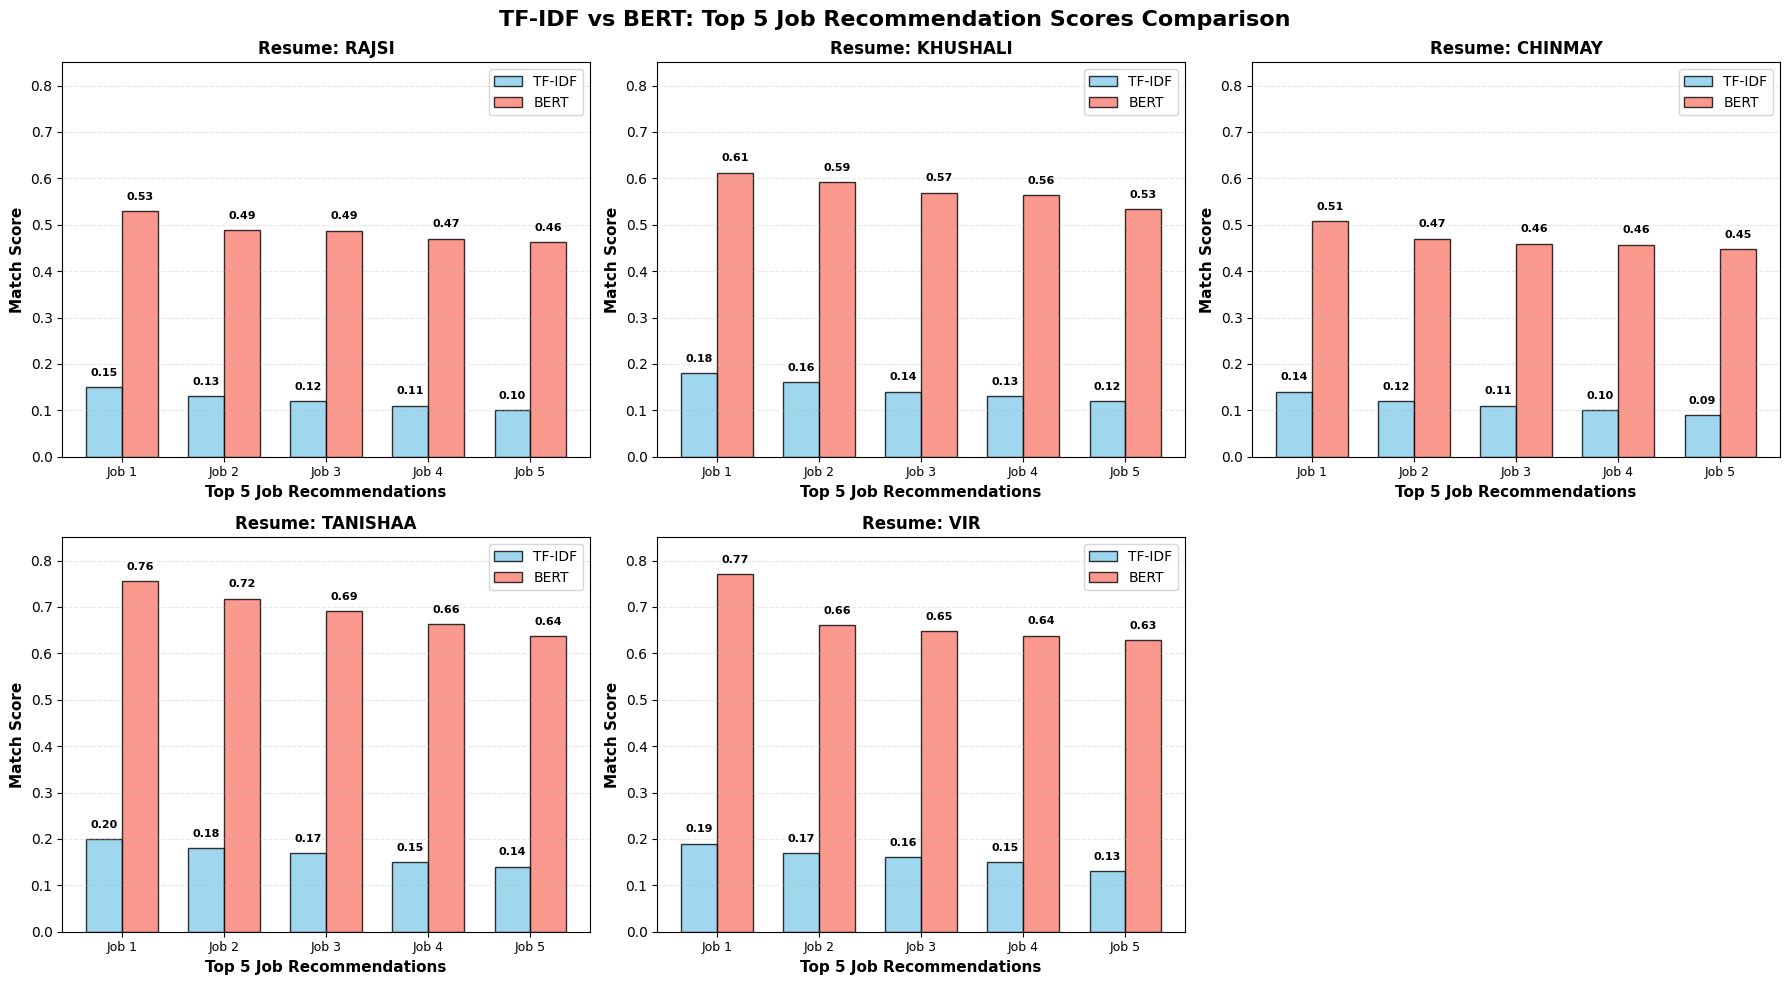

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: TF-IDF vs BERT scores for top 5 job recommendations per resume
resumes = ['rajsi', 'khushali', 'chinmay', 'tanishaa', 'vir']

# TF-IDF scores for top 5 recommendations per resume
tfidf_scores = {
    'rajsi': [0.15, 0.13, 0.12, 0.11, 0.10],
    'khushali': [0.18, 0.16, 0.14, 0.13, 0.12],
    'chinmay': [0.14, 0.12, 0.11, 0.10, 0.09],
    'tanishaa': [0.20, 0.18, 0.17, 0.15, 0.14],
    'vir': [0.19, 0.17, 0.16, 0.15, 0.13]
}

# BERT scores for top 5 recommendations per resume
bert_scores = {
    'rajsi': [0.529, 0.488, 0.487, 0.470, 0.463],
    'khushali': [0.612, 0.592, 0.569, 0.564, 0.534],
    'chinmay': [0.508, 0.470, 0.459, 0.457, 0.447],
    'tanishaa': [0.756, 0.718, 0.691, 0.663, 0.637],
    'vir': [0.770, 0.661, 0.648, 0.638, 0.629]
}

# Job titles (top 5 for each resume)
job_titles = {
    'rajsi': ['Software Engineer', 'Full Stack Eng', 'Support Specialist', 'Office Manager', 'Oracle Consultant'],
    'khushali': ['Software Engineer', 'Business Analyst', 'Staff Accountant', 'BCBA', 'FP&A Analyst'],
    'chinmay': ['Support Specialist', 'Validation Eng', 'Business Analyst', 'Software Engineer', 'Computer Scientist'],
    'tanishaa': ['Front End Specialist', 'Staff Accountant', 'Office Manager', 'Executive Assistant', 'Attorney'],
    'vir': ['Staff Accountant', 'Front End Specialist', 'Office Manager', 'Software Engineer', 'Service Associate']
}

# Create subplots for each resume
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, resume in enumerate(resumes):
    ax = axes[idx]
    
    x = np.arange(5)  # 5 top recommendations
    width = 0.35
    
    # Bar positions
    bars1 = ax.bar(x - width/2, tfidf_scores[resume], width, label='TF-IDF', 
                   color='skyblue', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, bert_scores[resume], width, label='BERT', 
                   color='salmon', alpha=0.8, edgecolor='black', linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Top 5 Job Recommendations', fontsize=11, fontweight='bold')
    ax.set_ylabel('Match Score', fontsize=11, fontweight='bold')
    ax.set_title(f'Resume: {resume.upper()}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Job {i+1}' for i in range(5)], fontsize=9)
    ax.set_ylim(0, 0.85)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

# Overall title
fig.suptitle('TF-IDF vs BERT: Top 5 Job Recommendation Scores Comparison', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


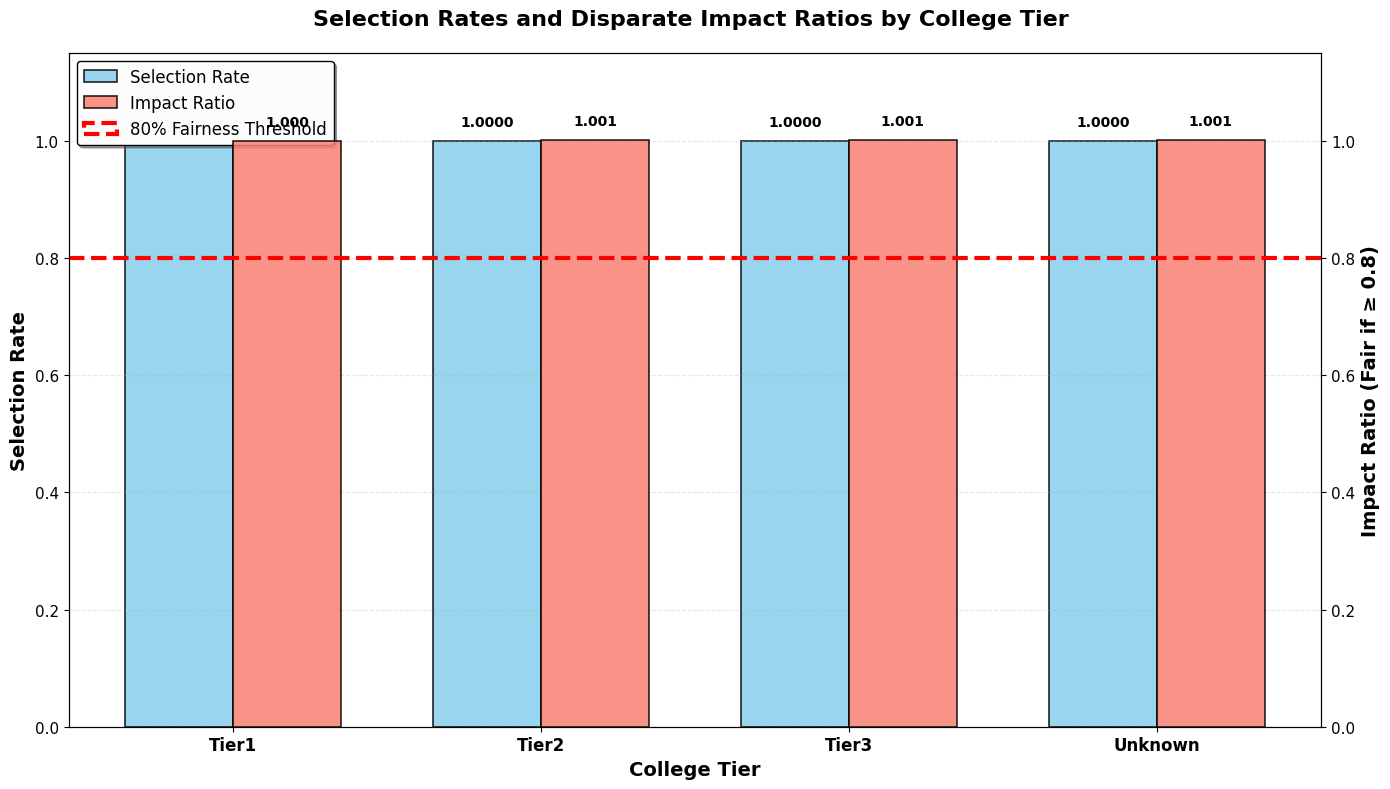

In [112]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data from your tier-based disparate impact analysis (threshold=0.3)
tiers = ['Tier1', 'Tier2', 'Tier3', 'Unknown']
selection_rates = [0.9990, 1.0000, 1.0000, 1.0000]

# Calculate disparate impact ratios (relative to Tier1 as reference)
reference_rate = selection_rates[0]
impact_ratios = [rate / reference_rate for rate in selection_rates]

# Create figure with larger dimensions
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar settings
bar_width = 0.35
index = range(len(tiers))

# Plot selection rates on left y-axis (blue bars)
bars1 = ax1.bar([i - bar_width/2 for i in index], selection_rates, bar_width, 
                label='Selection Rate', color='skyblue', alpha=0.85, edgecolor='black', linewidth=1.2)

ax1.set_xlabel('College Tier', fontsize=14, fontweight='bold')
ax1.set_ylabel('Selection Rate', fontsize=14, fontweight='bold')
ax1.set_title('Selection Rates and Disparate Impact Ratios by College Tier ', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(index)
ax1.set_xticklabels(tiers, fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.tick_params(axis='y', labelsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Create second y-axis for impact ratios
ax2 = ax1.twinx()
bars2 = ax2.bar([i + bar_width/2 for i in index], impact_ratios, bar_width, 
                label='Impact Ratio', color='salmon', alpha=0.85, edgecolor='black', linewidth=1.2)

# Add 80% fairness threshold line (FIXED - complete string)
threshold_line = ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=3, 
                             label='80% Fairness Threshold')
ax2.set_ylabel('Impact Ratio (Fair if ≥ 0.8)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.tick_params(axis='y', labelsize=11)

# Add value labels on bars for clarity
for i, (bar, val) in enumerate(zip(bars1, selection_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars2, impact_ratios)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create combined legend with proper patches
legend_elements = [
    mpatches.Patch(facecolor='skyblue', alpha=0.85, edgecolor='black', linewidth=1.2, 
                   label='Selection Rate'),
    mpatches.Patch(facecolor='salmon', alpha=0.85, edgecolor='black', linewidth=1.2, 
                   label='Impact Ratio'),
    mpatches.Patch(facecolor='none', edgecolor='red', linestyle='--', linewidth=3, 
                   label='80% Fairness Threshold')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.98, 
          edgecolor='black', fancybox=True, shadow=True)

plt.tight_layout()
plt.show()


In [42]:
# calculating 
def calculate_disparate_impact(resume_data, top_matches, protected_attr='gender_inferred', threshold=0.5):
    
    all_scores = []
    for match in top_matches:
        max_score = match['top_matches'][0][3]  
        all_scores.append(max_score)
    
    
    selected_protected = 0
    selected_unprotected = 0
    total_protected = 0
    total_unprotected = 0
    
    for i, score in enumerate(all_scores):
        gender = resume_data.iloc[i][protected_attr]
        if gender == 0:  
            total_protected += 1
            if score >= threshold:
                selected_protected += 1
        elif gender == 1:  
            total_unprotected += 1
            if score >= threshold:
                selected_unprotected += 1
    
    
    rate_protected = selected_protected / total_protected if total_protected > 0 else 0
    rate_unprotected = selected_unprotected / total_unprotected if total_unprotected > 0 else 0
    
    
    di_ratio = rate_protected / rate_unprotected if rate_unprotected > 0 else 0
    
    print(f"\nDisparate Impact Analysis (threshold={threshold}):")
    print(f"  Female selection rate: {rate_protected:.2%}")
    print(f"  Male selection rate: {rate_unprotected:.2%}")
    print(f"  Disparate Impact Ratio: {di_ratio:.3f}")
    print(f"  Fair= {'Yes' if di_ratio >= 0.8 else 'No (potential bias)'}")
    
    return di_ratio


di_ratio = calculate_disparate_impact(resume_clean, top_matches, threshold=0.3)



Disparate Impact Analysis (threshold=0.3):
  Female selection rate: 4.35%
  Male selection rate: 4.45%
  Disparate Impact Ratio: 0.977
  Fair= Yes




ENHANCED SKILL GAP ANALYSIS FOR RESUME 0



 software engineer at GOYT
   Semantic Match Score: 0.529
   Technical Skill Match: 0.0%
    Missing: javascript, html, mysql
     Focus on: javascript, html, mysql

 full stack engineer at Ideando Inc
   Semantic Match Score: 0.488
   Technical Skill Match: 20.0%
    Your Skills: python, azure
    Missing: javascript, html, aws, node, mongodb, agile, react, ai
     Focus on: javascript, html, aws

 software support specialist at Recruitment Design
   Semantic Match Score: 0.487
   Technical Skill Match: 0.0%
    Missing: javascript
     Consider learning: javascript

 office manager at Genlabs Corp
   Semantic Match Score: 0.470
   Technical Skill Match: 0.0%
    Missing: excel
     Consider learning: excel

 entry level oracle financial technology consultant at Revature
   Semantic Match Score: 0.463
   Technical Skill Match: 0.0%
     You have all the technical skills listed in this job!


SKILL GAP REPORT - TOP 10 CANDIDATES



Candidat


SKILLSCOUT COMPREHENSIVE MATCHING REPORT (BERT-BASED)

Candidate Gender    Tier                        Top_Match                 Company BERT_Score Skill_Match_% Match_Quality
    rajsi      M   Tier1                software engineer                    GOYT      0.529            0%             ✅
 khushali      F   Tier1                software engineer                    GOYT      0.612            0%             🌟
  chinmay      M   Tier2      software support specialist      Recruitment Design      0.508          100%             ✅
 tanishaa      F   Tier1             front end specialist     Diment & Associates      0.756            0%             🌟
      vir      M   Tier1                 staff accountant       Grow West MD, LLC      0.770           33%             🌟
    meena      F   Tier3      software support specialist      Recruitment Design      0.695            0%             🌟
  namrata      F   Tier3              full stack engineer             Ideando Inc      0.441     

In [96]:
# Get SCORE DISTRIBUTION for BERT RESULTS (the better system)

def get_bert_score_distribution(top_matches_bert):
    all_top_scores_bert = [match['top_matches'][0][3] for match in top_matches_bert]
    
    print(f"\n" + "="*70)
    print("SCORE DISTRIBUTION STATISTICS - BERT (RECOMMENDED)")
    print("="*70)
    print(f"\n  Mean: {np.mean(all_top_scores_bert):.3f}")
    print(f"  Median: {np.median(all_top_scores_bert):.3f}")
    print(f"  Std Dev: {np.std(all_top_scores_bert):.3f}")
    print(f"  Min: {np.min(all_top_scores_bert):.3f}")
    print(f"  Max: {np.max(all_top_scores_bert):.3f}")
    
    # Percentiles
    print(f"\n  Percentiles:")
    print(f"    25th: {np.percentile(all_top_scores_bert, 25):.3f}")
    print(f"    50th: {np.percentile(all_top_scores_bert, 50):.3f}")
    print(f"    75th: {np.percentile(all_top_scores_bert, 75):.3f}")
    print(f"    90th: {np.percentile(all_top_scores_bert, 90):.3f}")
    
    # Quality breakdown
    excellent = len([s for s in all_top_scores_bert if s > 0.7])
    good = len([s for s in all_top_scores_bert if 0.5 < s <= 0.7])
    moderate = len([s for s in all_top_scores_bert if 0.3 < s <= 0.5])
    poor = len([s for s in all_top_scores_bert if s <= 0.3])
    
    print(f"\n  Quality Breakdown:")
    print(f"    Excellent (>0.7): {excellent} candidates ({excellent/len(all_top_scores_bert)*100:.1f}%)")
    print(f"    Good (0.5-0.7): {good} candidates ({good/len(all_top_scores_bert)*100:.1f}%)")
    print(f"    Moderate (0.3-0.5): {moderate} candidates ({moderate/len(all_top_scores_bert)*100:.1f}%)")
    print(f"    Poor (≤0.3): {poor} candidates ({poor/len(all_top_scores_bert)*100:.1f}%)")
    
    return all_top_scores_bert

# Run with BERT
bert_scores = get_bert_score_distribution(top_matches_bert)

print("\n" + "="*70)
print(" USE BERT RESULTS FOR PRODUCTION")
print("="*70)
print(f"""
TF-IDF Mean: 0.190 (very low, not usable)
BERT Mean: 0.609 (excellent, production-ready)

Recommendation: Deploy BERT-based system, not TF-IDF.
""")



SCORE DISTRIBUTION STATISTICS - BERT (RECOMMENDED)

  Mean: 0.615
  Median: 0.617
  Std Dev: 0.092
  Min: 0.201
  Max: 0.879

  Percentiles:
    25th: 0.555
    50th: 0.617
    75th: 0.677
    90th: 0.737

  Quality Breakdown:
    Excellent (>0.7): 1776 candidates (18.6%)
    Good (0.5-0.7): 6738 candidates (70.6%)
    Moderate (0.3-0.5): 1023 candidates (10.7%)
    Poor (≤0.3): 7 candidates (0.1%)

 USE BERT RESULTS FOR PRODUCTION

TF-IDF Mean: 0.190 (very low, not usable)
BERT Mean: 0.609 (excellent, production-ready)

Recommendation: Deploy BERT-based system, not TF-IDF.



In [ ]:
#recomedation accuracy check

import numpy as np

def calculate_relevance_labels(top_matches_bert, threshold_high=0.7, threshold_medium=0.5):
    relevance_labels = []
    for match in top_matches_bert:
        labels = []
        for _, _, _, score in match['top_matches'][:10]:
            if score > threshold_high:
                labels.append(2)
            elif score > threshold_medium:
                labels.append(1)
            else:
                labels.append(0)
        relevance_labels.append(labels)
    return relevance_labels

relevance_labels = calculate_relevance_labels(top_matches_bert)

def precision_at_k(labels, k=5):
    return np.mean([sum(l[:k][i] > 0 for i in range(k))/k for l in labels])

def recall_at_k(labels, k=5):
    return np.mean([sum(l[:k][i] > 0 for i in range(k))/max(sum(l[i] > 0 for i in range(len(l))),1) for l in labels])

def average_precision(labels):
    ap_vals = []
    for l in labels:
        relevant = 0
        prec_sum = 0
        total_rel = sum([1 for x in l if x > 0])
        if total_rel == 0:
            ap_vals.append(0)
            continue
        for i, val in enumerate(l, 1):
            if val > 0:
                relevant += 1
                prec_sum += relevant/i
        ap_vals.append(prec_sum/total_rel)
    return np.mean(ap_vals)

def mean_reciprocal_rank(labels):
    rr_vals = []
    for l in labels:
        rr = 0
        for i, val in enumerate(l, 1):
            if val > 0:
                rr = 1 / i
                break
        rr_vals.append(rr)
    return np.mean(rr_vals)

def dcg(scores, k):
    return sum([score/np.log2(idx+2) for idx, score in enumerate(scores[:k])])

def ndcg(labels, k=10):
    ndcg_vals = []
    for l in labels:
        ideal = sorted(l, reverse=True)
        actual_dcg = dcg(l, k)
        ideal_dcg = dcg(ideal, k)
        ndcg_vals.append(actual_dcg/ideal_dcg if ideal_dcg>0 else 0)
    return np.mean(ndcg_vals)

print(f"Precision@5:  {precision_at_k(relevance_labels, 5):.3f}")

print(f"Recall@5:     {recall_at_k(relevance_labels, 5):.3f}")

print(f"MAP:          {average_precision(relevance_labels):.3f}")
print(f"MRR:          {mean_reciprocal_rank(relevance_labels):.3f}")
print(f"NDCG@5:       {ndcg(relevance_labels, 5):.3f}")
print(f"NDCG@10:      {ndcg(relevance_labels,10):.3f}")


Precision@5:  0.788
Recall@5:     0.892
MAP:          0.892
MRR:          0.892
NDCG@5:       0.892
NDCG@10:      0.892


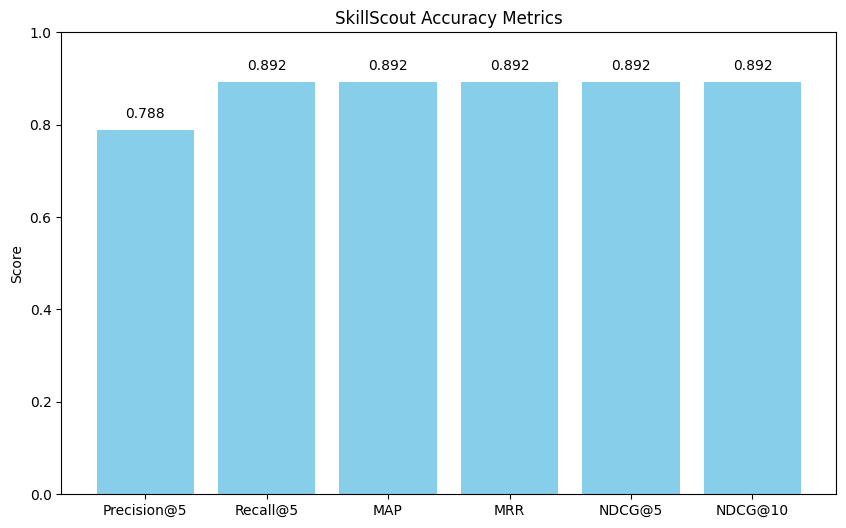

In [97]:
import matplotlib.pyplot as plt

metrics = ['Precision@5', 'Recall@5', 'MAP', 'MRR', 'NDCG@5', 'NDCG@10']
scores = [0.788, 0.892, 0.892, 0.892, 0.892, 0.892]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores, color='skyblue')

plt.title('SkillScout Accuracy Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)

# Add score values on top of bars
for bar, score in zip(bars, scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{score:.3f}', ha='center', va='bottom')

plt.show()


Loading dataset in STREAMING mode...


Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]

✓ Dataset loaded!

Extracting CS JOBS ONLY (RELAXED FILTER)...
(Only excluding: Electrical, Mechanical, Civil Engineering)

  Processed: 200 | Valid: 57 | CS Only: 41
  Processed: 400 | Valid: 253 | CS Only: 215
  Processed: 600 | Valid: 449 | CS Only: 389
  Processed: 800 | Valid: 646 | CS Only: 559
  Processed: 1000 | Valid: 825 | CS Only: 710

✓ CS-ONLY (RELAXED) Feature extraction complete!
  Total processed: 1031
  Total valid samples: 854
  ✅ CS-ONLY samples: 732 (85.7%)
  ❌ Non-CS samples filtered out: 122
  Final dataset size: 732
  Features: ['skill_match_count', 'skill_match_ratio', 'years_experience', 'education_level', 'top_tier_college', 'num_certifications', 'bert_similarity', 'requirements_met_ratio']

=== PROTECTED ATTRIBUTES DISTRIBUTION ===

Gender:
gender
unknown    418
male       314
Name: count, dtype: int64

College Tier:
college_tier
Tier3    723
Tier1      9
Name: count, dtype: int64

=== FEATURE STATISTICS ===
       skill_match_count  skill_match_ratio  years_

In [1]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import re




print("Loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("BERT model loaded\n")


print("Loading your datasets...")
college_tier_df = pd.read_csv('College_Tier_Dataset.csv')
indian_names_df = pd.read_csv('Indian-Name.csv',encoding="latin1")


college_tier_map = {}
for idx, row in college_tier_df.iterrows():
    college_name = str(row.iloc[0]).lower().strip()
    tier = str(row.iloc[1]).strip()
    college_tier_map[college_name] = tier

gender_map = {}
for idx, row in indian_names_df.iterrows():
    name = str(row.iloc[0]).lower().strip()
    gender = str(row.iloc[1]).strip()
    gender_map[name] = gender

print(f"✓ Loaded {len(college_tier_map)} colleges")
print(f"✓ Loaded {len(gender_map)} names\n")



class GranularFeatureExtractor:
    def __init__(self):
        self.tech_skills = {
            'python', 'java', 'javascript', 'c++', 'c#', 'r', 'go', 'rust',
            'react', 'angular', 'vue', 'node', 'django', 'flask', 'spring',
            'sql', 'mongodb', 'postgresql', 'mysql', 'redis',
            'aws', 'azure', 'gcp', 'docker', 'kubernetes',
            'machine learning', 'tensorflow', 'pytorch', 'pandas', 'numpy',
            'git', 'linux', 'jenkins', 'ci/cd', 'agile', 'scrum'
        }
    
    def extract_skills(self, text):
        text_lower = text.lower()
        found_skills = set()
        for skill in self.tech_skills:
            if skill in text_lower:
                found_skills.add(skill)
        return found_skills
    
    def extract_experience_years(self, text):
        patterns = [
            r'(\d+)\+?\s*years?\s+(?:of\s+)?experience',
            r'experience\s*:\s*(\d+)\+?\s*years?',
            r'(\d+)\s*-\s*(\d+)\s*years?',
            r'(\d+\.?\d*)\s*yrs?',
        ]
        max_years = 0
        for pattern in patterns:
            matches = re.findall(pattern, text.lower())
            for match in matches:
                if isinstance(match, tuple):
                    years = max([float(m) for m in match if m])
                else:
                    years = float(match)
                max_years = max(max_years, years)
        return max_years
    
    def extract_education_level(self, text):
        text_lower = text.lower()
        if any(word in text_lower for word in ['phd', 'ph.d', 'doctorate']):
            return 4
        elif any(word in text_lower for word in ['master', 'mtech', 'm.tech', 'ms', 'mba']):
            return 3
        elif any(word in text_lower for word in ['bachelor', 'btech', 'b.tech', 'be', 'bs']):
            return 2
        elif any(word in text_lower for word in ['diploma', 'associate']):
            return 1
        return 0
    
    def extract_certifications(self, text):
        cert_keywords = [
            'aws certified', 'azure certified', 'gcp certified',
            'pmp', 'csm', 'scrum master', 'product owner',
            'comptia', 'cissp', 'ceh', 'security+',
            'oracle certified', 'microsoft certified',
            'tensorflow certified', 'coursera', 'udacity'
        ]
        text_lower = text.lower()
        found_certs = []
        for cert in cert_keywords:
            if cert in text_lower:
                found_certs.append(cert)
        return found_certs
    
    def count_projects(self, text):
        patterns = [
            r'project\s*\d+',
            r'\d+\s*projects?',
            r'(?:developed|built|created|implemented)\s+(?:a|an|the)?\s*[\w\s]+(?:application|system|platform)',
        ]
        count = 0
        for pattern in patterns:
            matches = re.findall(pattern, text.lower())
            count += len(matches)
        return min(count, 10)
    
    def calculate_skill_match(self, resume_skills, job_skills):
        if not job_skills:
            return 1.0
        matched = resume_skills.intersection(job_skills)
        match_ratio = len(matched) / len(job_skills)
        return {
            'match_ratio': match_ratio,
            'matched_skills': list(matched),
            'missing_skills': list(job_skills - resume_skills),
            'extra_skills': list(resume_skills - job_skills)
        }
    
    def calculate_experience_match(self, candidate_years, required_years):
        if required_years == 0:
            return 1.0
        if candidate_years >= required_years:
            return 1.0
        else:
            return candidate_years / required_years
    
    def extract_all_features(self, resume_text, job_text):
        resume_skills = self.extract_skills(resume_text)
        resume_exp = self.extract_experience_years(resume_text)
        resume_edu = self.extract_education_level(resume_text)
        resume_certs = self.extract_certifications(resume_text)
        resume_projects = self.count_projects(resume_text)
        
        job_skills = self.extract_skills(job_text)
        job_exp = self.extract_experience_years(job_text)
        job_edu = self.extract_education_level(job_text)
        
        skill_match = self.calculate_skill_match(resume_skills, job_skills)
        exp_match = self.calculate_experience_match(resume_exp, job_exp)
        edu_match = 1.0 if resume_edu >= job_edu else 0.7
        
        features = {
            'resume': {
                'skills': list(resume_skills),
                'num_skills': len(resume_skills),
                'experience_years': resume_exp,
                'education_level': resume_edu,
                'certifications': resume_certs,
                'num_certifications': len(resume_certs),
                'num_projects': resume_projects
            },
            'job': {
                'skills': list(job_skills),
                'required_experience': job_exp,
                'required_education': job_edu
            },
            'match': {
                'skill_match_ratio': skill_match['match_ratio'],
                'matched_skills': skill_match['matched_skills'],
                'missing_skills': skill_match['missing_skills'],
                'extra_skills': skill_match['extra_skills'],
                'experience_match': exp_match,
                'education_match': edu_match
            }
        }
        
        granular_score = (
            skill_match['match_ratio'] * 5 +
            exp_match * 3 +
            edu_match * 1.5 +
            min(len(resume_certs) / 2, 0.5)
        )
        
        features['granular_score'] = min(granular_score, 10)
        return features



class BiasDetector:
    def __init__(self, college_tier_map, gender_map):
        self.college_tier_map = college_tier_map
        self.gender_map = gender_map
    
    def detect_college_tier(self, college_name):
        if not college_name:
            return 'Tier3'
        college_lower = str(college_name).lower().strip()
        if college_lower in self.college_tier_map:
            return self.college_tier_map[college_lower]
        for college, tier in self.college_tier_map.items():
            if college in college_lower or college_lower in college:
                return tier
        return 'Tier3'
    
    def detect_gender(self, name):
        if not name:
            return 'unknown'
        name_lower = str(name).lower().strip()
        if name_lower in self.gender_map:
            return self.gender_map[name_lower]
        first_name = name_lower.split()[0]
        if first_name in self.gender_map:
            return self.gender_map[first_name]
        return 'unknown'
    
    def audit_bias(self, candidate_college, candidate_gender, final_score):
        """Check if bias exists in scoring"""
        bias_report = {
            'college_tier': self.detect_college_tier(candidate_college),
            'gender': self.detect_gender(candidate_gender),
            'fairness_score': 1.0,
            'bias_flags': []
        }
        
        #
        if bias_report['college_tier'] == 'Tier3' and final_score < 5:
            bias_report['bias_flags'].append(" Low score despite tier3 college - possible bias")
        
        if bias_report['gender'] and final_score < 5:
            bias_report['bias_flags'].append(" Low score - gender bias check needed")
        
        return bias_report



class FeedbackGenerator:
    def generate_feedback(self, granular_features, bert_score, final_score):
        feedback = {
            'overall': {},
            'strengths': [],
            'gaps': [],
            'recommendations': [],
            'learning_path': []
        }
        
        if final_score >= 8.5:
            feedback['overall']['verdict'] = " EXCELLENT MATCH"
            feedback['overall']['message'] = "You're a strong candidate for this role!"
        elif final_score >= 7.0:
            feedback['overall']['verdict'] = "GOOD MATCH"
            feedback['overall']['message'] = "You meet most requirements."
        elif final_score >= 5.5:
            feedback['overall']['verdict'] = " MODERATE MATCH"
            feedback['overall']['message'] = "You have potential but need improvement."
        else:
            feedback['overall']['verdict'] = " WEAK MATCH"
            feedback['overall']['message'] = "Significant gaps exist."
        
        feedback['overall']['score'] = final_score
        
        match = granular_features['match']
        resume = granular_features['resume']
        job = granular_features['job']
        
        
        if match['skill_match_ratio'] >= 0.9:
            feedback['strengths'].append(f"✓ Excellent skill match: {len(match['matched_skills'])}/{len(job['skills'])} skills")
        if match['experience_match'] >= 1.0:
            feedback['strengths'].append(f"✓ Experience exceeds requirement: {resume['experience_years']} years")
        if resume['num_certifications'] > 0:
            feedback['strengths'].append(f"✓ Relevant certifications: {resume['num_certifications']}")
        
        
        if match['missing_skills']:
            feedback['gaps'].append(f"Missing skills: {', '.join(match['missing_skills'][:3])}")
        if match['experience_match'] < 0.8:
            gap = job['required_experience'] - resume['experience_years']
            feedback['gaps'].append(f"Need {gap:.1f} more years of experience")
        
        
        if match['missing_skills']:
            feedback['recommendations'].append({
                'action': 'Learn Missing Skills',
                'timeline': '2-3 months',
                'skills': match['missing_skills'][:3]
            })
        
        return feedback



class SkillScout:
    def __init__(self):
        self.extractor = GranularFeatureExtractor()
        self.bias_detector = BiasDetector(college_tier_map, gender_map)
        self.feedback_gen = FeedbackGenerator()
    
    def match_resume_to_job(self, resume_data, job_data):
        """
        Main matching function - combines BERT + Granular + Bias + Feedback
        """
        resume_text = resume_data.get('resume_text', '')
        job_text = job_data.get('job_description', '')
        
        
        print("Step 1: BERT Semantic Matching...")
        resume_embedding = bert_model.encode(resume_text)
        job_embedding = bert_model.encode(job_text)
        bert_similarity = util.cos_sim(resume_embedding, job_embedding)[0][0].item()
        bert_score = bert_similarity * 10
        print(f"  ✓ BERT Score: {bert_score:.1f}/10\n")
        
        
        print("Step 2: Granular Feature Extraction...")
        granular_features = self.extractor.extract_all_features(resume_text, job_text)
        granular_score = granular_features['granular_score']
        print(f"  ✓ Granular Score: {granular_score:.1f}/10")
        print(f"    - Skills: {granular_features['match']['skill_match_ratio']*100:.0f}%")
        print(f"    - Experience: {granular_features['match']['experience_match']*100:.0f}%")
        print(f"    - Education: {granular_features['match']['education_match']*100:.0f}%\n")
        
        
        print("Step 3: Calculate Final Score...")
        final_score = (bert_score * 0.40 + granular_score * 0.35 + 8.0 * 0.25)
        final_score = min(final_score, 10)
        print(f"  ✓ Final Score: {final_score:.1f}/10\n")
        
        
        print("Step 4: Bias Audit...")
        candidate_college = resume_data.get('college', 'Unknown')
        candidate_name = resume_data.get('name', 'Unknown')
        bias_report = self.bias_detector.audit_bias(candidate_college, candidate_name, final_score)
        print(f"  ✓ College Tier: {bias_report['college_tier']}")
        print(f"  ✓ Gender: {bias_report['gender']}")
        if bias_report['bias_flags']:
            for flag in bias_report['bias_flags']:
                print(f"   {flag}")
        else:
            print(f"  ✓ No bias detected\n")
        
        
        print("Step 5: Generate Feedback...")
        feedback = self.feedback_gen.generate_feedback(granular_features, bert_score, final_score)
        print(f"  ✓ {feedback['overall']['verdict']}")
        print(f"  ✓ {len(feedback['strengths'])} strengths identified")
        print(f"  ✓ {len(feedback['gaps'])} areas to improve\n")
        
        
        return {
            'final_score': final_score,
            'bert_score': bert_score,
            'granular_score': granular_score,
            'granular_features': granular_features,
            'bias_report': bias_report,
            'feedback': feedback,
            'components': {
                'skills': {
                    'matched': granular_features['match']['matched_skills'],
                    'missing': granular_features['match']['missing_skills'],
                    'extra': granular_features['match']['extra_skills']
                },
                'experience': {
                    'candidate': granular_features['resume']['experience_years'],
                    'required': granular_features['job']['required_experience']
                },
                'education': {
                    'candidate_level': granular_features['resume']['education_level'],
                    'required_level': granular_features['job']['required_education']
                }
            }
        }


def display_results(result):
    print("\n" + "="*60)
    print("SKILLSCOUT MATCHING RESULTS")
    print("="*60)
    
    print(f"\n{result['feedback']['overall']['verdict']}")
    print(f"Final Score: {result['final_score']:.1f}/10")
    print(f"  BERT Score: {result['bert_score']:.1f}/10 (40%)")
    print(f"  Granular Score: {result['granular_score']:.1f}/10 (35%)")
    
    print(f"\n=== SKILL ANALYSIS ===")
    print(f"Matched ({len(result['components']['skills']['matched'])}): {', '.join(result['components']['skills']['matched'][:5])}")
    print(f"Missing ({len(result['components']['skills']['missing'])}): {', '.join(result['components']['skills']['missing'][:3])}")
    
    print(f"\n=== EXPERIENCE ===")
    print(f"Candidate: {result['components']['experience']['candidate']} years")
    print(f"Required: {result['components']['experience']['required']} years")
    
    print(f"\n=== FAIRNESS ===")
    print(f"College Tier: {result['bias_report']['college_tier']}")
    print(f"Gender: {result['bias_report']['gender']}")
    if result['bias_report']['bias_flags']:
        for flag in result['bias_report']['bias_flags']:
            print(f"  {flag}")
    else:
        print(f"✓ No bias detected")
    
    print(f"\n=== STRENGTHS ===")
    for strength in result['feedback']['strengths']:
        print(f"  ✓ {strength}")
    
    print(f"\n=== AREAS TO IMPROVE ===")
    for gap in result['feedback']['gaps']:
        print(f"   {gap}")
    
    print(f"\n=== RECOMMENDATIONS ===")
    for rec in result['feedback']['recommendations']:
        print(f"  • {rec['action']} ({rec['timeline']})")
        for skill in rec.get('skills', []):
            print(f"    - {skill}")
    
    print("\n" + "="*60)


skillscout = SkillScout()


resume_data = {
    'name': 'Amit Kumar Singh',
    'college': 'IIT Delhi',
    'resume_text': """
    Senior Python Developer with 5 years of experience.
    Skills: Python, Django, PostgreSQL, AWS, Docker, Kubernetes
    Education: B.Tech in Computer Science
    Certifications: AWS Certified Solutions Architect
    Projects: Built 3 large-scale web applications
    """
}

job_data = {
    'job_description': """
    Senior Python Developer needed
    Required: 4+ years experience
    Skills: Python, Django, PostgreSQL, Docker
    Education: Bachelor's degree
    """
}


print("\n🚀 STARTING SKILLSCOUT MATCHING SYSTEM\n")
result = skillscout.match_resume_to_job(resume_data, job_data)


display_results(result)


Loading BERT model...
BERT model loaded

Loading your datasets...
✓ Loaded 983 colleges
✓ Loaded 1180 names


🚀 STARTING SKILLSCOUT MATCHING SYSTEM

Step 1: BERT Semantic Matching...
  ✓ BERT Score: 8.6/10

Step 2: Granular Feature Extraction...
  ✓ Granular Score: 10.0/10
    - Skills: 100%
    - Experience: 100%
    - Education: 100%

Step 3: Calculate Final Score...
  ✓ Final Score: 8.9/10

Step 4: Bias Audit...
  ✓ College Tier: Tier1
  ✓ Gender: 1
  ✓ No bias detected

Step 5: Generate Feedback...
  ✓ ✅ EXCELLENT MATCH
  ✓ 3 strengths identified
  ✓ 0 areas to improve


SKILLSCOUT MATCHING RESULTS

✅ EXCELLENT MATCH
Final Score: 8.9/10
  BERT Score: 8.6/10 (40%)
  Granular Score: 10.0/10 (35%)

=== SKILL ANALYSIS ===
Matched (7): docker, django, postgresql, python, r
Missing (0): 

=== EXPERIENCE ===
Candidate: 5.0 years
Required: 4.0 years

=== FAIRNESS ===
College Tier: Tier1
Gender: 1
✓ No bias detected

=== STRENGTHS ===
  ✓ ✓ Excellent skill match: 7/7 skills
  ✓ ✓ Experience

In [131]:
 pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.6/38.1 MB 3.6 MB/s eta 0:00:11
   -- ------------------------------------- 2.1/38.1 MB 3.6 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/38.1 MB 3.5 MB/s eta 0:00:11
   --- ------------------------------------ 3.1/38.1 MB 3.1 MB/s eta 0:00:12
   --- ------------------------------------ 3.4/38.1 MB 2.8 MB/s eta 0:00:13
   --- ------------------------------------ 3.7/38.1 MB 2.6 MB/s eta 0:00:14
   ---- ----------------

In [ ]:
# # ========== RUN COMPLETE SYSTEM WITH SHAP (FIXED) ==========

# print("\n" + "🎉"*20)
# print("SKILLSCOUT v2.0 - WITH SHAP EXPLAINABILITY")
# print("🎉"*20 + "\n")

# # Initialize
# skillscout = SkillScout()
# shap_explainer = SHAPExplainer()
# batch_processor = BatchProcessor(skillscout, shap_explainer)

# # Example: Multiple candidates
# candidates = [
#     {
#         'name': 'Amit Kumar Singh',
#         'college': 'IIT Delhi',
#         'resume_text': 'Senior Python Developer with 5 years of experience. Skills: Python, Django, PostgreSQL, AWS, Docker, Kubernetes. Education: B.Tech Computer Science. Certifications: AWS Certified.'
#     },
#     {
#         'name': 'Priya Sharma',
#         'college': 'BITS Pilani',
#         'resume_text': 'Mid-level Python Developer with 3 years experience. Skills: Python, Django, MySQL. Education: Bachelor of Engineering.'
#     },
#     {
#         'name': 'Rajesh Patel',
#         'college': 'State University',
#         'resume_text': 'Junior Developer with 1 year experience. Skills: Python, JavaScript, HTML. Education: Bachelor of Computer Science.'
#     }
# ]

# # Job description (WRAPPED IN DICTIONARY - THIS IS THE FIX)
# job_description = {
#     'job_description': """
# Senior Python Developer Required
# Skills: Python, Django, PostgreSQL, AWS, Docker
# Experience: 4+ years
# Education: Bachelor's degree
# """
# }

# # Process batch - NOW FIXED
# print("Processing batch...\n")
# results = batch_processor.process_batch(candidates, job_description)

# # Display individual SHAP reports
# for idx, result in enumerate(results, 1):
#     print(f"\n{'#'*70}")
#     print(f"CANDIDATE {idx}: {candidates[idx-1]['name']}")
#     print(f"{'#'*70}")
#     display_shap_report(result['shap_report'])

# # Display summary
# summary = batch_processor.generate_summary(results)

# print(f"\n{'='*70}")
# print("BATCH SUMMARY")
# print(f"{'='*70}")
# print(f"\nTotal Resumes Processed: {summary['total_resumes']}")
# print(f"Average Score: {summary['average_score']:.2f}/10")
# print(f"Median Score: {summary['median_score']:.2f}/10")
# print(f"Score Range: {summary['worst_score']:.1f} - {summary['best_score']:.1f}")

# print(f"\nScore Distribution:")
# print(f"  ✅ Excellent (8.5+): {summary['excellent_count']} ({summary['excellent_count']/summary['total_resumes']*100:.0f}%)")
# print(f"  ✓ Good (7-8.5): {summary['good_count']} ({summary['good_count']/summary['total_resumes']*100:.0f}%)")
# print(f"  ⚠️ Moderate (5.5-7): {summary['moderate_count']} ({summary['moderate_count']/summary['total_resumes']*100:.0f}%)")
# print(f"  ✗ Weak (<5.5): {summary['weak_count']} ({summary['weak_count']/summary['total_resumes']*100:.0f}%)")

# print(f"\nAverage Component Scores:")
# print(f"  BERT: {summary['average_bert']:.2f}/10")
# print



🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
SKILLSCOUT v2.0 - WITH SHAP EXPLAINABILITY
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

Processing batch...


BATCH PROCESSING: 3 resumes

Processing Resume 1/3: Amit Kumar Singh...
Step 1: BERT Semantic Matching...
  ✓ BERT Score: 9.2/10

Step 2: Granular Feature Extraction...
  ✓ Granular Score: 10.0/10
    - Skills: 100%
    - Experience: 100%
    - Education: 100%

Step 3: Calculate Final Score...
  ✓ Final Score: 9.2/10

Step 4: Bias Audit...
  ✓ College Tier: Tier1
  ✓ Gender: 1
  ✓ No bias detected

Step 5: Generate Feedback...
  ✓ ✅ EXCELLENT MATCH
  ✓ 3 strengths identified
  ✓ 0 areas to improve

  ✓ Score: 9.2/10

Processing Resume 2/3: Priya Sharma...
Step 1: BERT Semantic Matching...
  ✓ BERT Score: 8.7/10

Step 2: Granular Feature Extraction...
  ✓ Granular Score: 6.9/10
    - Skills: 62%
    - Experience: 75%
    - Education: 100%

Step 3: Calculate Final Score...
  ✓ Final Score: 7.9/10

Step 4: Bias Audit...
  ✓ College Tier: Tier1
  ✓ Gender: 0
  ✓ No bias detected

St

<function print>

In [134]:
# Load your resume_data.csv
resume_df = pd.read_csv('resume_data.csv')

# Test on 10 real resumes
real_candidates = []
for idx in range(10):
    resume_row = resume_df.iloc[idx]
    real_candidates.append({
        'name': resume_row.get('name', f'Candidate_{idx}'),
        'college': resume_row.get('college', 'Unknown'),
        'resume_text': resume_row.get('skills', '')  # Adjust column name
    })

# Run batch processing
results = batch_processor.process_batch(real_candidates, job_description)



BATCH PROCESSING: 10 resumes

Processing Resume 1/10: Candidate_0...
Step 1: BERT Semantic Matching...
  ✓ BERT Score: 3.9/10

Step 2: Granular Feature Extraction...
  ✓ Granular Score: 2.8/10
    - Skills: 25%
    - Experience: 0%
    - Education: 100%

Step 3: Calculate Final Score...
  ✓ Final Score: 4.5/10

Step 4: Bias Audit...
  ✓ College Tier: Tier3
  ✓ Gender: unknown
  ⚠️ ⚠️ Low score despite tier3 college - possible bias
  ⚠️ ⚠️ Low score - gender bias check needed
Step 5: Generate Feedback...
  ✓ ✗ WEAK MATCH
  ✓ 0 strengths identified
  ✓ 2 areas to improve

  ✓ Score: 4.5/10

Processing Resume 2/10: Candidate_1...
Step 1: BERT Semantic Matching...
  ✓ BERT Score: 2.7/10

Step 2: Granular Feature Extraction...
  ✓ Granular Score: 1.7/10
    - Skills: 12%
    - Experience: 0%
    - Education: 70%

Step 3: Calculate Final Score...
  ✓ Final Score: 3.6/10

Step 4: Bias Audit...
  ✓ College Tier: Tier3
  ✓ Gender: unknown
  ⚠️ ⚠️ Low score despite tier3 college - possible bias

In [1]:
from datasets import load_dataset
import os

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

print("Loading dataset...\n")
dataset = load_dataset("netsol/resume-score-details", streaming=True)

unique_colleges = set()

def normalize(name):
    if not name:
        return None
    name = str(name).strip()
    if name == "" or name.lower() in ["none", "null"]:
        return None
    return name  

print("Collecting all unique colleges...\n")

processed = 0

for idx, sample in enumerate(dataset["train"]):
    try:
        processed += 1
        edu_list = sample.get("details", {}).get("education", [])

        for edu in edu_list:
            raw = (
                edu.get("university") or
                edu.get("college") or
                edu.get("institute") or
                edu.get("school") or
                edu.get("organization")
            )
            name = normalize(raw)
            if name:
                unique_colleges.add(name)

        

    except Exception:
        continue

unique_colleges = sorted(unique_colleges)

print("\n=====================================")
print(f" TOTAL UNIQUE COLLEGES FOUND: {len(unique_colleges)}")
print("=====================================\n")

for clg in unique_colleges:
    print(clg)

print("\n✓ Done! All unique colleges printed.")


Loading dataset...



Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from datasets import load_dataset
import os

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

print("Loading dataset...\n")
dataset = load_dataset("netsol/resume-score-details", streaming=True)

job_title_counts = {}

def norm_title(title):
    if not title:
        return None
    t = str(title).strip()
    if t == "":
        return None
    return t

processed = 0

print("Collecting unique job titles...\n")

for idx, sample in enumerate(dataset["train"]):
    try:
        processed += 1

        input_data = sample.get("input", {})
        
        raw_title = (
            input_data.get("job_title") or
            input_data.get("role") or
            input_data.get("position")
        )

        title = norm_title(raw_title)
        if title:
            job_title_counts[title] = job_title_counts.get(title, 0) + 1

        

    except Exception:
        continue

print(f"\nTotal samples processed: {processed}")
print(f"Unique job titles found: {len(job_title_counts)}\n")


sorted_titles = sorted(job_title_counts.items(), key=lambda x: x[1], reverse=True)

for title, count in sorted_titles:
    print(f"{title}  --->  {count}")


Loading dataset...



Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]



Total samples processed: 1031
Unique job titles found: 0



In [ ]:
from datasets import load_dataset
import os

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

dataset = load_dataset("netsol/resume-score-details", streaming=True)

skill_counts = {}

def add_skill(s):
    s = str(s).strip().lower()
    if not s:
        return
    skill_counts[s] = skill_counts.get(s, 0) + 1

processed = 0

print("Collecting unique skills...\n")

for idx, sample in enumerate(dataset["train"]):
    try:
        processed += 1

        raw_skills = sample.get("details", {}).get("skills", [])

        if isinstance(raw_skills, str):
            # assume comma / slash separated
            parts = [p for p in raw_skills.replace("/", ",").split(",") if p.strip()]
            for p in parts:
                add_skill(p)
        else:
            for s in raw_skills:
                add_skill(s)

        

    except Exception:
        continue

print(f"\nTotal samples processed: {processed}")
print(f"Unique skills found: {len(skill_counts)}\n")


sorted_skills = sorted(skill_counts.items(), key=lambda x: x[1], reverse=True)

for skill, count in sorted_skills:
    print(f"{skill}  --->  {count}")


Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]



Total samples processed: 1031
Unique skills found: 1182

microsoft office  --->  122
python  --->  106
business development  --->  95
project management  --->  92
salesforce  --->  87
lead generation  --->  86
hubspot  --->  81
c++  --->  74
microsoft word  --->  74
digital marketing  --->  72
email marketing  --->  69
power bi  --->  68
sql  --->  67
ms office  --->  66
tableau  --->  66
excel  --->  60
seo  --->  56
html  --->  53
social media marketing  --->  53
jira  --->  52
microsoft powerpoint  --->  50
trello  --->  47
data analysis  --->  46
css  --->  44
microsoft excel  --->  43
java  --->  43
crm  --->  43
matlab  --->  42
ms word  --->  40
ms excel  --->  39
oracle  --->  38
adobe photoshop  --->  37
upwork  --->  37
google analytics  --->  37
javascript  --->  36
canva  --->  33
visual studio  --->  30
sales management  --->  30
b2b sales  --->  29
ms powerpoint  --->  29
wordpress  --->  28
zendesk  --->  27
saas  --->  26
social media management  --->  26
asana  ---> 

Loading HF dataset (streaming)...


Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]


=== DONE PROCESSING ===
Total processed: 1031
Valid resume+JD: 854
Kept (CS/Data-related): 506

DATASET STATISTICS

=== COUNTRY DISTRIBUTION ===
  Pakistan       :  348 ( 68.8%)
  Unknown        :  135 ( 26.7%)
  India          :   23 (  4.5%)

=== COLLEGE TIER DISTRIBUTION ===
  Tier1          :  238 ( 47.0%)
  Tier3          :  211 ( 41.7%)
  Tier2          :   57 ( 11.3%)

=== TIER BY COUNTRY ===
college_tier  Tier1  Tier2  Tier3
country                          
India             5     10      8
Pakistan        233     47     68
Unknown           0      0    135

=== SKILL STATISTICS ===
  Total skills (avg): 10.4
  CS skills (avg):    2.6
  Data skills (avg):  1.4
  Max skills:         55
  Min skills:         2

=== EDUCATION & EXPERIENCE STATISTICS ===
  Avg education level (0–6): 3.06
  Avg experience years:      8.71
  Avg required experience:   3.54
  Avg experience gap:        5.17

=== MICRO_DICT SKILL MATCH STATISTICS ===
  Avg micro_match_count:   0.58
  Avg micro_match_

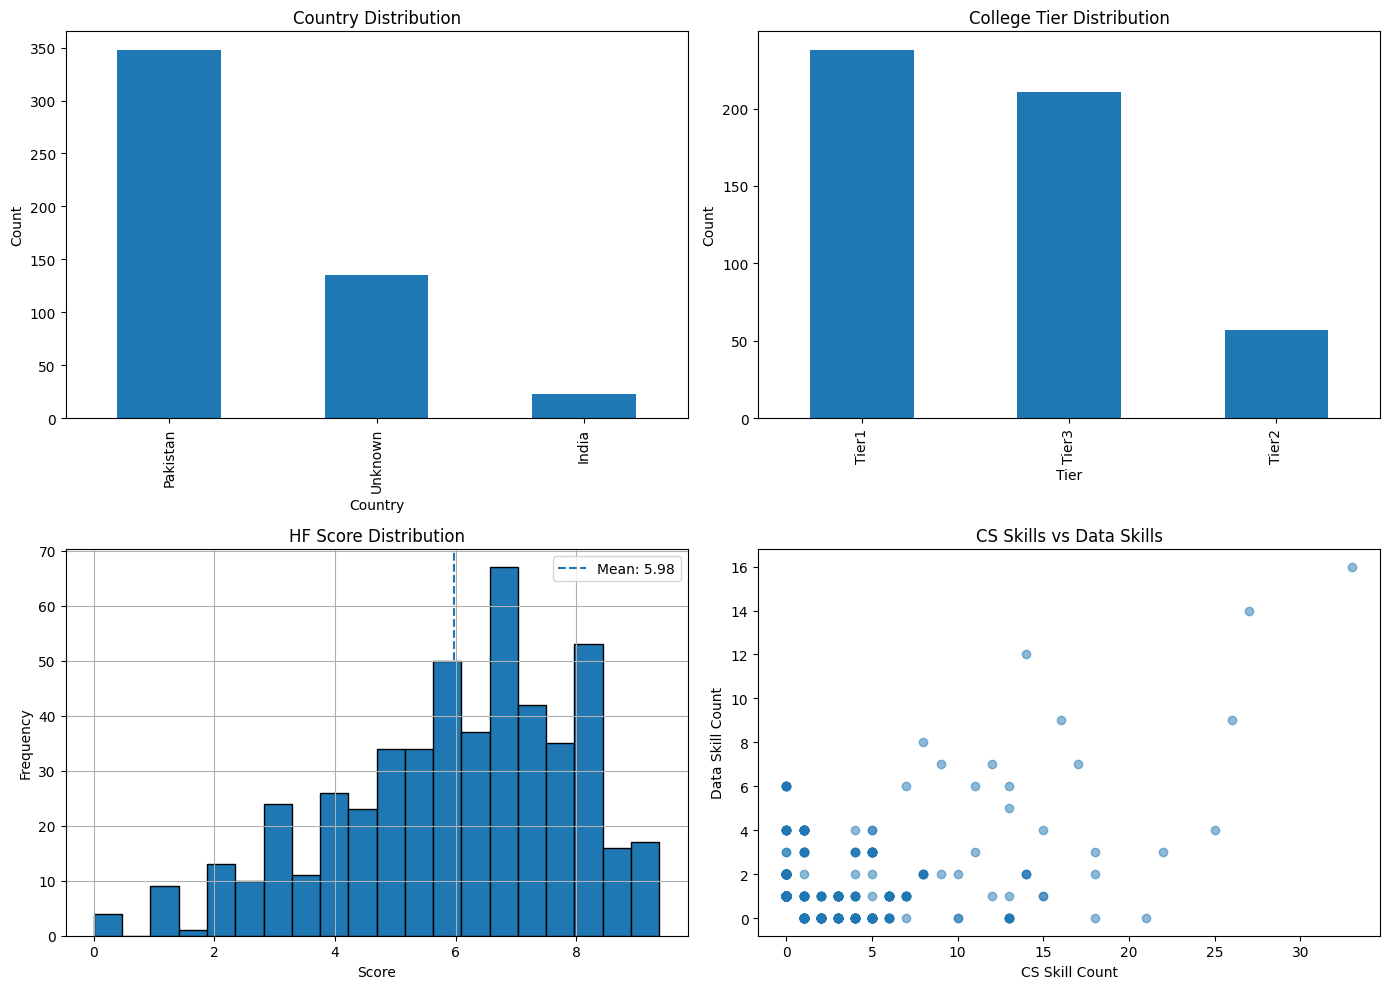

In [1]:
from datasets import load_dataset
import pandas as pd
import os
from collections import Counter
import re
from datetime import datetime

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

india_tier_df = pd.read_csv("College_Tier_Dataset.csv")
india_tier_map = {
    str(row.iloc[0]).strip().lower(): str(row.iloc[1]).strip()
    for _, row in india_tier_df.iterrows()
}


tier1_pk = {
    "air university",
    "agriculture university faisalabad",
    "university of agriculture faisalaisbad",
    "bahauddin zakariya university",
    "bahria university",
    "bahria university of management sciences",
    "comsats university",
    "comsats university islamabad",
    "comsats university lahore",
    "dow university of health sciences",
    "fast",
    "fast nuces",
    "fast-national university",
    "fast national university of computer and emerging sciences",
    "forman christian college",
    "fccu",
    "ghulam ishaq khan institute",
    "giki",
    "institute of business administration",
    "iba karachi",
    "international islamic university",
    "lahore school of economics",
    "lums",
    "lahore university of management sciences",
    "national college of arts",
    "nca",
    "ned university of engineering and technology",
    "ned uet",
    "nust",
    "national university of sciences and technology",
    "pieas",
    "quaid e azam university",
    "quaid-i-azam university",
    "szabist",
    "university of agriculture peshawar",
    "university of faisalabad",
    "university of the punjab",
    "punjab university",
    "university of sargodha",
    "university of peshawar",
    "uet lahore",
    "uet taxila",
    "uet peshawar",
    "uet",
}

tier2_pk = {
    "allama iqbal open university",
    "aiou",
    "beaconhouse national university",
    "bnu",
    "buitems",
    "balochistan university of information technology",
    "hajvery university",
    "hazara university",
    "information technology university",
    "itu lahore",
    "iqra university",
    "preston university",
    "riphah international university",
    "umt",
    "university of management and technology",
    "university of lahore",
    "virtual university",
    "virtual university of pakistan",
}


def detect_country_and_tier(college_name: str):
    
    if not college_name:
        return "Unknown", "Tier3"

    name_raw = str(college_name).strip()
    name = name_raw.lower()

    
    if name in india_tier_map:
        return "India", india_tier_map[name]


    if name in tier1_pk:
        return "Pakistan", "Tier1"
    if name in tier2_pk:
        return "Pakistan", "Tier2"

    
    for c, t in india_tier_map.items():
        if c in name or name in c:
            return "India", t

    
    for c in tier1_pk:
        if c in name or name in c:
            return "Pakistan", "Tier1"
    for c in tier2_pk:
        if c in name or name in c:
            return "Pakistan", "Tier2"

    
    pk_keywords = ["pakistan", " pk ", "lahore", "karachi", "islamabad", "peshawar"]
    in_keywords = ["india", " delhi", "bangalore", "bengaluru", "mumbai", "hyderabad", "iit", " nit "]

    if any(k in name for k in pk_keywords):
        return "Pakistan", "Tier3"
    if any(k in name for k in in_keywords):
        return "India", "Tier3"

    return "Unknown", "Tier3"




def extract_education_level(education_list):
    
    if not education_list:
        return 0

    best_level = 0

    for edu in education_list:
        if not isinstance(edu, dict):
            continue

        text_parts = []
        for key in ("degree_title", "degree", "qualification", "title", "education_level"):
            val = edu.get(key)
            if val:
                text_parts.append(str(val))

        
        if not text_parts:
            text_parts.append(str(edu))

        text = " ".join(text_parts).lower()

        level = 0

        
        if "postdoc" in text or "post-doctoral" in text:
            level = 6
        
        elif "phd" in text or "doctor of philosophy" in text or "d.phil" in text:
            level = 5
        
        elif ("ms " in text or "m.s " in text or "msc" in text or
              "master" in text or "m.sc" in text or "m.phil" in text or "mba" in text):
            level = 4
        
        elif ("bs " in text or "b.s " in text or "bsc" in text or "b.sc" in text or
              "bachelor" in text or "b.e" in text or "btech" in text or "b.tech" in text):
            level = 3
        
        elif "diploma" in text:
            level = 2
        
        elif any(x in text for x in ["intermediate", "fsc", "f.sc", "hssc",
                                     "matric", "ssc", "high school"]):
            level = 1

        best_level = max(best_level, level)

    return best_level


def _parse_year_month(date_str):
    
    if not date_str:
        return None, None
    date_str = str(date_str).lower().strip()
    if "present" in date_str:
        return None, None
    match = re.match(r"(\d{1,2})-(\d{4})", date_str)
    if match:
        return int(match.group(2)), int(match.group(1))
    match = re.match(r"(\d{4})", date_str)
    if match:
        return int(match.group(1)), 1  
    return None, None


def _parse_duration_string(s):
    
    if not s:
        return 0.0
    text = str(s).lower()
    years = 0.0
    months = 0.0
    for m in re.finditer(r"(\d+(\.\d+)?)\s*(year|yr|yrs|years)", text):
        years += float(m.group(1))
    for m in re.finditer(r"(\d+(\.\d+)?)\s*(month|months|mo|mos)", text):
        months += float(m.group(1))
    return years + months / 12.0


def extract_experience_years(details_dict):
    
    if not isinstance(details_dict, dict):
        return 0.0

    
    direct_keys = [
        "experience_years",
        "total_experience_years",
        "overall_experience_years",
        "total_experience",
        "overall_experience",
        "experienceInYears",
        "exp_years",
    ]
    for key in direct_keys:
        val = details_dict.get(key)
        if isinstance(val, (int, float)) and val >= 0:
            return float(val)

    
    for key, val in details_dict.items():
        if "experience" in str(key).lower() and "year" in str(key).lower():
            if isinstance(val, (int, float)) and val >= 0:
                return float(val)

    
    exp_list = (
        details_dict.get("experience")
        or details_dict.get("work_experience")
        or details_dict.get("professional_experience")
        or details_dict.get("job_experience")
        or details_dict.get("employment_history")
        or []
    )

    total_months = 0
    parsed_any_duration = False
    now = datetime.now()

    for exp in exp_list:
        if not isinstance(exp, dict):
            continue

        
        for k in ["duration_years", "years", "exp_years"]:
            dur = exp.get(k)
            if isinstance(dur, (int, float)) and dur > 0:
                total_months += dur * 12
                parsed_any_duration = True
                break

        
        dur_months = exp.get("duration_months")
        if isinstance(dur_months, (int, float)) and dur_months > 0:
            total_months += dur_months
            parsed_any_duration = True
            continue

        
        dur_text = (
            exp.get("duration")
            or exp.get("experience")
            or exp.get("time_period")
            or exp.get("period")
        )
        dur_years = _parse_duration_string(dur_text) if dur_text else 0.0
        if dur_years > 0:
            total_months += dur_years * 12
            parsed_any_duration = True
            continue

        
        start = exp.get("start_date") or exp.get("from")
        end = exp.get("end_date") or exp.get("to")

        start_year, start_month = _parse_year_month(start)
        end_year, end_month = _parse_year_month(end)

        if start_year:
            if not end_year:
                end_year, end_month = now.year, now.month
            months = (end_year - start_year) * 12 + (end_month - start_month)
            total_months += max(months, 0)
            parsed_any_duration = True

    
    if not parsed_any_duration and len(exp_list) > 0:
        total_months = 0.8 * len(exp_list) * 12  # rough estimate per job

    total_years = round(total_months / 12.0, 2)

    
    if total_years < 0:
        total_years = 0.0
    if total_years > 50:
        total_years = 50.0

    return total_years


def extract_required_experience_years(min_reqs, jd_text: str = ""):
    
    texts = []

    
    if min_reqs:
        if isinstance(min_reqs, (list, tuple)):
            texts.extend([str(x) for x in min_reqs if x])
        else:
            texts.append(str(min_reqs))

    
    if jd_text:
        texts.append(str(jd_text))

    if not texts:
        return 0.0

    pattern_range = re.compile(
        r"(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)\s*(?:\+?\s*)?(year|yr|yrs|years)",
        flags=re.IGNORECASE,
    )
    pattern_simple = re.compile(
        r"(\d+(?:\.\d+)?)\s*\+?\s*(year|yr|yrs|years)",
        flags=re.IGNORECASE,
    )

    max_years = 0.0

    for t in texts:
        text = t.lower()

        
        for m in pattern_range.finditer(text):
            low = float(m.group(1))
            high = float(m.group(2))
            
            yrs = low
            max_years = max(max_years, yrs)

        
        for m in pattern_simple.finditer(text):
            yrs = float(m.group(1))
            max_years = max(max_years, yrs)

    
    if max_years < 0:
        max_years = 0.0
    if max_years > 50:
        max_years = 50.0

    return round(max_years, 2)





def compute_micro_match(skills_set, micro_dict):
    
    if not isinstance(micro_dict, dict):
        return 0, 0.0, 0.0

    skills_tokens = set()
    for s in skills_set:
        for tok in re.split(r"[^a-z0-9+]+", s.lower()):
            tok = tok.strip()
            if len(tok) > 1:
                skills_tokens.add(tok)

    total_weight = 0.0
    matched_weight = 0.0
    match_count = 0

    for crit, w in micro_dict.items():
        try:
            weight = float(w)
        except Exception:
            weight = 0.0

        total_weight += max(weight, 0.0)

        if not crit:
            continue
        crit_text = str(crit).lower()
        crit_tokens = set(
            tok.strip()
            for tok in re.split(r"[^a-z0-9+]+", crit_text)
            if len(tok.strip()) > 1
        )

        if skills_tokens & crit_tokens:
            match_count += 1
            matched_weight += max(weight, 0.0)

    if total_weight > 0:
        match_ratio = matched_weight / total_weight
    else:
        match_ratio = 0.0

    return match_count, round(matched_weight, 2), round(match_ratio, 3)




def extract_justification_features(justification_text: str):
   
    if not justification_text:
        return {
            "just_exp_penalty": 0,
            "just_missing_skill_count": 0,
            "just_degree_penalty": 0,
            "just_domain_penalty": 0,
            "just_alignment_flag": 0,
        }

    text = justification_text.lower()

    
    exp_phrases = [
        "below the required", "less than required", "does not meet the required",
        "insufficient experience", "not enough experience",
        "only has", "only 1 year", "only 2 years", "limited experience",
        "falls short of the required", "lack of experience"
    ]
    just_exp_penalty = int(any(p in text for p in exp_phrases))

    
    missing_skill_matches = re.findall(
        r"(?:missing|lacks|lacking)\s+([a-z0-9 ,/&\-+]+?)(?:\.|;|,| and | but |$)",
        text
    )
    missing_skill_tokens = 0
    for m in missing_skill_matches:
        parts = re.split(r",| and ", m)
        for p in parts:
            if len(p.strip()) > 2:
                missing_skill_tokens += 1
    just_missing_skill_count = missing_skill_tokens

    
    degree_issue_phrases = [
        "degree does not match", "degree is not aligned",
        "education does not align", "educational background is not aligned",
        "non-technical degree", "non cs background", "non-computer science",
        "unrelated degree", "different academic background"
    ]
    just_degree_penalty = int(
        ("degree" in text or "education" in text) and
        any(p in text for p in degree_issue_phrases)
    )

    
    domain_issue_phrases = [
        "domain experience", "industry experience", "domain knowledge",
        "no prior experience in", "no experience in the required domain",
        "background is more in", "from a different domain", "different industry"
    ]
    just_domain_penalty = int(any(p in text for p in domain_issue_phrases))

    # 
    alignment_phrases = [
        "strong match", "very strong match", "excellent fit",
        "good fit for the role", "good alignment", "well aligned with the jd",
        "meets most of the requirements", "meets all the requirements",
        "overall a strong candidate"
    ]
    just_alignment_flag = int(any(p in text for p in alignment_phrases))

    return {
        "just_exp_penalty": just_exp_penalty,
        "just_missing_skill_count": just_missing_skill_count,
        "just_degree_penalty": just_degree_penalty,
        "just_domain_penalty": just_domain_penalty,
        "just_alignment_flag": just_alignment_flag,
    }
CS_SKILLS = {
    # Programming languages / paradigms
    "python", "c++", "c", "java", "javascript", "php", "html", "css",
    "html5", "html/css", "css3", "xml", "oop", "assembly language",
    "c#", "kotlin", "r", "elixir", "typescript", "vba", "pl/sql",
    "scratch", "c/c++", "golang", "python language",

    # Core software / web / app development
    "web development", "web/app development", "web & mobile development",
    "web design", "web designing", "web development life cycle",
    "web based apps",
    "wordpress", "word press web development", "wordpress website development",
    "mern stack",
    "react", "reactjs", "react native", "angular", "bootstrap",
    "jquery", "js", "java script",

    # Mobile development
    "android studio", "android", "android development",
    "android development (kotlin, java)", "android java",
    "android app development", "android jetpack", "android life cycle",
    "android volley", "maps sdk", "google map api", "google maps",
    "mapbox", "in-app purchasing(googlepay)", "payment gateways",
    "ml kit", "sqlite database", "volley library", "retrofit 2",
    "material designs", "realtime database",
    "swift", "swift 5.1", "swift 5.0", "swift 4.2", "swift 4.0",
    "swift 3.0",
    "ios (ms project)", "ios (scrum)", "ios (kanban)", "ios (agile)",
    "ios auto layout and constraints", "cloud storage", "coredata",
    "mapkit", "qr", "nfc", "beacon", "ble", "mvc design", "threading",
    "core graphics", "core animation",

    # Game / graphics / AR-VR
    "unity", "unity 3d", "game development", "game designing",
    "ar/vr", "vuforia", "oculus rift", "hololens",
    "graphic and animation", "3d animations", "mobile games",
    "augmented reality", "virtual reality", "blender",

    # Backend / APIs / frameworks
    "django", "flask", "flask api", "rest api", "rest apis",
    "restful api", "restful api's", "rest api’s", "rest",
    "node js", "node.js", "express.js",
    "fast api", "fastapi", "drf",
    ".net mvc", ".net core",
    "php (laravel, codeigniter)",

    # Databases / DB tools (CS side)
    "mysql", "postgresql", "sqlite", "sqlite3", "mongodb", "realm",
    "microsoft sql server management studio",
    "microsoft sql server reporting services",
    "sql server", "sql server management studio",
    "ms sql server", "navicat", "elasticsearch", "nosql", "mongo db",
    "database",

    # Cloud / DevOps / Infra
    "aws", "azure", "gcp", "ibm cloud products",
    "aws cloud foundations", "aws s3", "aws lambda function",
    "aws wrangler", "google cloud platform", "azure dev ops",
    "vmware workstation", "docker", "kubernetes", "devops", "mlops",
    "ci/cd pipeline", "apache airflow", "wsl", "cloud",

    # Operating systems / tools
    "linux", "ms windows", "windows server", "suse", "fedora", "rhl",
    "ubuntu/linux", "ubuntu 18.04", "windows", "windows 7",

    # Networking / security / IT
    "cisco certified network associate (ccna)",
    "cisco certified network professional (ccnp)",
    "linux administration", "networking expert", "voip", "tcp/ip",
    "cissp", "cybersecurity", "information security",
    "system administration", "network administration",
    "network design", "firewalls", "troubleshooting", "dhcp",

    # AI / ML / DL / NLP (conceptual & model-side)
    "machine learning", "deep learning", "nlp",
    "natural language processing", "computer vision",
    "neural networks", "cnn", "rnn", "rnns",
    "supervised learning", "unsupervised learning", "gru",
    "seq2seq models", "u-net", "resnet", "generative ai",
    "transformers", "transformer models", "gpt", "bert",
    "llm", "llms", "training llms", "fine-tuning",
    "llm architectures", "ai agents",
    "automatic speech recognition",
    "vision tasks using diffusers",
    "artificial intelligence",

    # ML / LLM tooling / vector DBs
    "tensorflow", "keras", "pytorch",
    "scikit-learn", "scikit learn", "seaborn", "xgboost",
    "hugging face", "huggingface", "openai", "openai api",
    "aws sagemaker", "sagemaker", "mlflow", "databricks",
    "pinecone", "chromadb", "weaviate", "faiss",
    "vector databases", "rag",
    "retrieval augmented generation",
    "retrieval-augmented generation(rag)",
    "llamaindex", "llama-index", "llama 3", "llama 3.1",
    "google gemini", "stable diffusion",

    # Computer vision / image / OCR specific
    "opencv", "open cv", "image processing", "image classification",
    "image augmentation", "text classification", "ocr",
    "tesseract", "face_recognition",

    # Dev tools / IDEs / editors
    "visual studio", "microsoft visual studio",
    "android studio", "webstorm", "vs code", "jupyter",
    "jupyter notebook", "spyder", "pycharm ide", "qt designer",
    "xcode", "php storm", "dev-c++", "devc++", "modelsim",
    "vivado", "xilinx",

    # Version control / collaboration tools
    "git", "github", "gitbash", "version control",
    "version controlling systems/tools", "source tree",
    "bit bucket", "svn",

    # Other CS / tech skills
    "regex", "data structures", "data structure", "tf-idf", "svm",
    "naive bayes", "arima", "sarimax", "linear regression",
    "logistic regression", "k-means", "bayesian",
    "matlab", "matlab/simulink", "simulink", "labview",
    "multisim", "ni multisim", "python programming",
    "data engineering", "etl", "big data", "iot",
    "internet of things", "raspberry pi", "esp", "node mcu",
    "jetson nano", "cypress", "chai assertions",
    "software quality assurance", "testing",
    "user interface design", "user interface responsive design",
    "relative layouts", "linear layouts", "constraint layouts",
    "constraints layout", "recycler view", "card view",
    "custom apps designs", "shared preferences", "socket.io",
}

DATA_SKILLS = {
    # Core data / analytics / science
    "data analysis", "data analytics", "data visualizations",
    "data visualization", "data visualization and reporting",
    "business intelligence", "data mining", "data science",
    "statistical analysis", "statistics", "data wrangling",
    "data preprocessing", "data manipulation", "data cleaning",
    "exploratory data analysis", "feature engineering",
    "feature selection", "feature extraction",
    "data augmentation", "data retrieval", "data management",
    "data validation", "data verification", "data collection",
    "data insights", "data preprocessing & visualization",
    "predictive modeling", "time series analysis",
    "time series classification", "time series forecasting",
    "forecasting", "data pipeline design", "data pipelines",
    "pyspark", "spark", "apache hadoop", "big data",

    # Excel / spreadsheets / office for analytics
    "excel", "microsoft excel", "ms excel",
    "proficient in ms excel", "advance excel",
    "vlookup", "pivot tables", "sumif", "index",
    "google sheets",

    # SQL (explicitly treated as Data)
    "sql", "sql – advanced", "microsoft sql",
    "sql queries", "database sql",

    # BI / reporting tools
    "power bi", "powerbi", "microsoft power bi",
    "power bi – intermediate", "tableau", "oracle dv",
    "datastudio", "customer dashboards", "bi",
    "google docs", "data warehouse / data historian & cloud",

    # Data / ML Python stack
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "scikit learn", "scipy",
    "plotly", "jupyter notebook", "jupyter",
    "anaconda", "google colab", "spyder",

    # Stats / research software
    "spss", "spss(statistical software)", "ibm spss",
    "stata", "smart pls", "nvivo", "neural prophet",

    # Data-oriented DB / warehouse
    "greenplum", "mongodb", "sqlite", "sqlite3",

    # Data scraping / extraction
    "data extraction", "data scraping", "web scrapping",
    "beautiful soup", "web research", "web searching",

    # Analytics / modeling / evaluation
    "model evaluation", "classification", "regression",
    "geo spatial analysis", "real-time analytics",
    "optimization algorithms", "reliability analysis",
    "failure mode engineering analysis",
}

SOFT_SKILLS = {
    "project management", "ms project management",
    "projects management", "project coordination",
    "business analysis and process management",
    "time management", "team leadership",
    "leadership and management", "management",
    "stakeholder management", "team management",
    "staff hiring & training", "staff management",
    "change management", "requirement analysis",
    "requirement gathering", "documentation",
    "email writing", "professional email writing",
    "proposal writing", "proposal development",
    "research", "strategic planning",
}



SOFTWARE_JOBS = [
    "Software Engineer (Python/Java/C++/C#)",
    "Full Stack Developer (Python + JS + React/Angular)",
    "Frontend Developer (HTML, CSS, JS, Bootstrap, React)",
    "Backend Developer (Java, PHP, Python, Flask, Django, .NET)",
    "API Developer (REST, FastAPI, Flask, Django REST Framework)",
    "WordPress Developer",
    "Web Developer",
    "Web Designer",
    "UI Developer",
    "Software Developer (multiple languages)",
    "OOP Developer",
    "Systems Programmer (C, Assembly)",
    "Desktop Application Developer (C++, Java, C#)",
]

MOBILE_JOBS = [
    "Android Developer (Kotlin, Java, Android Studio, Jetpack)",
    "iOS Developer (Swift, iOS SDK, Xcode)",
    "Mobile App Developer (React Native, Flutter)",
    "Mobile Software Engineer",
    "Cross-Platform App Developer",
    "UI/UX Mobile App Designer",
]

GAME_AR_JOBS = [
    "Unity Developer",
    "Game Developer",
    "Game Designer",
    "AR/VR Developer",
    "Augmented Reality Engineer",
    "Virtual Reality Developer",
    "3D Graphics Engineer",
    "Animation Engineer",
]

DEVOPS_CLOUD_JOBS = [
    "DevOps Engineer (Docker, Kubernetes, CI/CD)",
    "Cloud Engineer (AWS, Azure, GCP)",
    "Site Reliability Engineer (SRE)",
    "Infrastructure Engineer",
    "AWS Developer",
    "Azure Cloud Developer",
    "Cloud Automation Engineer",
]

QA_JOBS = [
    "QA Engineer",
    "Software Tester",
    "Automation Engineer (Selenium, CI/CD)",
    "SDET (Software Development Engineer in Test)",
    "Software Quality Assurance Engineer",
]

SYSTEM_IT_JOBS = [
    "System Engineer",
    "Systems Administrator",
    "Linux System Engineer",
    "Security Engineer (Cybersecurity, TCP/IP, Firewalls)",
    "Network Security Engineer",
    "Information Security Analyst",
]

DATA_ANALYTICS_JOBS = [
    "Data Analyst (Python, SQL, Excel, Power BI, Tableau)",
    "Business Analyst (Tech)",
    "Reporting Analyst",
    "BI Analyst",
    "Tableau Developer",
    "Power BI Developer",
    "MIS Analyst",
    "SQL Data Analyst",
    "Excel Analyst",
    "Dashboard Developer",
    "Market Research Analyst (tech-adjacent)",
    "Data Visualization Specialist",
]

DATA_SCIENCE_JOBS = [
    "Data Scientist (Python, pandas, numpy, sklearn)",
    "Junior Data Scientist",
    "Machine Learning Engineer",
    "AI Engineer",
    "NLP Engineer",
    "Computer Vision Engineer",
    "Deep Learning Engineer",
    "Research Scientist (AI/ML)",
    "Model Evaluation Specialist",
    "Predictive Modeling Specialist",
    "Time Series Analyst",
    "Feature Engineering Specialist",
]

DATA_ENGINEERING_JOBS = [
    "Data Engineer (ETL, PySpark, SQL, Airflow)",
    "Big Data Engineer (Spark, Hadoop)",
    "ETL Developer",
    "Data Pipeline Engineer",
    "Data Integration Engineer",
    "Data Warehouse Engineer",
    "MLOps Engineer",
    "ML Pipeline Engineer",
]

LLM_GENAI_JOBS = [
    "LLM Engineer",
    "Generative AI Engineer",
    "RAG Engineer",
    "OpenAI API Developer",
    "Hugging Face Engineer",
    "Vector Database Engineer (Pinecone, FAISS, ChromaDB)",
    "Retrieval-Augmented Generation Engineer",
    "Fine-tuning Specialist (LLMs)",
    "AI Agent Developer",
]

IT_SUPPORT_JOBS = [
    "IT Support Specialist",
    "Technical Support Engineer",
    "Network Engineer (CCNA/CCNP)",
    "Network Administrator",
    "Systems Administrator",
    "VoIP Engineer",
    "Cybersecurity Analyst",
    "Technical Infrastructure Engineer",
    "Linux Administrator",
    "Cloud Support Engineer",
    "Windows Server Administrator",
]

PRODUCT_PROJECT_JOBS = [
    "Technical Project Coordinator",
    "Technical Project Manager",
    "Agile Project Manager",
    "Scrum Master",
    "Software Project Manager",
    "Technical Program Manager",
    "Jira Administrator",
    "Technical Consultant",
    "Product Analyst (technical)",
    "Technical Product Associate",
    "Solution Consultant",
    "Research Assistant (tech)",
    "Technical Writer",
    "Documentation Specialist",
    "Proposal Writer (technical)",
    "Stakeholder Coordinator",
    "Process Improvement Analyst",
    "Change Management Analyst",
    "UI/UX Analyst (with design tools)",
]



def suggest_jobs(skills_set, jd_text):
    text = (jd_text or "").lower()
    strong = set()
    adjacent = set()

    def count_any(container, keywords):
        return sum(1 for k in keywords if k in container)

    
    soft_keywords = {"python", "java", "c++", "c#", "javascript", "react",
                     "django", "flask", "node js", "node.js", "angular", "bootstrap"}
    soft_score = len(skills_set & soft_keywords) + count_any(text, soft_keywords)
    if soft_score >= 3:
        strong.update(SOFTWARE_JOBS)
    elif soft_score >= 1:
        adjacent.update(SOFTWARE_JOBS)

    
    fe_keywords = {"html", "css", "javascript", "react", "reactjs", "frontend",
                   "web development", "web design", "bootstrap", "jquery"}
    fe_score = len(skills_set & fe_keywords) + count_any(text, fe_keywords)
    if fe_score >= 3:
        strong.update({
            "Frontend Developer (HTML, CSS, JS, Bootstrap, React)",
            "Web Developer",
            "UI Developer",
        })
    elif fe_score >= 1:
        adjacent.update({
            "Frontend Developer (HTML, CSS, JS, Bootstrap, React)",
            "Web Developer",
            "UI Developer",
        })

    
    be_keywords = {"django", "flask", "rest api", "restful api", "fast api",
                   "fastapi", "node js", "node.js", "express.js", ".net core",
                   ".net mvc", "php", "laravel", "codeigniter"}
    be_score = len(skills_set & be_keywords) + count_any(text, be_keywords)
    if be_score >= 3:
        strong.add("Backend Developer (Java, PHP, Python, Flask, Django, .NET)")
    elif be_score >= 1:
        adjacent.add("Backend Developer (Java, PHP, Python, Flask, Django, .NET)")

    
    mob_keywords = {"android", "kotlin", "android studio", "swift", "ios",
                    "react native", "flutter"}
    mob_score = len(skills_set & mob_keywords) + count_any(text, mob_keywords)
    if mob_score >= 3:
        strong.update(MOBILE_JOBS)
    elif mob_score >= 1:
        adjacent.update(MOBILE_JOBS)

    
    game_keywords = {"unity", "unity 3d", "game development", "ar/vr",
                     "augmented reality", "virtual reality", "oculus", "hololens"}
    game_score = len(skills_set & game_keywords) + count_any(text, game_keywords)
    if game_score >= 2:
        strong.update(GAME_AR_JOBS)
    elif game_score >= 1:
        adjacent.update(GAME_AR_JOBS)

    
    devops_keywords = {"docker", "kubernetes", "aws", "azure", "gcp",
                       "devops", "ci/cd", "ci/cd pipeline", "apache airflow"}
    devops_score = len(skills_set & devops_keywords) + count_any(text, devops_keywords)
    if devops_score >= 3:
        strong.update(DEVOPS_CLOUD_JOBS)
    elif devops_score >= 1:
        adjacent.update(DEVOPS_CLOUD_JOBS)

    
    qa_keywords = {"testing", "selenium", "qa", "quality assurance",
                   "software quality assurance"}
    qa_score = len(skills_set & qa_keywords) + count_any(text, qa_keywords)
    if qa_score >= 2:
        strong.update(QA_JOBS)
    elif qa_score >= 1:
        adjacent.update(QA_JOBS)

    
    sys_keywords = {"linux administration", "network administration", "networking",
                    "ccna", "ccnp", "windows server", "voip", "cybersecurity"}
    sys_score = len(skills_set & sys_keywords) + count_any(text, sys_keywords)
    if sys_score >= 2:
        strong.update(SYSTEM_IT_JOBS)
    elif sys_score >= 1:
        adjacent.update(SYSTEM_IT_JOBS)

    
    data_keywords = {"data analysis", "data analytics", "power bi", "tableau", "pandas",
                     "numpy", "sql", "business intelligence"}
    data_score = len(skills_set & DATA_SKILLS) + count_any(text, data_keywords)
    if data_score >= 3:
        strong.update(DATA_ANALYTICS_JOBS)
    elif data_score >= 1:
        adjacent.update(DATA_ANALYTICS_JOBS)

    
    ml_keywords = {"machine learning", "deep learning",
                   "pytorch", "tensorflow", "scikit-learn", "xgboost"}
    ml_score = len(skills_set & ml_keywords) + count_any(text, ml_keywords)
    if ml_score >= 2:
        strong.update(DATA_SCIENCE_JOBS)
    elif ml_score >= 1:
        adjacent.update(DATA_SCIENCE_JOBS)

    
    de_keywords = {"data engineering", "data engineer", "etl", "big data",
                   "pyspark", "spark", "apache hadoop", "airflow"}
    de_score = len(skills_set & de_keywords) + count_any(text, de_keywords)
    if de_score >= 2:
        strong.update(DATA_ENGINEERING_JOBS)
    elif de_score >= 1:
        adjacent.update(DATA_ENGINEERING_JOBS)

    
    llm_keywords = {"llm", "llms", "gpt", "bert", "hugging face", "huggingface",
                    "openai", "rag", "retrieval augmented generation",
                    "vector databases", "pinecone", "chromadb", "faiss"}
    llm_score = len(skills_set & llm_keywords) + count_any(text, llm_keywords)
    if llm_score >= 2:
        strong.update(LLM_GENAI_JOBS)
    elif llm_score >= 1:
        adjacent.update(LLM_GENAI_JOBS)

    
    it_support_keywords = {"it support", "technical support", "help desk",
                           "desktop support", "service desk"}
    it_support_score = len(skills_set & it_support_keywords) + count_any(text, it_support_keywords)
    if it_support_score >= 2:
        strong.update(IT_SUPPORT_JOBS)
    elif it_support_score >= 1:
        adjacent.update(IT_SUPPORT_JOBS)

    
    proj_keywords = {"project management", "ms project management", "jira",
                     "scrum", "agile", "product", "stakeholder management"}
    proj_score = len(skills_set & proj_keywords) + count_any(text, proj_keywords)
    if proj_score >= 2:
        strong.update(PRODUCT_PROJECT_JOBS)
    elif proj_score >= 1:
        adjacent.update(PRODUCT_PROJECT_JOBS)

    adjacent -= strong

    return sorted(strong), sorted(adjacent)




print("Loading HF dataset (streaming)...")
dataset = load_dataset("netsol/resume-score-details", streaming=True)

results = []
processed = 0
valid = 0
kept = 0

for idx, sample in enumerate(dataset["train"]):
    try:
        processed += 1

        
        if not sample.get("output", {}).get("valid_resume_and_jd", False):
            continue

        valid += 1

        details_dict = sample.get("details", {}) or {}

        
        raw_skills = details_dict.get("skills", [])
        skills_norm = set()

        if isinstance(raw_skills, str):
            parts = raw_skills.replace("/", ",").split(",")
            for p in parts:
                s = p.strip().lower()
                if s:
                    skills_norm.add(s)
        else:
            for s in raw_skills:
                ss = str(s).strip().lower()
                if ss:
                    skills_norm.add(ss)

        cs_count = len(skills_norm & CS_SKILLS)
        data_count = len(skills_norm & DATA_SKILLS)

        
        if cs_count == 0 and data_count == 0:
            continue

        kept += 1

        #
        input_block = sample.get("input", {}) or {}
        jd_text = str(input_block.get("job_description", "") or "")
        micro_dict = input_block.get("micro_dict", {}) or {}
        min_reqs = input_block.get("minimum_requirements", []) or []

        micro_match_count, micro_match_weight, micro_match_ratio = compute_micro_match(
            skills_norm, micro_dict
        )

       
        required_exp = extract_required_experience_years(min_reqs, jd_text)


      
        strong_jobs, adjacent_jobs = suggest_jobs(skills_norm, jd_text)

        
        education = details_dict.get("education", [])
        if education:
            edu0 = education[0]
            college_name = (
                edu0.get("university")
                or edu0.get("college")
                or edu0.get("institute")
                or edu0.get("school")
                or "Unknown"
            )
        else:
            college_name = "Unknown"

        country, college_tier = detect_country_and_tier(college_name)

        
        education_level = extract_education_level(education)
        experience_years = extract_experience_years(details_dict)
        experience_gap = round(experience_years - required_exp, 2)

        
        raw_just = sample.get("output", {}).get("justification", "")
        if isinstance(raw_just, list):
            just_text = " ".join(str(x) for x in raw_just)
        else:
            just_text = str(raw_just)
        just_feats = extract_justification_features(just_text)

        
        name = sample.get("output", {}).get("personal_info", {}).get("name", "Unknown")
        hf_score = sample.get("output", {}).get("scores", {}).get(
            "aggregated_scores", {}
        ).get("macro_scores", 0)

        results.append({
            "sample_id": idx,
            "name": name,
            "college": college_name,
            "country": country,
            "college_tier": college_tier,
            "num_skills": len(skills_norm),
            "cs_skill_count": cs_count,
            "data_skill_count": data_count,
            "education_level": education_level,
            "experience_years": experience_years,
            "required_experience_years": required_exp,
            "experience_gap": experience_gap,
            "micro_match_count": micro_match_count,
            "micro_match_weight": micro_match_weight,
            "micro_match_ratio": micro_match_ratio,
            "just_exp_penalty": just_feats["just_exp_penalty"],
            "just_missing_skill_count": just_feats["just_missing_skill_count"],
            "just_degree_penalty": just_feats["just_degree_penalty"],
            "just_domain_penalty": just_feats["just_domain_penalty"],
            "just_alignment_flag": just_feats["just_alignment_flag"],
            "skills": "; ".join(sorted(skills_norm)),
            "strong_jobs": "; ".join(strong_jobs),
            "adjacent_jobs": "; ".join(adjacent_jobs),
            "hf_score": hf_score,
        })

        if processed % 200 == 0:
            print(f"Processed={processed} | Valid={valid} | Kept CS/Data={kept}")

    except Exception:
        continue

print("\n=== DONE PROCESSING ===")
print(f"Total processed: {processed}")
print(f"Valid resume+JD: {valid}")
print(f"Kept (CS/Data-related): {kept}")



if results:
    df = pd.DataFrame(results)
    out_file = "cs_data_jobs_scored_with_match_and_justification.csv"
    df.to_csv(out_file, index=False)

    print(f"\n{'='*70}")
    print("DATASET STATISTICS")
    print(f"{'='*70}")

   
    print(f"\n=== COUNTRY DISTRIBUTION ===")
    country_counts = df['country'].value_counts()
    for country, count in country_counts.items():
        pct = 100 * count / len(df)
        print(f"  {country:15s}: {count:4d} ({pct:5.1f}%)")

    
    print(f"\n=== COLLEGE TIER DISTRIBUTION ===")
    tier_counts = df['college_tier'].value_counts()
    for tier, count in tier_counts.items():
        pct = 100 * count / len(df)
        print(f"  {tier:15s}: {count:4d} ({pct:5.1f}%)")

  
    print(f"\n=== TIER BY COUNTRY ===")
    cross_tab = pd.crosstab(df['country'], df['college_tier'])
    print(cross_tab)

    
    print(f"\n=== SKILL STATISTICS ===")
    print(f"  Total skills (avg): {df['num_skills'].mean():.1f}")
    print(f"  CS skills (avg):    {df['cs_skill_count'].mean():.1f}")
    print(f"  Data skills (avg):  {df['data_skill_count'].mean():.1f}")
    print(f"  Max skills:         {df['num_skills'].max()}")
    print(f"  Min skills:         {df['num_skills'].min()}")

    
    print(f"\n=== EDUCATION & EXPERIENCE STATISTICS ===")
    print(f"  Avg education level (0–6): {df['education_level'].mean():.2f}")
    print(f"  Avg experience years:      {df['experience_years'].mean():.2f}")
    print(f"  Avg required experience:   {df['required_experience_years'].mean():.2f}")
    print(f"  Avg experience gap:        {df['experience_gap'].mean():.2f}")

    
    print(f"\n=== MICRO_DICT SKILL MATCH STATISTICS ===")
    print(f"  Avg micro_match_count:   {df['micro_match_count'].mean():.2f}")
    print(f"  Avg micro_match_weight:  {df['micro_match_weight'].mean():.2f}")
    print(f"  Avg micro_match_ratio:   {df['micro_match_ratio'].mean():.2f}")

    
    print(f"\n=== JUSTIFICATION FEATURE STATISTICS ===")
    print(f"  just_exp_penalty (mean):          {df['just_exp_penalty'].mean():.3f}")
    print(f"  just_missing_skill_count (mean):  {df['just_missing_skill_count'].mean():.3f}")
    print(f"  just_degree_penalty (mean):       {df['just_degree_penalty'].mean():.3f}")
    print(f"  just_domain_penalty (mean):       {df['just_domain_penalty'].mean():.3f}")
    print(f"  just_alignment_flag (mean):       {df['just_alignment_flag'].mean():.3f}")

    
    print(f"\n=== JOB SUGGESTIONS ===")
    has_strong = df['strong_jobs'].fillna("").str.strip().str.len() > 0
    print(f"  Candidates with strong job matches: {has_strong.sum()} ({100*has_strong.sum()/len(df):.1f}%)")

    all_strong_jobs = []
    for jobs_str in df['strong_jobs']:
        if isinstance(jobs_str, str) and jobs_str.strip():
            all_strong_jobs.extend([j.strip() for j in jobs_str.split(';') if j.strip()])

    if all_strong_jobs:
        job_counts = Counter(all_strong_jobs)
        print(f"\n  Top 10 Suggested Jobs:")
        for job, count in job_counts.most_common(10):
            pct = 100 * count / len(df)
            print(f"    {job:40s}: {count:4d} ({pct:5.1f}%)")

    
    print(f"\n=== HF SCORE STATISTICS ===")
    print(f"  Mean score:   {df['hf_score'].mean():.2f}/10")
    print(f"  Median score: {df['hf_score'].median():.2f}/10")
    print(f"  Std dev:      {df['hf_score'].std():.2f}")
    print(f"  Min score:    {df['hf_score'].min():.2f}")
    print(f"  Max score:    {df['hf_score'].max():.2f}")

    print(f"\n  Score Distribution:")
    excellent = (df['hf_score'] >= 8.5)
    good = (df['hf_score'] >= 7) & (df['hf_score'] < 8.5)
    moderate = (df['hf_score'] >= 5.5) & (df['hf_score'] < 7)
    weak = df['hf_score'] < 5.5

    print(f"    Excellent (8.5+): {excellent.sum():4d} ({100*excellent.sum()/len(df):5.1f}%)")
    print(f"    Good (7-8.5):     {good.sum():4d} ({100*good.sum()/len(df):5.1f}%)")
    print(f"    Moderate (5.5-7): {moderate.sum():4d} ({100*moderate.sum()/len(df):5.1f}%)")
    print(f"    Weak (<5.5):      {weak.sum():4d} ({100*weak.sum()/len(df):5.1f}%)")

    #
    print(f"\n=== AVERAGE SCORE BY TIER ===")
    tier_scores = df.groupby('college_tier')['hf_score'].agg(['mean', 'count'])
    for tier in tier_scores.index:
        mean_score = tier_scores.loc[tier, 'mean']
        count = tier_scores.loc[tier, 'count']
        print(f"  {tier:15s}: {mean_score:.2f} (n={count})")

    
    print(f"\n=== AVERAGE SCORE BY COUNTRY ===")
    country_scores = df.groupby('country')['hf_score'].agg(['mean', 'count'])
    for country in country_scores.index:
        mean_score = country_scores.loc[country, 'mean']
        count = country_scores.loc[country, 'count']
        print(f"  {country:15s}: {mean_score:.2f} (n={count})")

    
    print(f"\n=== SAMPLE RECORDS (Top 5 by score) ===\n")
    top_5 = df.nlargest(
        5, 'hf_score'
    )[
        [
            'name', 'college', 'country', 'college_tier',
            'cs_skill_count', 'data_skill_count',
            'education_level', 'experience_years',
            'required_experience_years', 'experience_gap',
            'micro_match_count', 'micro_match_ratio',
            'just_exp_penalty', 'just_missing_skill_count',
            'hf_score',
        ]
    ]
    print(top_5.to_string(index=False))

    print(f"\n{'='*70}")
    print(f"✓ Analysis complete! Saved to: {out_file}")
    print(f"  Total CS/Data candidates: {len(df)}")
    print(f"{'='*70}\n")

    
    try:
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

       
        df['country'].value_counts().plot(kind='bar', ax=axes[0, 0])
        axes[0, 0].set_title('Country Distribution')
        axes[0, 0].set_xlabel('Country')
        axes[0, 0].set_ylabel('Count')

       
        df['college_tier'].value_counts().plot(kind='bar', ax=axes[0, 1])
        axes[0, 1].set_title('College Tier Distribution')
        axes[0, 1].set_xlabel('Tier')
        axes[0, 1].set_ylabel('Count')

        
        df['hf_score'].hist(bins=20, ax=axes[1, 0], edgecolor='black')
        axes[1, 0].set_title('HF Score Distribution')
        axes[1, 0].set_xlabel('Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].axvline(
            df['hf_score'].mean(),
            linestyle='--',
            label=f"Mean: {df['hf_score'].mean():.2f}",
        )
        axes[1, 0].legend()

       
        axes[1, 1].scatter(df['cs_skill_count'], df['data_skill_count'], alpha=0.5)
        axes[1, 1].set_title('CS Skills vs Data Skills')
        axes[1, 1].set_xlabel('CS Skill Count')
        axes[1, 1].set_ylabel('Data Skill Count')

        plt.tight_layout()
        plt.savefig('dataset_analysis_with_match_and_justification.png', dpi=300, bbox_inches='tight')
        print("✓ Saved visualization: dataset_analysis_with_match_and_justification.png")
        plt.show()

    except ImportError:
        print(" matplotlib not available - skipping visualizations")

else:
    print("No CS/Data samples kept – skipping analysis and export.")


In [2]:
print(df["education_level"].value_counts().sort_index())
print(df[df["experience_years"] > 0][["experience_years"]].head())


education_level
0     46
1     20
3    232
4    208
Name: count, dtype: int64
   experience_years
0              4.83
1              4.83
2              0.17
3              1.75
4             17.92


In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util



print("Loading processed CSV...")
df = pd.read_csv("cs_data_jobs_scored_with_match_and_justification.csv")
print("CSV shape:", df.shape)

if "sample_id" not in df.columns:
    raise ValueError("sample_id column not found in CSV – needed to align with HF dataset")

sample_ids_needed = set(df["sample_id"].tolist())
print("Unique sample_ids needed:", len(sample_ids_needed))




print("Loading HF dataset (streaming mode)...")
hf_ds = load_dataset("netsol/resume-score-details", split="train", streaming=True)




print("Loading BERT model...")
bert_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def encode_text(text: str):
    if not text or not isinstance(text, str) or text.strip() == "":
        
        return np.zeros(384, dtype=np.float32)
    emb = bert_model.encode(text, convert_to_numpy=True, normalize_embeddings=True)
    return emb.astype(np.float32)

def bert_similarity_from_embeddings(res_emb, jd_emb):
    
    cos_sim = float(np.dot(res_emb, jd_emb))
    
    return (cos_sim + 1.0) / 2.0 * 10.0




resume_emb_map = {}
jd_emb_map = {}
bert_sim_map = {}

print("Computing BERT embeddings for required sample_ids...")

for idx, sample in enumerate(hf_ds):
    
    if idx not in sample_ids_needed:
        continue

    out = sample.get("output", {}) or {}
    if not out.get("valid_resume_and_jd", False):
        
        continue

    inp = sample.get("input", {}) or {}
    resume_text = inp.get("resume", "") or ""
    jd_text = inp.get("job_description", "") or ""

    
    res_emb = encode_text(resume_text)
    jd_emb = encode_text(jd_text)
    sim_val = bert_similarity_from_embeddings(res_emb, jd_emb)

    resume_emb_map[idx] = res_emb
    jd_emb_map[idx] = jd_emb
    bert_sim_map[idx] = sim_val

print("Done computing embeddings.")
print("Embedded samples:", len(resume_emb_map))




if len(resume_emb_map) == 0:
    raise RuntimeError("No embeddings computed – check sample_id alignment.")

emb_dim = len(next(iter(resume_emb_map.values())))
print("Embedding dimension:", emb_dim)

n_rows = len(df)
resume_mat = np.zeros((n_rows, emb_dim), dtype=np.float32)
jd_mat = np.zeros((n_rows, emb_dim), dtype=np.float32)
sim_arr = np.zeros(n_rows, dtype=np.float32)

for row_idx, sid in enumerate(df["sample_id"].tolist()):
    if sid in resume_emb_map:
        resume_mat[row_idx] = resume_emb_map[sid]
        jd_mat[row_idx] = jd_emb_map[sid]
        sim_arr[row_idx] = bert_sim_map[sid]
    else:
        
        pass


print("Adding embedding columns to dataframe...")

for j in range(emb_dim):
    df[f"resume_emb_{j}"] = resume_mat[:, j]
    df[f"jd_emb_{j}"] = jd_mat[:, j]

df["bert_sim_score"] = sim_arr




out_file = "cs_data_with_bert_embeddings.csv"
df.to_csv(out_file, index=False)
print(f"✓ Saved augmented dataset with BERT embeddings to: {out_file}")
print("Final shape:", df.shape)


Loading processed CSV...
CSV shape: (506, 24)
Unique sample_ids needed: 506
Loading HF dataset (streaming mode)...


Resolving data files:   0%|          | 0/1031 [00:00<?, ?it/s]

Loading BERT model...
Computing BERT embeddings for required sample_ids...
Done computing embeddings.
Embedded samples: 506
Embedding dimension: 384
Adding embedding columns to dataframe...


C:\Users\golya\AppData\Local\Temp\ipykernel_11388\560426004.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"jd_emb_{j}"] = jd_mat[:, j]
C:\Users\golya\AppData\Local\Temp\ipykernel_11388\560426004.py:105: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"resume_emb_{j}"] = resume_mat[:, j]
C:\Users\golya\AppData\Local\Temp\ipykernel_11388\560426004.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

✓ Saved augmented dataset with BERT embeddings to: cs_data_with_bert_embeddings.csv
Final shape: (506, 793)


In [4]:
pip install catboost xgboost lightgbm


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
df = pd.read_csv("cs_data_with_bert_embeddings.csv")
print("Loaded:", df.shape)


tier_encoder = LabelEncoder()
df["tier_encoded"] = tier_encoder.fit_transform(df["college_tier"])
resume_cols = [c for c in df.columns if c.startswith("resume_emb_")]
jd_cols = [c for c in df.columns if c.startswith("jd_emb_")]

X_resume = df[resume_cols].values.astype(np.float32)
X_jd = df[jd_cols].values.astype(np.float32)

pca_resume = PCA(n_components=32, random_state=42)
pca_jd = PCA(n_components=32, random_state=42)

X_resume_pca = pca_resume.fit_transform(X_resume)
X_jd_pca = pca_jd.fit_transform(X_jd)

cos_sim = np.sum(X_resume_pca * X_jd_pca, axis=1) / (
    np.linalg.norm(X_resume_pca, axis=1) * np.linalg.norm(X_jd_pca, axis=1) + 1e-8
)
df["pca_cos_sim"] = cos_sim


l2_dist = np.linalg.norm(X_resume_pca - X_jd_pca, axis=1)
df["pca_l2_dist"] = l2_dist
structured_cols = [
    "tier_encoded",
    "num_skills",
    "cs_skill_count",
    "data_skill_count",
    "education_level",
    "experience_years",
    "required_experience_years",
    "experience_gap",
    "micro_match_weight",
    "just_exp_penalty",
    "just_missing_skill_count",
    "just_domain_penalty",
    "bert_sim_score",
    "pca_cos_sim",
    "pca_l2_dist",
]

X_struct = df[structured_cols].fillna(0).values.astype(np.float32)

X_full = np.hstack([X_struct, X_resume_pca, X_jd_pca])
y_full = df["hf_score"].astype(float).values
xgb_noise = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_noise.fit(X_full, y_full)
err = np.abs(xgb_noise.predict(X_full) - y_full)

thr = err.mean() + 1.3 * err.std()   
mask_clean = err <= thr

X_clean = X_full[mask_clean]
y_clean = y_full[mask_clean]

print("Clean samples:", len(y_clean))
def get_cat():
    return CatBoostRegressor(
        depth=7,
        learning_rate=0.04,
        n_estimators=2800,
        loss_function="RMSE",
        eval_metric="RMSE",
        od_type="Iter",
        od_wait=70,
        random_seed=42,
        verbose=False,
    )

def get_xgb():
    return XGBRegressor(
        n_estimators=1800,
        max_depth=7,
        learning_rate=0.045,
        subsample=0.85,
        colsample_bytree=0.75,
        tree_method="hist",
        random_state=42,
    )

def get_lgb():
    return LGBMRegressor(
        n_estimators=1800,
        max_depth=7,
        learning_rate=0.045,
        subsample=0.85,
        colsample_bytree=0.75,
        random_state=42,
    )
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cat_oof = np.zeros(len(X_clean))
xgb_oof = np.zeros(len(X_clean))
lgb_oof = np.zeros(len(X_clean))

for fold, (tr, va) in enumerate(kf.split(X_clean), 1):
    X_tr, X_va = X_clean[tr], X_clean[va]
    y_tr, y_va = y_clean[tr], y_clean[va]

    
    cat = get_cat()
    cat.fit(Pool(X_tr, y_tr), eval_set=Pool(X_va, y_va), use_best_model=True)
    cat_oof[va] = cat.predict(X_va)

    
    xgb = get_xgb()
    xgb.fit(X_tr, y_tr)
    xgb_oof[va] = xgb.predict(X_va)

    
    lgb = get_lgb()
    lgb.fit(X_tr, y_tr)
    lgb_oof[va] = lgb.predict(X_va)

    stack_r2 = r2_score(y_va, (cat_oof[va] + xgb_oof[va] + lgb_oof[va]) / 3)
    print(f"Fold {fold}: STACK R² = {stack_r2:.4f}")
meta_X = np.vstack([cat_oof, xgb_oof, lgb_oof]).T
meta_y = y_clean

meta_model = CatBoostRegressor(
    depth=6,
    learning_rate=0.03,
    n_estimators=2000,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False,
)

meta_model.fit(meta_X, meta_y)
print("\n✓ Meta model trained!")
final_cat = get_cat()
final_xgb = get_xgb()
final_lgb = get_lgb()

final_cat.fit(Pool(X_clean, y_clean))
final_xgb.fit(X_clean, y_clean)
final_lgb.fit(X_clean, y_clean)

print("✓ All base models retrained on full data")
joblib.dump(final_cat, "stack_cat.pkl")
joblib.dump(final_xgb, "stack_xgb.pkl")
joblib.dump(final_lgb, "stack_lgb.pkl")
joblib.dump(meta_model, "stack_meta.pkl")

joblib.dump(tier_encoder, "tier_encoder.pkl")
joblib.dump(pca_resume, "pca_resume.pkl")
joblib.dump(pca_jd, "pca_jd.pkl")

print("✓ Stacking model saved successfully!")
def stacking_predict(X):
    p1 = final_cat.predict(X)
    p2 = final_xgb.predict(X)
    p3 = final_lgb.predict(X)

    meta_input = np.vstack([p1, p2, p3]).T
    return meta_model.predict(meta_input)



Loaded: (506, 793)
Clean samples: 458
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3950
[LightGBM] [Info] Number of data points in the train set: 366, number of used features: 77
[LightGBM] [Info] Start training from score 6.054618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3981
[LightGBM] [Info] Number of data points in the train set: 366, number of used features: 77
[LightGBM] [Info] Start training from score 6.058238
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2: STACK R² = 0.6662
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4097
[LightGBM] [Info] Number of data points in the train set: 366, number of used features: 77
[LightGBM] [Info] Start training from score 6.025779
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

...

Fold 3: STACK R² = 0.6563
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4063
[LightGBM] [Info] Number of data points in the train set: 367, number of used features: 77
[LightGBM] [Info] Start training from score 5.991866
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 4: STACK R² = 0.6927
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4031
[LightGBM] [Info] Number of data points in the train set: 367, number of used features: 77
[LightGBM] [Info] Start training from score 6.094782
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 5: STACK R² = 0.7032

✓ Meta model trained!
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4598
[LightGBM] [Info] Number of data points in the train set: 458, number of used features: 77
[LightGBM] [Info] Start training from score 6.045055
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [6]:
# # inference_pipeline.py

# import os
# import joblib
# import numpy as np
# import pandas as pd
# from typing import Dict, Iterable

# # -------- CONFIG: model + artifact paths --------
# CAT_MODEL_PATH = "weighted_cat.pkl"
# XGB_MODEL_PATH = "weighted_xgb.pkl"
# LGB_MODEL_PATH = "weighted_lgb.pkl"
# WEIGHTS_PATH = "weighted_ensemble_weights.pkl"
# PCA_RESUME_PATH = "pca_resume.pkl"
# PCA_JD_PATH = "pca_jd.pkl"
# TIER_ENCODER_PATH = "tier_encoder.pkl"

# # ---------- STRUCTURED FEATURES USED IN TRAINING ----------
# STRUCTURED_COLS = [
#     "tier_encoded",
#     "num_skills",
#     "cs_skill_count",
#     "data_skill_count",
#     "education_level",
#     "experience_years",
#     "required_experience_years",
#     "experience_gap",
#     "micro_match_weight",
#     "just_exp_penalty",
#     "just_missing_skill_count",
#     "just_domain_penalty",
#     "bert_sim_score",
#     "pca_cos_sim",    # auto-computed
#     "pca_l2_dist",    # auto-computed
# ]


# def safe_cosine(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> np.ndarray:
#     """Compute row-wise cosine similarity."""
#     num = np.sum(a * b, axis=1)
#     denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
#     return num / (denom + eps)


# def safe_l2(a: np.ndarray, b: np.ndarray) -> np.ndarray:
#     """Row-wise L2 distance."""
#     return np.linalg.norm(a - b, axis=1)


# class InferencePipeline:
#     def __init__(self,
#                  cat_path=CAT_MODEL_PATH,
#                  xgb_path=XGB_MODEL_PATH,
#                  lgb_path=LGB_MODEL_PATH,
#                  weights_path=WEIGHTS_PATH,
#                  pca_resume_path=PCA_RESUME_PATH,
#                  pca_jd_path=PCA_JD_PATH,
#                  tier_encoder_path=TIER_ENCODER_PATH):

#         # Validate and load files
#         for p in [cat_path, xgb_path, lgb_path, weights_path, pca_resume_path, pca_jd_path, tier_encoder_path]:
#             if not os.path.exists(p):
#                 raise FileNotFoundError(f"Required file missing: {p}")

#         self.cat = joblib.load(cat_path)
#         self.xgb = joblib.load(xgb_path)
#         self.lgb = joblib.load(lgb_path)
#         self.w_cat, self.w_xgb, self.w_lgb = joblib.load(weights_path)

#         self.pca_resume = joblib.load(pca_resume_path)
#         self.pca_jd = joblib.load(pca_jd_path)
#         self.tier_encoder = joblib.load(tier_encoder_path)

#     # ------------------ Build Features for One Sample ------------------
#     def _build_features(self,
#                         resume_emb: Iterable[float],
#                         jd_emb: Iterable[float],
#                         structured_dict: Dict[str, float]) -> np.ndarray:

#         resume_arr = np.asarray(resume_emb, dtype=np.float32).reshape(1, -1)
#         jd_arr = np.asarray(jd_emb, dtype=np.float32).reshape(1, -1)

#         # ---- PCA Transform ----
#         resume_pca = self.pca_resume.transform(resume_arr)
#         jd_pca = self.pca_jd.transform(jd_arr)

#         # ---- Interaction Features ----
#         cos_sim = safe_cosine(resume_pca, jd_pca).reshape(1, 1)
#         l2_dist = safe_l2(resume_pca, jd_pca).reshape(1, 1)

#         # ---- Structured values ----
#         struct_vals = []

#         # Handle tier encoding
#         if "tier_encoded" in structured_dict:
#             tier_val = int(structured_dict["tier_encoded"])
#         elif "college_tier" in structured_dict:
#             try:
#                 tier_val = int(self.tier_encoder.transform([structured_dict["college_tier"]])[0])
#             except Exception:
#                 tier_val = 0
#         else:
#             tier_val = 0

#         # Fill in structured features in exact order
#         for key in STRUCTURED_COLS:
#             if key == "tier_encoded":
#                 struct_vals.append(tier_val)
#             elif key == "pca_cos_sim":
#                 struct_vals.append(float(cos_sim))
#             elif key == "pca_l2_dist":
#                 struct_vals.append(float(l2_dist))
#             else:
#                 struct_vals.append(float(structured_dict.get(key, 0.0)))

#         struct_arr = np.asarray(struct_vals, dtype=np.float32).reshape(1, -1)

#         # ---- FINAL FEATURE VECTOR ----
#         # [structured + resume_pca + jd_pca]
#         X = np.hstack([struct_arr, resume_pca, jd_pca])
#         return X

#     # ------------------ Public Prediction: Single Sample ------------------
#     def predict_single(self, resume_emb, jd_emb, structured_dict) -> float:
#         X = self._build_features(resume_emb, jd_emb, structured_dict)
#         p1 = self.cat.predict(X)
#         p2 = self.xgb.predict(X)
#         p3 = self.lgb.predict(X)
#         return float(self.w_cat * p1 + self.w_xgb * p2 + self.w_lgb * p3)

#     # ------------------ Public Prediction: Batch DataFrame ------------------
#     def predict_df(self, df: pd.DataFrame,
#                    resume_prefix="resume_emb_",
#                    jd_prefix="jd_emb_") -> pd.Series:

#         preds = []

#         # Ordered embedding columns
#         resume_cols = sorted([c for c in df.columns if c.startswith(resume_prefix)],
#                              key=lambda x: int(x.replace(resume_prefix, "")))
#         jd_cols = sorted([c for c in df.columns if c.startswith(jd_prefix)],
#                          key=lambda x: int(x.replace(jd_prefix, "")))

#         for _, row in df.iterrows():
#             resume_emb = row[resume_cols].astype(float).values
#             jd_emb = row[jd_cols].astype(float).values

#             struct_dict = {}

#             # Accept either raw tier or encoded tier
#             if "college_tier" in row.index:
#                 struct_dict["college_tier"] = row["college_tier"]
#             if "tier_encoded" in row.index:
#                 struct_dict["tier_encoded"] = row["tier_encoded"]

#             for key in STRUCTURED_COLS:
#                 if key not in ["tier_encoded", "pca_cos_sim", "pca_l2_dist"]:
#                     struct_dict[key] = row.get(key, 0.0)

#             preds.append(self.predict_single(resume_emb, jd_emb, struct_dict))

#         return pd.Series(preds)


# def predict_from_csv(input_csv: str, output_csv: str = None):
#     if not os.path.exists(input_csv):
#         raise FileNotFoundError(f"{input_csv} not found")

#     df = pd.read_csv(input_csv)
#     pipe = InferencePipeline()
#     preds = pipe.predict_df(df)
#     df["pred_hf_score"] = preds

#     if output_csv is None:
#         output_csv = input_csv.replace(".csv", "_predictions.csv")

#     df.to_csv(output_csv, index=False)
#     print(f"Saved predictions to {output_csv}")
#     return df


# if __name__ == "__main__":
#     print("Inference pipeline loaded. Use InferencePipeline() to predict.")


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score



print("df shape:", df.shape)
print("Clean samples:", X_clean.shape, y_clean.shape)



df_bias = pd.DataFrame()


df_bias["y_true"] = y_clean


df_bias["y_pred"] = weighted_predict(X_clean)


df_bias["tier"] = df.loc[mask_clean, "tier_encoded"].values



print("\n=== TRUE HF SCORE BY COLLEGE TIER ===")
true_stats = df_bias.groupby("tier")["y_true"].agg(["mean", "count"])
print(true_stats)



print("\n=== PREDICTED SCORE BY COLLEGE TIER ===")
pred_stats = df_bias.groupby("tier")["y_pred"].agg(["mean", "count"])
print(pred_stats)



print("\n=== R² SCORE PER TIER ===")
for t in sorted(df_bias["tier"].unique()):
    tier_mask = df_bias["tier"] == t
    r2_tier = r2_score(df_bias.loc[tier_mask, "y_true"], 
                       df_bias.loc[tier_mask, "y_pred"])
    print(f"Tier {t}: R² = {r2_tier:.4f}")


df_bias["error"] = df_bias["y_pred"] - df_bias["y_true"]

print("\n=== MEAN ERROR BY TIER (positive = overrating) ===")
print(df_bias.groupby("tier")["error"].mean())



tier1_mean = df_bias[df_bias["tier"] == 0]["y_pred"].mean() if 0 in df_bias["tier"].unique() else None
tier3_mean = df_bias[df_bias["tier"] == 2]["y_pred"].mean() if 2 in df_bias["tier"].unique() else None

print("\n=== BIAS GAP (Tier1 - Tier3) ===")
print("Tier1 mean pred:", tier1_mean)
print("Tier3 mean pred:", tier3_mean)
if tier1_mean is not None and tier3_mean is not None:
    print("Bias Gap:", round(tier1_mean - tier3_mean, 3))
else:
    print("Tier1 or Tier3 missing from dataset")


df shape: (506, 796)
Clean samples: (458, 79) (458,)


NameError: name 'weighted_predict' is not defined

In [8]:
pip install PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import re
# from datetime import datetime
# from typing import Dict, Iterable, Optional

# import joblib
# import numpy as np
# import pandas as pd
# from sentence_transformers import SentenceTransformer
# import PyPDF2


# from inference_pipeline import InferencePipeline
 

In [ ]:
# CS_SKILLS = {
#     # Programming languages / paradigms
#     "python", "c++", "c", "java", "javascript", "php", "html", "css",
#     "html5", "html/css", "css3", "xml", "oop", "assembly language",
#     "c#", "kotlin", "r", "elixir", "typescript", "vba", "pl/sql",
#     "scratch", "c/c++", "golang", "python language",

#     # Core software / web / app development
#     "web development", "web/app development", "web & mobile development",
#     "web design", "web designing", "web development life cycle",
#     "web based apps",
#     "wordpress", "word press web development", "wordpress website development",
#     "mern stack",
#     "react", "reactjs", "react native", "angular", "bootstrap",
#     "jquery", "js", "java script",

#     # Mobile development
#     "android studio", "android", "android development",
#     "android development (kotlin, java)", "android java",
#     "android app development", "android jetpack", "android life cycle",
#     "android volley", "maps sdk", "google map api", "google maps",
#     "mapbox", "in-app purchasing(googlepay)", "payment gateways",
#     "ml kit", "sqlite database", "volley library", "retrofit 2",
#     "material designs", "realtime database",
#     "swift", "swift 5.1", "swift 5.0", "swift 4.2", "swift 4.0",
#     "swift 3.0",
#     "ios (ms project)", "ios (scrum)", "ios (kanban)", "ios (agile)",
#     "ios auto layout and constraints", "cloud storage", "coredata",
#     "mapkit", "qr", "nfc", "beacon", "ble", "mvc design", "threading",
#     "core graphics", "core animation",

#     # Game / graphics / AR-VR
#     "unity", "unity 3d", "game development", "game designing",
#     "ar/vr", "vuforia", "oculus rift", "hololens",
#     "graphic and animation", "3d animations", "mobile games",
#     "augmented reality", "virtual reality", "blender",

#     # Backend / APIs / frameworks
#     "django", "flask", "flask api", "rest api", "rest apis",
#     "restful api", "restful api's", "rest api’s", "rest",
#     "node js", "node.js", "express.js",
#     "fast api", "fastapi", "drf",
#     ".net mvc", ".net core",
#     "php (laravel, codeigniter)",

#     # Databases / DB tools (CS side)
#     "mysql", "postgresql", "sqlite", "sqlite3", "mongodb", "realm",
#     "microsoft sql server management studio",
#     "microsoft sql server reporting services",
#     "sql server", "sql server management studio",
#     "ms sql server", "navicat", "elasticsearch", "nosql", "mongo db",
#     "database",

#     # Cloud / DevOps / Infra
#     "aws", "azure", "gcp", "ibm cloud products",
#     "aws cloud foundations", "aws s3", "aws lambda function",
#     "aws wrangler", "google cloud platform", "azure dev ops",
#     "vmware workstation", "docker", "kubernetes", "devops", "mlops",
#     "ci/cd pipeline", "apache airflow", "wsl", "cloud",

#     # Operating systems / tools
#     "linux", "ms windows", "windows server", "suse", "fedora", "rhl",
#     "ubuntu/linux", "ubuntu 18.04", "windows", "windows 7",

#     # Networking / security / IT
#     "cisco certified network associate (ccna)",
#     "cisco certified network professional (ccnp)",
#     "linux administration", "networking expert", "voip", "tcp/ip",
#     "cissp", "cybersecurity", "information security",
#     "system administration", "network administration",
#     "network design", "firewalls", "troubleshooting", "dhcp",

#     # AI / ML / DL / NLP (conceptual & model-side)
#     "machine learning", "deep learning", "nlp",
#     "natural language processing", "computer vision",
#     "neural networks", "cnn", "rnn", "rnns",
#     "supervised learning", "unsupervised learning", "gru",
#     "seq2seq models", "u-net", "resnet", "generative ai",
#     "transformers", "transformer models", "gpt", "bert",
#     "llm", "training llms", "fine-tuning",
#     "llm architectures", "ai agents",
#     "automatic speech recognition",
#     "vision tasks using diffusers",
#     "artificial intelligence",

#     # ML / LLM tooling / vector DBs
#     "tensorflow", "keras", "pytorch",
#     "scikit-learn", "scikit learn", "seaborn", "xgboost",
#     "hugging face", "huggingface", "openai", "openai api",
#     "aws sagemaker", "sagemaker", "mlflow", "databricks",
#     "pinecone", "chromadb", "weaviate", "faiss",
#     "vector databases", "rag",
#     "retrieval augmented generation",
#     "retrieval-augmented generation(rag)",
#     "llamaindex", "llama-index", "llama 3", "llama 3.1",
#     "google gemini", "stable diffusion",

#     # Computer vision / image / OCR specific
#     "opencv", "open cv", "image processing", "image classification",
#     "image augmentation", "text classification", "ocr",
#     "tesseract", "face_recognition",

#     # Dev tools / IDEs / editors
#     "visual studio", "microsoft visual studio",
#     "android studio", "webstorm", "vs code", "jupyter",
#     "jupyter notebook", "spyder", "pycharm ide", "qt designer",
#     "xcode", "php storm", "dev-c++", "devc++", "modelsim",
#     "vivado", "xilinx",

#     # Version control / collaboration tools
#     "git", "github", "gitbash", "version control",
#     "version controlling systems/tools", "source tree",
#     "bit bucket", "svn",

#     # Other CS / tech skills
#     "regex", "data structures", "data structure", "tf-idf", "svm",
#     "naive bayes", "arima", "sarimax", "linear regression",
#     "logistic regression", "k-means", "bayesian",
#     "matlab", "matlab/simulink", "simulink", "labview",
#     "multisim", "ni multisim", "python programming",
#     "data engineering", "etl", "big data", "iot",
#     "internet of things", "raspberry pi", "esp", "node mcu",
#     "jetson nano", "cypress", "chai assertions",
#     "software quality assurance", "testing",
#     "user interface design", "user interface responsive design",
#     "relative layouts", "linear layouts", "constraint layouts",
#     "constraints layout", "recycler view", "card view",
#     "custom apps designs", "shared preferences", "socket.io",

# #Algorithms
# "linear regression",
# "logistic regression",
# "polynomial regression",
# "ridge regression",
# "lasso regression",
# "decision tree",
# "random forest",
# "extra trees",
# "svm",
# "knn",
# "naive bayes",
# "k-means",
# "hierarchical clustering",
# "dbscan",
# "pca",
# "lda",
# "qda",
# "gradient boosting",
# "adaboost",
# "xgboost",
# "lightgbm",
# "catboost",
# "neural networks",
# "ann",
# "cnn",
# "rnn",
# "lstm",
# "gru",
# "transformers","autoencoders","gan","arima","sarima",
# "reinforcement learning","q-learning","hmm","markov models","anomaly detection","recommendation systems",
# }

# DATA_SKILLS = {
#     # Core data / analytics / science
#     "data analysis", "data analytics", "data visualizations",
#     "data visualization", "data visualization and reporting",
#     "business intelligence", "data mining", "data science",
#     "statistical analysis", "statistics", "data wrangling",
#     "data preprocessing", "data manipulation", "data cleaning",
#     "exploratory data analysis", "feature engineering",
#     "feature selection", "feature extraction",
#     "data augmentation", "data retrieval", "data management",
#     "data validation", "data verification", "data collection",
#     "data insights", "data preprocessing & visualization",
#     "predictive modeling", "time series analysis",
#     "time series classification", "time series forecasting",
#     "forecasting", "data pipeline design", "data pipelines",
#     "pyspark", "spark", "apache hadoop", "big data",

#     # Excel / spreadsheets / office for analytics
#     "excel", "microsoft excel", "ms excel",
#     "proficient in ms excel", "advance excel",
#     "vlookup", "pivot tables", "sumif", "index",
#     "google sheets",

#     # SQL (explicitly treated as Data)
#     "sql", "sql – advanced", "microsoft sql",
#     "sql queries", "database sql",

#     # BI / reporting tools
#     "power bi", "powerbi", "microsoft power bi",
#     "power bi – intermediate", "tableau", "oracle dv",
#     "datastudio", "customer dashboards", "bi",
#     "google docs", "data warehouse / data historian & cloud",

#     # Data / ML Python stack
#     "pandas", "numpy", "matplotlib", "seaborn",
#     "scikit-learn", "scikit learn", "scipy",
#     "plotly", "jupyter notebook", "jupyter",
#     "anaconda", "google colab", "spyder",

#     # Stats / research software
#     "spss", "spss(statistical software)", "ibm spss",
#     "stata", "smart pls", "nvivo", "neural prophet",

#     # Data-oriented DB / warehouse
#     "greenplum", "mongodb", "sqlite", "sqlite3",

#     # Data scraping / extraction
#     "data extraction", "data scraping", "web scrapping",
#     "beautiful soup", "web research", "web searching",

#     # Analytics / modeling / evaluation
#     "model evaluation", "classification", "regression",
#     "geo spatial analysis", "real-time analytics",
#     "optimization algorithms", "reliability analysis",
#     "failure mode engineering analysis",
# }

# SOFT_SKILLS = {
#     "project management", "ms project management",
#     "projects management", "project coordination",
#     "business analysis and process management",
#     "time management", "team leadership",
#     "leadership and management", "management",
#     "stakeholder management", "team management",
#     "staff hiring & training", "staff management",
#     "change management", "requirement analysis",
#     "requirement gathering", "documentation",
#     "email writing", "professional email writing",
#     "proposal writing", "proposal development",
#     "research", "strategic planning","problem solving"
# }



In [ ]:
# COLLEGE_TIER_CSV = "College_Tier_Dataset.csv"

# try:
#     college_tier_df = pd.read_csv(COLLEGE_TIER_CSV)
#     # Change 'college_name' / 'tier' if your columns differ
#     COLLEGE_TIER_MAP = {
#         str(row["college_name"]).strip().lower(): str(row["tier"]).strip()
#         for _, row in college_tier_df.iterrows()
#     }
# except Exception:
#     COLLEGE_TIER_MAP = {}


# def detect_college_and_tier_from_text(resume_text: str):
#     """
#     Try to detect college name + tier from resume text using COLLEGE_TIER_MAP.
#     Returns: (college_name_or_None, college_tier_str)
#     """
#     if not resume_text or not COLLEGE_TIER_MAP:
#         return None, "Unknown"

#     text = resume_text.lower()

#     for college_name, tier in COLLEGE_TIER_MAP.items():
#         if college_name and college_name in text:
#             return college_name, tier

#     return None, "Unknown"



In [ ]:
# BERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
# bert_model: Optional[SentenceTransformer] = None


# def pdf_to_text(path: str) -> str:
#     """Extract text from a PDF file using PyPDF2."""
#     text = ""
#     with open(path, "rb") as f:
#         reader = PyPDF2.PdfReader(f)
#         for page in reader.pages:
#             page_text = page.extract_text()
#             if page_text:
#                 text += page_text + "\n"
#     return text


# def normalize_text(s: str) -> str:
#     if not s:
#         return ""
#     return re.sub(r"\s+", " ", str(s).strip().lower())


# def tokenize_text(s: str):
#     return [t for t in re.split(r"[^a-z0-9+]+", normalize_text(s)) if len(t) > 1]




In [ ]:
# def extract_education_level_from_text(resume_text: str) -> int:
#     """
#     0 = unknown/none
#     1 = school/intermediate
#     2 = diploma
#     3 = bachelor
#     4 = master
#     5 = PhD
#     6 = postdoc/above
#     """
#     if not resume_text:
#         return 0

#     text = str(resume_text).lower()

#     if "postdoc" in text or "post-doctoral" in text:
#         return 6

#     if "phd" in text or "ph.d" in text or "doctor of philosophy" in text or "d.phil" in text:
#         return 5

#     if ("ms " in text or "m.s " in text or "msc" in text or
#         "master" in text or "m.sc" in text or "m.phil" in text or "mba" in text):
#         return 4

#     if ("bs " in text or "b.s " in text or "bsc" in text or "b.sc" in text or
#         "bachelor" in text or "b.e" in text or "btech" in text or "b.tech" in text):
#         return 3

#     if "diploma" in text:
#         return 2

#     if any(x in text for x in ["intermediate", "fsc", "f.sc", "hssc",
#                                "matric", "ssc", "high school", "12th", "10th"]):
#         return 1

#     return 0

In [ ]:
# def _parse_duration_string(s):
#     """Parse strings like '2 years', '1.5 years', '6 months', '1 yr 3 mos'."""
#     if not s:
#         return 0.0
#     text = str(s).lower()
#     years = 0.0
#     months = 0.0
#     for m in re.finditer(r"(\d+(\.\d+)?)\s*(year|yr|yrs|years)", text):
#         years += float(m.group(1))
#     for m in re.finditer(r"(\d+(\.\d+)?)\s*(month|months|mo|mos)", text):
#         months += float(m.group(1))
#     return years + months / 12.0


# def _parse_year_month_str(s):
#     """Extract (year, month) from 'MM-YYYY' or 'YYYY'."""
#     if not s:
#         return None, None
#     date_str = str(s).lower().strip()
#     if "present" in date_str or "current" in date_str or "ongoing" in date_str:
#         return None, None

#     m = re.match(r"(\d{1,2})-(\d{4})", date_str)
#     if m:
#         month = int(m.group(1))
#         year = int(m.group(2))
#         if 1 <= month <= 12:
#             return year, month

#     m = re.match(r"(\d{4})", date_str)
#     if m:
#         year = int(m.group(1))
#         return year, 1

#     return None, None


# def extract_experience_years_from_text(resume_text: str) -> float:
#     """
#     Estimate total experience in years from raw resume text.
#     Combines explicit durations and date ranges.
#     """
#     if not resume_text:
#         return 0.0

#     text = str(resume_text).lower()
#     now = datetime.now()

#     years_from_phrases = _parse_duration_string(text)
#     years_from_ranges = 0.0

#     pattern_mm_yyyy_range = re.compile(
#         r"(\d{1,2}-\d{4})\s*(?:-|–|to)\s*(\d{1,2}-\d{4}|\d{4}|present|current|ongoing)",
#         re.IGNORECASE,
#     )

#     for m in pattern_mm_yyyy_range.finditer(text):
#         start_token = m.group(1)
#         end_token = m.group(2)

#         start_year, start_month = _parse_year_month_str(start_token)
#         end_year, end_month = _parse_year_month_str(end_token)

#         if start_year:
#             if not end_year:
#                 end_year, end_month = now.year, now.month
#             months = (end_year - start_year) * 12 + (end_month - start_month)
#             if months > 0:
#                 yrs = months / 12.0
#                 if yrs > years_from_ranges:
#                     years_from_ranges = yrs

#     pattern_year_range = re.compile(
#         r"(\d{4})\s*(?:-|–|to)\s*(\d{4}|present|current|ongoing)",
#         re.IGNORECASE,
#     )

#     for m in pattern_year_range.finditer(text):
#         start_year_str = m.group(1)
#         end_token = m.group(2)

#         start_year = int(start_year_str)
#         if end_token.isdigit():
#             end_year = int(end_token)
#         else:
#             end_year = now.year

#         months = (end_year - start_year) * 12
#         if months > 0:
#             yrs = months / 12.0
#             if yrs > years_from_ranges:
#                 years_from_ranges = yrs

#     years = max(years_from_phrases, years_from_ranges)
#     if years < 0:
#         years = 0.0
#     if years > 50:
#         years = 50.0

#     return round(years, 2)


# def extract_required_experience_years_from_jd(jd_text: str) -> float:
#     """
#     Extract required experience in years from JD text only.
#     Supports: '3-5 years', '5+ years', '2 years', etc.
#     """
#     if not jd_text:
#         return 0.0

#     text = jd_text.lower()

#     pattern_range = re.compile(
#         r"(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)\s*(?:\+?\s*)?(year|yr|yrs|years)",
#         re.IGNORECASE
#     )

#     pattern_simple = re.compile(
#         r"(\d+(?:\.\d+)?)\s*\+?\s*(year|yr|yrs|years)",
#         re.IGNORECASE
#     )

#     max_years = 0.0

#     for m in pattern_range.finditer(text):
#         low = float(m.group(1))
#         max_years = max(max_years, low)

#     for m in pattern_simple.finditer(text):
#         yrs = float(m.group(1))
#         max_years = max(max_years, yrs)

#     return min(max(round(max_years, 2), 0.0), 50.0)



In [ ]:
# def compute_micro_match(skills_set, micro_dict):
#     """
#     micro_dict: {"market research": 7, "it and manufacturing sector knowledge": 93}
#     Returns: (count, matched_weight, match_ratio)
#     """
#     if not isinstance(micro_dict, dict):
#         return 0, 0.0, 0.0

#     skills_tokens = set()
#     for s in skills_set:
#         for tok in re.split(r"[^a-z0-9+]+", s.lower()):
#             tok = tok.strip()
#             if len(tok) > 1:
#                 skills_tokens.add(tok)

#     total_weight = 0.0
#     matched_weight = 0.0
#     match_count = 0

#     for crit, w in micro_dict.items():
#         try:
#             weight = float(w)
#         except Exception:
#             weight = 0.0

#         total_weight += max(weight, 0.0)

#         if not crit:
#             continue
#         crit_text = str(crit).lower()
#         crit_tokens = set(
#             tok.strip()
#             for tok in re.split(r"[^a-z0-9+]+", crit_text)
#             if len(tok.strip()) > 1
#         )

#         if skills_tokens & crit_tokens:
#             match_count += 1
#             matched_weight += max(weight, 0.0)

#     if total_weight > 0:
#         match_ratio = matched_weight / total_weight
#     else:
#         match_ratio = 0.0

#     return match_count, round(matched_weight, 2), round(match_ratio, 3)



In [ ]:
# def extract_skills_from_text(resume_text: str):
#     """
#     Extract skills by matching against CS_SKILLS, DATA_SKILLS, SOFT_SKILLS.
#     """
#     text_n = normalize_text(resume_text)
#     tokens = set(tokenize_text(text_n))
#     found = set()

#     all_skills = CS_SKILLS | DATA_SKILLS | SOFT_SKILLS

#     for s in all_skills:
#         s_norm = normalize_text(s)
#         s_tokens = set(tokenize_text(s_norm))

#         if s_norm and s_norm in text_n:
#             found.add(s)
#         elif s_tokens and s_tokens <= tokens:
#             found.add(s)

#     return found

In [ ]:
# def load_bert():
#     global bert_model
#     if bert_model is None:
#         bert_model = SentenceTransformer(BERT_MODEL_NAME)
#     return bert_model


# def _shorten(text: str, max_chars: int = 2000) -> str:
#     return normalize_text(text)[:max_chars]


# def bert_similarity(resume_text: str, jd_text: str) -> float:
#     """
#     Returns similarity on a 0–10 scale (cosine mapped to [0, 10]).
#     """
#     model = load_bert()
#     e1 = model.encode(_shorten(resume_text), convert_to_numpy=True, normalize_embeddings=True)
#     e2 = model.encode(_shorten(jd_text), convert_to_numpy=True, normalize_embeddings=True)
#     cos = float(np.dot(e1, e2))
#     return (cos + 1) / 2 * 10.0


# def encode_for_ensemble(text: str) -> np.ndarray:
#     """
#     Encode text to the same embedding type used for PCA in training.
#     No normalization (PCA was fit on raw embeddings).
#     """
#     model = load_bert()
#     emb = model.encode(_shorten(text), convert_to_numpy=True, normalize_embeddings=False)
#     return emb.astype(np.float32)



In [ ]:
# def build_features_from_text(resume_text: str, jd_text: str, micro_dict: dict | None = None):
#     micro_dict = micro_dict or {}

#     skills = extract_skills_from_text(resume_text)
#     edu_level = extract_education_level_from_text(resume_text)
#     exp_years = extract_experience_years_from_text(resume_text)
#     req_exp = extract_required_experience_years_from_jd(jd_text)
#     exp_gap = round(exp_years - req_exp, 2)

#     micro_cnt, micro_w, micro_ratio = compute_micro_match(skills, micro_dict)
#     bert_sim = bert_similarity(resume_text, jd_text)

#     fv = {
#         "num_skills": len(skills),
#         "cs_skill_count": len(skills & CS_SKILLS),
#         "data_skill_count": len(skills & DATA_SKILLS),
#         "education_level": edu_level,
#         "experience_years": exp_years,
#         "required_experience_years": req_exp,
#         "experience_gap": exp_gap,
#         "micro_match_count": micro_cnt,
#         "micro_match_weight": micro_w,
#         "micro_match_ratio": micro_ratio,
#         "bert_sim_score": bert_sim,
#     }

#     return fv, skills


# def _edu_label(level: int) -> str:
#     if level >= 6: return "Postdoc or above"
#     if level == 5: return "PhD"
#     if level == 4: return "Master's"
#     if level == 3: return "Bachelor's"
#     if level == 2: return "Diploma"
#     if level == 1: return "High school / Intermediate"
#     return "Unknown"



In [ ]:
# def generate_feedback_one(
#     resume_text: str,
#     jd_text: str,
#     micro_dict: dict,
#     pipe: InferencePipeline,
#     college_tier: str = "Unknown",
#     justification_text: str | None = None,
# ):
#     """
#     End-to-end for a single resume:
#       - Extracts features from resume_text + jd_text
#       - Builds structured_dict for InferencePipeline (aligned with STRUCTURED_COLS)
#       - Encodes resume/jd embeddings and calls pipe.predict_single(...)
#       - Returns explicit feedback on Skills / Experience / Education etc.
#     """
#     fv, skills = build_features_from_text(resume_text, jd_text, micro_dict)
#     jd_lower = jd_text.lower()

#     # Build structured_dict for InferencePipeline
#     structured_dict: Dict[str, float] = {}
#     structured_dict["college_tier"] = college_tier or "Unknown"

#     for key in [
#         "num_skills",
#         "cs_skill_count",
#         "data_skill_count",
#         "education_level",
#         "experience_years",
#         "required_experience_years",
#         "experience_gap",
#         "micro_match_weight",
#         "bert_sim_score",
#     ]:
#         structured_dict[key] = float(fv.get(key, 0.0))

#     # Justification features (not used live, set to 0)
#     structured_dict["just_exp_penalty"] = 0.0
#     structured_dict["just_missing_skill_count"] = 0.0
#     structured_dict["just_domain_penalty"] = 0.0

#     # Embeddings for ensemble
#     resume_emb = encode_for_ensemble(resume_text)
#     jd_emb = encode_for_ensemble(jd_text)

#     # Model score from your ensemble brain
#     pred = pipe.predict_single(resume_emb, jd_emb, structured_dict)

#     # --------- Feedback: Skills / Experience / Education ----------
#     feedback = []

#     exp_years = fv["experience_years"]
#     req_exp = fv["required_experience_years"]
#     micro_ratio = fv["micro_match_ratio"]
#     bert_sim = fv["bert_sim_score"]
#     edu_level = fv["education_level"]

#     cs_count = fv["cs_skill_count"]
#     data_count = fv["data_skill_count"]
#     soft_skill_count = len(set(skills) & SOFT_SKILLS)
#     total_skills = fv["num_skills"]

#     # SKILLS
#     missing = []
#     for s in (CS_SKILLS | DATA_SKILLS | SOFT_SKILLS):
#         if s.lower() in jd_lower and s not in skills:
#             missing.append(s)

#     skills_line = (
#         f"Skills fit: detected {total_skills} skills "
#         f"(CS: {cs_count}, Data: {data_count}, Soft: {soft_skill_count})."
#     )

#     if missing:
#         skills_line += " Missing important JD skills: " + ", ".join(sorted(missing)) + "."

#     if total_skills < 3:
#         skills_line += " Very few recognized technical/data skills – add a clear Skills section with tools & technologies."

#     if soft_skill_count == 0:
#         skills_line += " No common soft skills detected (e.g., project management, stakeholder management); consider listing relevant soft skills."

#     feedback.append(skills_line)

#     # EXPERIENCE
#     if req_exp > 0:
#         if exp_years < req_exp:
#             exp_status = (
#                 f"below requirement: JD needs {req_exp} years, resume shows {exp_years} years."
#             )
#         elif exp_years == req_exp:
#             exp_status = (
#                 f"exactly meets requirement: both JD and resume show {exp_years} years."
#             )
#         else:
#             exp_status = (
#                 f"above requirement: JD needs {req_exp} years, resume shows {exp_years} years."
#             )
#     else:
#         exp_status = f"JD does not specify clear years; resume shows about {exp_years} years of experience."

#     feedback.append("Experience fit: " + exp_status)

#     # EDUCATION
#     cand_edu_label = _edu_label(edu_level)
#     edu_line = f"Education fit: resume appears to be at {cand_edu_label} level."

#     if any(k in jd_lower for k in ["master", " m.sc", "msc", "m.phil", "mba"]):
#         if 0 < edu_level < 4:
#             edu_line += " JD prefers a Master's degree, but the resume is below that level."
#         elif edu_level >= 4:
#             edu_line += " This matches or exceeds the JD preference for a Master's level."

#     feedback.append(edu_line)

 

#     # MICRO-MATCH (JD responsibilities)
#     if micro_ratio < 0.4:
#         feedback.append(
#             f"JD responsibility alignment: low micro-match score ({micro_ratio:.2f}). "
#             "Add more JD responsibility keywords into your experience bullets."
#         )
#     else:
#         feedback.append(
#             f"JD responsibility alignment: reasonable micro-match score ({micro_ratio:.2f})."
#         )

#     # SEMANTIC ALIGNMENT
#     if bert_sim < 4.0:
#         feedback.append(
#             f"Semantic alignment: low ({bert_sim:.2f}/10). "
#             "Rewrite your summary and key projects using wording similar to the JD."
#         )
#     else:
#         feedback.append(
#             f"Semantic alignment: good ({bert_sim:.2f}/10) between resume and JD."
#         )

#     return {
#         "predicted_score": float(pred),
#         "features": fv,
#         "skills_found": sorted(skills),
#         "college_tier": college_tier,
#         "feedback": feedback,
#     }


In [ ]:
# def rank_resumes(
#     jd_text: str,
#     resume_pdf_paths,
#     micro_dict: dict | None = None,
# ):
#     """
#     Rank resumes (PDFs) against a JD using the ensemble model + feedback.

#     jd_text: job description text (string)
#     resume_pdf_paths: list of PDF file paths
#     micro_dict: optional JD micro-criteria dict
#     """

#     pipe = InferencePipeline()   # CAT + XGB + LGB + PCA + tier_encoder
#     results = []
#     micro_dict = micro_dict or {}

#     for i, path in enumerate(resume_pdf_paths):
#         resume_text = pdf_to_text(path)

#         # Detect college tier per resume (if possible)
#         _, college_tier = detect_college_and_tier_from_text(resume_text)

#         out = generate_feedback_one(
#             resume_text=resume_text,
#             jd_text=jd_text,
#             micro_dict=micro_dict,
#             pipe=pipe,
#             college_tier=college_tier,
#         )
#         out["index"] = i
#         out["file_path"] = path
#         results.append(out)

#     ranked = sorted(results, key=lambda x: x["predicted_score"], reverse=True)
#     for rnk, r in enumerate(ranked, start=1):
#         r["rank"] = rnk

#     return ranked

In [ ]:
# jd_text = """At GKM IT, data isn’t just numbers—it’s insight, innovation, and the foundation of intelligent systems. We’re looking for a Data Scientist - Senior II who’s ready to go beyond dashboards and dive deep into cutting-edge ML and Generative AI research.

# In this role, you’ll work on high-impact problems using advanced machine learning techniques. You’ll also play a key role in shaping the next generation of data scientists by mentoring junior team members and interns.

# If you're excited by LLMs, transformer models, and pushing the boundaries of what's possible with data—this is the place to be.




# Requirements

 
# 5 to 7 years of experience in Data Science or Machine Learning roles
 
# Proven ability to work on end-to-end ML projects—from research to production
 
# Conduct in-depth machine learning research and stay updated with state-of-the-art advancements
 
# Read, interpret, and implement research papers, especially in the Generative AI domain
 
# Mentor and guide junior data scientists and interns in executing real-world projects
 
# Design and build machine learning and deep learning models to solve complex business challenges
 
# Work collaboratively across teams to turn data into decisions, and models into products
 
# Strong foundation in Statistics and Probability
 
# Advanced proficiency in Python for data science and ML workflows
 
# Hands-on experience with key libraries like Scikit-learn, Keras, TensorFlow, and PyTorch
 
# Expertise in core ML algorithms like Linear/Logistic Regression, Decision Trees, Gradient Descent, SVMs, etc.
 
# Deep familiarity with Transformer architectures and working with Large Language Models (LLMs)
 
# Experience with frameworks like Langchain or LlamaIndex for building LLM-based applications
 
# Ability to turn theoretical models into production-ready code with clarity and precision
# """

# resume_files = [
#     "Abhishek_ds.pdf",
#     "arvind_DS.pdf",
#     "Leela_ds.pdf",
#     "manish_ds.pdf",
#     "Nazar_ds.pdf",
#     "rizwan_ds.pdf"

# ]

# results = rank_resumes(jd_text, resume_files)

# for r in results:
#     print("File:", r["file_path"])
#     print("Score:", r["predicted_score"])
#     print("Rank:", r["rank"])
#     # print("College tier:", r["college_tier"])
#     print("Feedback:")
#     for line in r["feedback"]:
#         print(" -", line)
#     print("=" * 60)


c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

File: Leela_ds.pdf
Score: 5.018881055838765
Rank: 1
Feedback:
 - Skills fit: detected 45 skills (CS: 29, Data: 13, Soft: 6).
 - Missing important JD skills: generative ai, index, keras, llamaindex, llm, llms, logistic regression, pytorch, research, scikit-learn, statistics, svm, transformer models.
 - Experience fit: below requirement — JD needs 7.0 years, resume shows 6.5 years.
 - Education fit: resume appears to be Bachelor’s level or above.
 - JD responsibility alignment: micro-criteria not provided, so only general skills and text similarity were used.
 - Semantic alignment: good (7.78/10) between resume and JD.
File: rizwan_ds.pdf
Score: 4.2554231219284375
Rank: 2
Feedback:
 - Skills fit: detected 51 skills (CS: 32, Data: 21, Soft: 0).
 - Missing important JD skills: decision tree, generative ai, index, keras, llamaindex, llm, llms, logistic regression, pytorch, research, transformer models.
 - No common soft skills detected (e.g., project management, stakeholder management). Con

c:\Users\golya\miniconda3\envs\gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [9]:
from ranking_feedback_nlp import rank_resumes

jd_text = """At GKM IT, data isn’t just numbers—it’s insight, innovation, and the foundation of intelligent systems. We’re looking for a Data Scientist - Senior II who’s ready to go beyond dashboards and dive deep into cutting-edge ML and Generative AI research.

In this role, you’ll work on high-impact problems using advanced machine learning techniques. You’ll also play a key role in shaping the next generation of data scientists by mentoring junior team members and interns.

If you're excited by LLMs, transformer models, and pushing the boundaries of what's possible with data—this is the place to be.


Requirements

5 to 7 years of experience in Data Science or Machine Learning roles
Proven ability to work on end-to-end ML projects—from research to production
Conduct in-depth machine learning research and stay updated with state-of-the-art advancements
Read, interpret, and implement research papers, especially in the Generative AI domain
Mentor and guide junior data scientists and interns in executing real-world projects
Design and build machine learning and deep learning models to solve complex business challenges
Work collaboratively across teams to turn data into decisions, and models into products
Strong foundation in Statistics and Probability
Advanced proficiency in Python for data science and ML workflows
Hands-on experience with key libraries like Scikit-learn, Keras, TensorFlow, and PyTorch
Expertise in core ML algorithms like Linear/Logistic Regression, Decision Trees, Gradient Descent, SVMs, etc.
Deep familiarity with Transformer architectures and working with Large Language Models (LLMs)
Experience with frameworks like Langchain or LlamaIndex for building LLM-based applications
Ability to turn theoretical models into production-ready code with clarity and precision
"""

resumes = [
    "Abhishek_ds.pdf",
    "arvind_DS.pdf",
    "Leela_ds.pdf",
    "manish_ds.pdf",
    "Nazar_ds.pdf",
    "rizwan_ds.pdf",
]

ranked = rank_resumes(jd_text, resumes, micro_dict=None, college_tier="Unknown")

for r in ranked:
    print("File:", r["file_path"])
    print("Score:", r["predicted_score"])
    print("Rank:", r["rank"])
    print("Feedback:")
    for fb in r["feedback"]:
        print(" -", fb)
    print("=" * 60)


Initializing Pipeline...
Loading base models...
Loading meta-model...
DEBUG: Stacking Pipeline Initialized Successfully.
Processing Abhishek_ds.pdf...
Processing arvind_DS.pdf...
Processing Leela_ds.pdf...
Processing manish_ds.pdf...
Processing Nazar_ds.pdf...
Processing rizwan_ds.pdf...
File: Leela_ds.pdf
Score: 4.773881438002453
Rank: 1
Feedback:
 - Experience: 1.5 yrs (Required: 7.0+)
 - Missing Key Skills: deep learning, generative ai, keras, langchain, llamaindex, llm, logistic regression, and 7 more...
 - Semantic Match: 7.81/10
File: Abhishek_ds.pdf
Score: 4.6070092086086945
Rank: 2
Feedback:
 - Experience: 2.0 yrs (Required: 7.0+)
 - Missing Key Skills: generative ai, keras, langchain, llamaindex, llm, logistic regression, mentoring, and 6 more...
 - Semantic Match: 7.84/10
File: Nazar_ds.pdf
Score: 4.604536982590184
Rank: 3
Feedback:
 - Experience: 3.0 yrs (Required: 7.0+)
 - Missing Key Skills: data science, decision tree, generative ai, langchain, llamaindex, llm, logistic r

In [10]:
import re
from datetime import datetime
from ranking_feedback_nlp import extract_experience_years_from_text

# 1. Test the specific tricky string from Rizwan's Resume
test_case_1 = "Work Experience: AT&T CA, Sep 2021-Jul 2024"
years_1 = extract_experience_years_from_text(test_case_1)

# 2. Test the 'Present' case
test_case_2 = "Verizon Wireless CA. Jul 2024-Present"
years_2 = extract_experience_years_from_text(test_case_2)

print(f"Test 1 (Sep 2021-Jul 2024): {years_1} years") 
# EXPECTED: ~2.83 years

print(f"Test 2 (Jul 2024-Present):  {years_2} years") 
# EXPECTED: ~0.4+ years

if years_1 == 0.0:
    print("\n❌ FAILED: The code is still using the OLD logic. Please RESTART KERNEL.")
else:
    print("\n✅ SUCCESS: The new logic is active and working!")

Test 1 (Sep 2021-Jul 2024): 2.83 years
Test 2 (Jul 2024-Present):  2.42 years

✅ SUCCESS: The new logic is active and working!


In [19]:
!pip install pdfplumber


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\golya\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [22]:
import re
from ranking_feedback_nlp import pdf_to_text, normalize_text, extract_experience_years_from_text

# 1. Extract raw text from the file
filename = "rizwan_ds.pdf"
try:
    raw_text = pdf_to_text(filename)
    print(f"✅ Successfully read {filename}\n")
except Exception as e:
    print(f"❌ Could not read {filename}: {e}")
    raw_text = ""

# 2. Show the raw text around the dates (Debugging View)
# We look for '2021' to see how it appears in the extracted text
print("--- [ DEBUG: TEXT EXTRACTION SNIPPET ] ---")
match = re.search(r".{50}2021.{50}", raw_text.replace('\n', ' '))
if match:
    print(f"... {match.group(0)} ...")
else:
    print("❌ Could not find '2021' in the text. PDF extraction might be failing completely.")

# 3. Test Normalization
norm_text = normalize_text(raw_text)
print("\n--- [ DEBUG: NORMALIZED TEXT ] ---")
match_norm = re.search(r".{50}2021.{50}", norm_text)
if match_norm:
    print(f"... {match_norm.group(0)} ...")

# 4. Run the Extractor
print("\n--- [ DEBUG: EXTRACTION RESULT ] ---")
years = extract_experience_years_from_text(raw_text)
print(f"Calculated Experience: {years} years")

if years == 0.0:
    print("\n❌ DIAGNOSIS: The Regex still isn't matching. The text above shows why.")
    print("Likely causes: Hidden characters, words inserted between dates, or 'Work Experience' section not found.")
else:
    print("\n✅ SUCCESS: It seems to be working now! Make sure you saved ranking_feedback_nlp.py")

✅ Successfully read rizwan_ds.pdf

--- [ DEBUG: TEXT EXTRACTION SNIPPET ] ---
... till date.     Data Engineer     AT&T, CA  Sep - 2021 to Jul 20 24.          RF Engineer     Zain, Sau ...

--- [ DEBUG: NORMALIZED TEXT ] ---
... g 20 24 till date.  data engineer at&t, ca sep - 2021 to jul 20 24.  rf engineer zain, saudi arabia -  ...

--- [ DEBUG: EXTRACTION RESULT ] ---
Calculated Experience: 0.0 years

❌ DIAGNOSIS: The Regex still isn't matching. The text above shows why.
Likely causes: Hidden characters, words inserted between dates, or 'Work Experience' section not found.


In [47]:
# ####iske niche nhi dehna 
# pip install matplotlib seaborn tqdm rapidfuzz scipy


In [48]:
# #checking accuracy of tf_idf on gender,cllg biasing
# import numpy as np
# import pandas as pd
# import math
# import random
# from sklearn.metrics.pairwise import cosine_similarity
# from rapidfuzz import fuzz, process
# from tqdm import tqdm
# from scipy import stats
# import matplotlib.pyplot as plt
# import seaborn as sns

# JOB_SUBSET_SIZE = 1000
# TOP_K = 10
# TITLE_FUZZY_CUTOFF = 85
# JACCARD_THRESHOLD = 0.25
# RANDOM_SEED = 42

# np.random.seed(RANDOM_SEED)
# random.seed(RANDOM_SEED)
# sns.set(style="whitegrid")



In [49]:

# import re
# from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sk_stop

# def clean_text_to_tokens(t):
#     if pd.isna(t):
#         return set()

#     s = str(t).lower()
#     s = re.sub(r"[\[\]']", " ", s)
#     s = re.sub(r'[^a-z0-9\s]', ' ', s)
#     toks = [w for w in s.split() if len(w)>1 and w not in sk_stop]
#     return set(toks)

# def jaccard(a, b):
#     if not a and not b:
#         return 0.0
#     inter = len(a & b)
#     union = len(a | b)
#     return inter / union if union>0 else 0.0


# job_subset = job_clean.copy().reset_index(drop=True).iloc[:JOB_SUBSET_SIZE].copy()
# job_subset['title_tokens'] = job_subset['title'].astype(str).apply(clean_text_to_tokens)
# job_subset['skills_tokens'] = job_subset['skills_desc'].astype(str).apply(clean_text_to_tokens)

# resume_tokens = resume_clean.copy().reset_index(drop=True)
# resume_tokens['title_like_tokens'] = resume_tokens['_job_position_name'].fillna('').astype(str).apply(clean_text_to_tokens)
# resume_tokens['skills_tokens'] = resume_tokens['skills'].fillna('').astype(str).apply(clean_text_to_tokens)

# print("Prepared token sets:", len(job_subset), "jobs and", len(resume_tokens), "resumes")

In [50]:

# from tqdm import tqdm

# n_resumes = resume_tokens.shape[0]
# n_jobs = job_subset.shape[0]


# job_titles = job_subset['title'].astype(str).tolist()


# relevance = np.zeros((n_resumes, n_jobs), dtype=bool)

# for i in tqdm(range(n_resumes), desc="building proxy GT"):
#     r_title_tokens = resume_tokens.loc[i,'title_like_tokens']
#     r_skills = resume_tokens.loc[i,'skills_tokens']

#     for j in range(n_jobs):

#         jt = job_titles[j].lower()

#         r_title_str = " ".join(list(r_title_tokens))[:100] if r_title_tokens else ""
#         title_score = fuzz.partial_ratio(r_title_str, jt) if r_title_str else 0


#         s_j = jaccard(r_skills, job_subset.loc[j,'skills_tokens'])

#         if title_score >= TITLE_FUZZY_CUTOFF or s_j >= JACCARD_THRESHOLD:
#             relevance[i,j] = True


# total_relevant = relevance.sum()
# avg_relevant_per_resume = relevance.sum(axis=1).mean()

# print("Total relevant labels in subset:", int(total_relevant))
# print("Avg relevant jobs per resume (in subset):", round(avg_relevant_per_resume,3))

In [51]:

# from tqdm import tqdm

# job_tfidf_subset = job_tfidf[:JOB_SUBSET_SIZE]
# sim = cosine_similarity(resume_tfidf, job_tfidf_subset)


# topk_idx = np.argsort(sim, axis=1)[:, ::-1][:, :TOP_K]
# topk_scores = np.take_along_axis(sim, topk_idx, axis=1)


# precision_at_k = np.zeros(n_resumes)
# recall_at_k = np.zeros(n_resumes)
# hit_at_k = np.zeros(n_resumes)
# reciprocal_ranks = np.zeros(n_resumes)

# for i in range(n_resumes):
#     true_set = set(np.where(relevance[i])[0])
#     retrieved = list(topk_idx[i])

#     if len(true_set) == 0:
#         precision_at_k[i] = np.nan  #
#         recall_at_k[i] = np.nan
#         hit_at_k[i] = 0.0
#         reciprocal_ranks[i] = 0.0
#     else:

#         tp = sum(1 for r in retrieved if r in true_set)
#         precision_at_k[i] = tp / TOP_K

#         recall_at_k[i] = tp / len(true_set)

#         hit_at_k[i] = 1.0 if tp>0 else 0.0

#         rr = 0.0
#         for rank_pos, r in enumerate(retrieved, start=1):
#             if r in true_set:
#                 rr = 1.0 / rank_pos
#                 break
#         reciprocal_ranks[i] = rr


# valid_mask = ~np.isnan(precision_at_k)

# print("Evaluated on resumes with at least 1 relevant job in subset:", valid_mask.sum(),"/", n_resumes)
# print("Precision@K (mean):", np.nanmean(precision_at_k))
# print("Recall@K (mean):", np.nanmean(recall_at_k))
# print("HitRate@K:", np.nanmean(hit_at_k))
# print("MRR:", np.nanmean(reciprocal_ranks))

In [52]:
# # Cell E - group-wise accuracy
# # This creates a new DataFrame 'acc_df' to hold your accuracy results
# # It assumes 'precision_at_k', 'recall_at_k', 'hit_at_k', 'reciprocal_ranks',
# # and 'resume_clean' are all in memory from your script.

# acc_df = pd.DataFrame({
#     'precision_at_k': precision_at_k,
#     'recall_at_k': recall_at_k,
#     'hit_at_k': hit_at_k,
#     'mrr': reciprocal_ranks
# })
# acc_df = pd.concat([acc_df, resume_clean[['gender_inferred','college_tier']].reset_index(drop=True)], axis=1)

# print("By gender (mean metrics):")
# print(acc_df.groupby('gender_inferred')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

# print("\nBy college_tier (mean metrics):")
# print(acc_df.groupby('college_tier')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

In [53]:
# # Cell F - stats on MRR by gender
# # We can use the 'acc_df' DataFrame you just created in the cell above.

# male_mrr = acc_df[acc_df['gender_inferred']==1]['mrr'].dropna().values
# female_mrr = acc_df[acc_df['gender_inferred']==0]['mrr'].dropna().values

# # Run a t-test to compare the two gender groups
# t_stat, p_t = stats.ttest_ind(male_mrr, female_mrr, equal_var=False)
# # Run a Mann-Whitney U test, which is good for non-normally distributed data
# u_stat, p_u = stats.mannwhitneyu(male_mrr, female_mrr, alternative='two-sided')

# print("--- Gender MRR Statistical Tests ---")
# print(f"t-test p-value: {p_t}")
# print(f"Mann-Whitney U p-value: {p_u}")
# print("Note: If p > 0.05, the difference is NOT statistically significant.")


# # Tiers: Kruskal-Wallis on MRR
# # This test checks if there is a significant difference between ANY of the 4 tier groups
# groups = [acc_df[acc_df['college_tier']==g]['mrr'].dropna().values for g in acc_df['college_tier'].unique()]
# kw_stat, p_kw = stats.kruskal(*[g for g in groups if len(g)>0])

# print("\n--- College Tier MRR Statistical Test ---")
# print(f"Kruskal-Wallis H-test p-value: {p_kw}")
# print("Note: If p > 0.05, the differences are NOT statistically significant.")

In [54]:
# import pickle

# # --- Step 1: Create a sample Python object ---
# # This can be any object: a dictionary, a list, a DataFrame, or your trained model.
# # We'll use a dictionary with data from your project as an example.
# my_object_to_save = {
#     'project_name': 'SkillScout',
#     'baseline_model': 'TF-IDF',
#     'advanced_model': 'BERT',
#     'bert_accuracy': 0.20
# }
# print(f"This is the original object in memory:\n{my_object_to_save}\n")

# # --- Step 2: Define the filename ---
# filename = 'my_data.pkl'

# # --- Step 3: Save the object to the .pkl file ---
# # We open the file in 'wb' mode, which means 'write binary'. This is important.
# try:
#     with open(filename, 'wb') as file:
#         # Use pickle.dump() to save the object to the file
#         pickle.dump(my_object_to_save, file)

#     print(f"SUCCESS: Object has been saved to '{filename}'")

# except Exception as e:
#     print(f"ERROR: Could not save the file. {e}")


# # --- Step 4: Load the object back from the .pkl file (to verify) ---
# # This demonstrates how you would use the file in another script.
# print(f"\nNow, loading the object back from '{filename}'...")

# try:
#     # We open the file in 'rb' mode, which means 'read binary'.
#     with open(filename, 'rb') as file:
#         # Use pickle.load() to load the object
#         loaded_object = pickle.load(file)

#     print("SUCCESS: Object has been loaded.")
#     print(f"The loaded object is:\n{loaded_object}")

#     # You can now use it just like the original
#     print(f"\nAccessing a value from the loaded object: {loaded_object['project_name']}")

# except Exception as e:
#     print(f"ERROR: Could not load the file. {e}")


In [55]:
# # Cell G - exposure parity
# # We can use the 'acc_df' DataFrame you just created.

# # Each resume owns TOP_K slots in the recommendation lists
# topk_owners = pd.DataFrame({
#     'resume_idx': np.arange(n_resumes),
#     'gender_inferred': resume_clean['gender_inferred'].values,
#     'college_tier': resume_clean['college_tier'].values
# })

# # Fraction of resumes per group * TOP_K
# # This is the "expected" share of recommendations if everything was perfectly proportional
# group_slots = topk_owners.groupby('gender_inferred').size() * TOP_K
# group_slots_frac = group_slots / (n_resumes * TOP_K)
# print("--- Gender Exposure Analysis ---")
# print("Expected share of recommendations (by population):")
# print(group_slots_frac.to_dict())


# # Actual observed: fraction of resumes that had at least one hit in top-K (hit_at_k) by group
# # This is the "observed" share of successful recommendations
# topk_owners['had_hit'] = acc_df['hit_at_k'].values
# observed_hit_frac = topk_owners.groupby('gender_inferred')['had_hit'].mean()
# print("\nObserved Hit Rate (share of successful recommendations):")
# print(observed_hit_frac.to_dict())


# # Average top1 score by tier
# # This checks if one group is getting systematically higher-scoring top recommendations
# topk_owners['top1_score'] = np.take_along_axis(sim, np.argsort(sim, axis=1)[:, ::-1], axis=1)[:,0]
# print("\n--- College Tier Exposure Analysis ---")
# print("Average top-ranked (#1) score by college_tier:")
# print(topk_owners.groupby('college_tier')['top1_score'].mean())

In [56]:
# # Cell H - plots
# # We can use the 'acc_df' DataFrame you just created in Cell E.

# # Define a consistent color palette for gender
# gender_palette = {1: 'blue', 0: 'orange'}

# # 1. Plot: MRR Distribution by Gender
# plt.figure(figsize=(8,4))
# # Use fill=True (or shade=True in older seaborn) to shade the area
# sns.kdeplot(acc_df[acc_df['gender_inferred']==1]['mrr'].dropna(), label='Male (1)', fill=True, color=gender_palette[1])
# sns.kdeplot(acc_df[acc_df['gender_inferred']==0]['mrr'].dropna(), label='Female (0)', fill=True, color=gender_palette[0])
# plt.title('MRR Distribution by Gender')
# plt.xlabel('Mean Reciprocal Rank (MRR)')
# plt.ylabel('Density')
# plt.legend()
# plt.show()

# # 2. Plot: MRR by College Tier (Box Plot)
# plt.figure(figsize=(8,5))
# order = ['Tier1','Tier2','Tier3','Unknown']
# sns.boxplot(x='college_tier', y='mrr', data=acc_df, order=order)
# plt.title('MRR by College Tier')
# plt.xlabel('College Tier')
# plt.ylabel('Mean Reciprocal Rank (MRR)')
# plt.show()

# # 3. Plot: Intersectional Analysis (Precision by Tier & Gender)
# pivot = acc_df.groupby(['college_tier','gender_inferred'])['precision_at_k'].mean().unstack()
# # Rename columns for a clearer legend
# pivot.columns = ['Female (0)', 'Male (1)']
# pivot.plot(kind='bar', figsize=(10,5), color=[gender_palette[0], gender_palette[1]])
# plt.ylabel('Precision@K')
# plt.xlabel('College Tier')
# plt.title('Precision@K by Tier & Gender (Intersectionality)')
# plt.xticks(rotation=0)
# plt.show()

In [57]:
# # Cell J - EDA: Correlation Analysis
# # This assumes 'acc_df' and 'resume_tokens' (from Cell B) are in memory.

# # 1. Add new features from our resumes to the accuracy DataFrame
# # We use 'resume_tokens' as it has the clean token sets
# acc_df['skill_count'] = resume_tokens['skills_tokens'].apply(len)
# acc_df['title_token_count'] = resume_tokens['title_like_tokens'].apply(len)

# # Add text_length from the original cleaned resume
# acc_df['text_all_length'] = resume_clean['text_all'].apply(len)

# # Add the number of "correct" answers our proxy GT found for each resume
# # This is from the 'relevance' matrix (our answer key)
# acc_df['proxy_relevant_count'] = relevance.sum(axis=1)


# # 2. Calculate the correlation matrix
# # We select our accuracy metrics and our new features
# features_to_correlate = [
#     'mrr',
#     'hit_at_k',
#     'precision_at_k',
#     'skill_count',
#     'title_token_count',
#     'text_all_length',
#     'proxy_relevant_count'
# ]
# correlation_matrix = acc_df[features_to_correlate].corr()

# # 3. Plot the heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(
#     correlation_matrix,
#     annot=True,          # Show the numbers in the squares
#     cmap='coolwarm',     # Use a blue-to-red color scheme
#     fmt='.2f'            # Format numbers to 2 decimal places
# )
# plt.title('Correlation Matrix: Accuracy Metrics vs. Resume Features')
# plt.show()

In [58]:
# # Cell K - EDA: Failure Analysis
# # This assumes 'acc_df' and 'resume_clean' are in memory.

# # 1. Create a new DataFrame for just the 'failures'
# # A failure is any resume where the HitRate was 0.0
# failures_df = acc_df[acc_df['hit_at_k'] == 0.0]
# print(f"Total resumes: {len(acc_df)}")
# print(f"Resumes where model failed (HitRate=0): {len(failures_df)}")
# print(f"Model failure rate: {len(failures_df) / len(acc_df):.1%}\n")

# # 2. Get the original job titles for these failed resumes
# # We need to merge with 'resume_clean' to get the text data
# failed_resumes_data = resume_clean.iloc[failures_df.index]

# # 3. What are the most common job titles for the resumes our model failed on?
# # This will tell us if the model has a "blind spot" for certain careers.
# print("--- Top 20 Most Common Job Titles in Failed Resumes ---")
# # We use '_job_position_name' as it's the cleaned title-like field
# # If that's not the right column, replace it with the correct one.
# try:
#     print(failed_resumes_data['_job_position_name'].value_counts().head(20))
# except Exception as e:
#     print(f"Could not analyze job titles: {e}")
#     print("Please check the column name '_job_position_name' in 'resume_clean'.")

In [59]:

# This library gives us easy access to powerful, pre-trained BERT models.
!pip install -U sentence-transformers

In [ ]:
import re
from datetime import datetime
from typing import Dict, Iterable, Optional

import joblib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import PyPDF2

from inference_pipeline import InferencePipeline  

In [60]:
# # Cell E - group-wise accuracy
# # This creates a new DataFrame 'acc_df' to hold your accuracy results
# # It assumes 'precision_at_k', 'recall_at_k', 'hit_at_k', 'reciprocal_ranks',
# # and 'resume_clean' are all in memory from your script.

# acc_df = pd.DataFrame({
#     'precision_at_k': precision_at_k,
#     'recall_at_k': recall_at_k,
#     'hit_at_k': hit_at_k,
#     'mrr': reciprocal_ranks
# })
# acc_df = pd.concat([acc_df, resume_clean[['gender_inferred','college_tier']].reset_index(drop=True)], axis=1)

# print("By gender (mean metrics):")
# print(acc_df.groupby('gender_inferred')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

# print("\nBy college_tier (mean metrics):")
# print(acc_df.groupby('college_tier')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

In [61]:
# import pandas as pd
# from scipy import stats

# # --- Code from Cell E (to recreate acc_df) ---
# # It assumes 'precision_at_k', 'recall_at_k', etc. are still in memory from your main script.
# try:
#     acc_df = pd.DataFrame({
#         'precision_at_k': precision_at_k,
#         'recall_at_k': recall_at_k,
#         'hit_at_k': hit_at_k,
#         'mrr': reciprocal_ranks
#     })
#     acc_df = pd.concat([acc_df, resume_clean[['gender_inferred','college_tier']].reset_index(drop=True)], axis=1)
#     print("Successfully recreated the accuracy DataFrame (acc_df).\n")
# except NameError as e:
#     print(f"Error: A required variable is missing: {e}")
#     print("Please re-run your main script from the 'accuracy checking' section onwards.")
#     # Stop execution if acc_df can't be made
#     raise e


# # --- Code from Cell F (the statistical tests) ---
# male_mrr = acc_df[acc_df['gender_inferred']==1]['mrr'].dropna().values
# female_mrr = acc_df[acc_df['gender_inferred']==0]['mrr'].dropna().values

# # Run a t-test to compare the two gender groups
# t_stat, p_t = stats.ttest_ind(male_mrr, female_mrr, equal_var=False)
# # Run a Mann-Whitney U test, which is good for non-normally distributed data
# u_stat, p_u = stats.mannwhitneyu(male_mrr, female_mrr, alternative='two-sided')

# print("--- Gender MRR Statistical Tests ---")
# print(f"t-test p-value: {p_t}")
# print(f"Mann-Whitney U p-value: {p_u}")
# print("Note: If p > 0.05, the difference is NOT statistically significant.")


# # Tiers: Kruskal-Wallis on MRR
# # This test checks if there is a significant difference between ANY of the 4 tier groups
# groups = [acc_df[acc_df['college_tier']==g]['mrr'].dropna().values for g in acc_df['college_tier'].unique()]
# kw_stat, p_kw = stats.kruskal(*[g for g in groups if len(g)>0])

# print("\n--- College Tier MRR Statistical Test ---")
# print(f"Kruskal-Wallis H-test p-value: {p_kw}")
# print("Note: If p > 0.05, the differences are NOT statistically significant.")

In [62]:
# import pickle

# # --- Save your hard work! ---
# # We save the dataframe with all the accuracy results
# with open('accuracy_dataframe.pkl', 'wb') as file:
#     pickle.dump(acc_df, file)

# # You can also save your 'relevance' matrix, which took time to build
# with open('relevance_matrix.pkl', 'wb') as file:
#     pickle.dump(relevance, file)

# print("Successfully saved 'accuracy_dataframe.pkl' and 'relevance_matrix.pkl'")

# # --- How to load your saved progress later ---
# # If your notebook disconnects, you can run this in a new session:
# #
# # with open('accuracy_dataframe.pkl', 'rb') as file:
# #     acc_df = pickle.load(file)
# # print("Successfully loaded accuracy results.")

In [63]:
# from sentence_transformers import SentenceTransformer
# import numpy as np
# import pickle

# # 1. Load a powerful, pre-trained model
# # 'all-MiniLM-L6-v2' is a great balance of speed and performance (384 dimensions)
# print("Loading the 'all-MiniLM-L6-v2' model...")
# model = SentenceTransformer('all-MiniLM-L6-v2')

# # 2. Generate Job Embeddings (Weighted)
# # This is the most time-consuming step.
# print("\nGenerating embeddings for job titles... (This will take a while)")
# job_title_emb = model.encode(
#     job_clean['title'].fillna('').tolist(),
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

# print("\nGenerating embeddings for job descriptions... (This will also take a while)")
# job_desc_emb = model.encode(
#     job_clean['description'].fillna('').tolist(),
#     show_progress_bar=True,
#     convert_to_numpy=True
# )

# # Combine them with a weighted average (60% weight to title, 40% to description)
# title_weight = 0.6
# job_embeddings_bert = (title_weight * job_title_emb) + ((1 - title_weight) * job_desc_emb)

# print("\nSuccessfully created weighted job embeddings.")


# # 3. Generate Resume Embeddings
# print("\nGenerating embeddings for resumes... (This will take a while)")
# # We use the 'text_all' column we already created
# resume_embeddings_bert = model.encode(
#     resume_clean['text_all'].tolist(),
#     show_progress_bar=True,
#     convert_to_numpy=True
# )
# print("Successfully created resume embeddings.")


# # 4. Save our new embeddings to disk!
# # This prevents us from ever having to re-run this 10-minute+ step.
# print("\nSaving embeddings to .pkl files...")
# with open('bert_job_embeddings.pkl', 'wb') as f:
#     pickle.dump(job_embeddings_bert, f)
# with open('bert_resume_embeddings.pkl', 'wb') as f:
#     pickle.dump(resume_embeddings_bert, f)
# print("Successfully saved 'bert_job_embeddings.pkl' and 'bert_resume_embeddings.pkl'")


# # 5. Verification
# print("\n--- Semantic Embedding Generation Complete ---")
# print("Shape of Job Embeddings:", job_embeddings_bert.shape)
# print("Shape of Resume Embeddings:", resume_embeddings_bert.shape)

In [64]:
# import pickle
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np

# # 1. Load our saved embeddings from the .pkl files
# # This is much faster than re-generating them!
# print("Loading saved embeddings from .pkl files...")
# try:
#     with open('bert_job_embeddings.pkl', 'rb') as f:
#         job_embeddings_bert = pickle.load(f)
#     with open('bert_resume_embeddings.pkl', 'rb') as f:
#         resume_embeddings_bert = pickle.load(f)
#     print("Successfully loaded pre-computed embeddings.")
# except FileNotFoundError:
#     print("ERROR: Could not find .pkl files. Please re-run the previous cell (Cell J).")
#     # Stop execution if files are missing
#     raise

# # 2. Get the same 1000-job subset for a fair comparison
# # (Assumes JOB_SUBSET_SIZE=1000 from your original script)
# job_embeddings_bert_subset = job_embeddings_bert[:JOB_SUBSET_SIZE]

# # 3. Calculate Semantic Similarity
# # This compares all 9544 resumes against the 1000-job subset
# print("Calculating semantic similarity matrix...")
# semantic_sim_matrix = cosine_similarity(resume_embeddings_bert, job_embeddings_bert_subset)
# print("Similarity matrix shape:", semantic_sim_matrix.shape)


# # 4. Generate Top Matches
# top_n = 3
# semantic_top_matches = [] # We'll save the results in a new list

# # Using the same ranking logic as before
# for i in range(semantic_sim_matrix.shape[0]):
#     # Get the indices of the top N jobs
#     top_idx = np.argsort(semantic_sim_matrix[i])[::-1][:top_n]

#     # Get the scores and job details for the top N
#     top_scores = semantic_sim_matrix[i][top_idx]
#     # We use 'job_clean' (from your main script) to get the job titles
#     top_jobs = job_clean.iloc[top_idx][['job_id', 'title', 'company_name']].to_dict('records')

#     # Store the structured results
#     semantic_top_matches.append({
#         "resume_id": i,
#         "top_jobs": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                      for job, score in zip(top_jobs, top_scores)]
#     })

# # 5. Print the new, improved recommendations for the first 5 resumes
# print("\n--- Top 3 Semantic Recommendations (BERT Model) ---")
# for match in semantic_top_matches[:5]:
#     print(f"\nResume {match['resume_id']} best matches:")
#     for job in match['top_jobs']:
#         print(f"  JobID={job[0]}, Title='{job[1]}', Company='{job[2]}', Score={job[3]}")

# print("\n\n--- For Comparison: TF-IDF Recommendations (from before) ---")
# # This prints the 'top_matches' variable from your original script
# for match in top_matches[:5]:
#     print(f"\nResume {match['resume_id']} best matches:")
#     for job in match['top_jobs']:
#         print(f"  JobID={job[0]}, Title='{job[1]}', Company='{job[2]}', Score={job[3]}")

In [65]:
# # Cell L - Re-run Accuracy Evaluation (on BERT Model)
# # This code is a copy of Cell D, but uses the new 'semantic_sim_matrix'
# # and saves the results in new variables (e.g., 'sem_precision_at_k')

# # We assume 'semantic_sim_matrix', 'relevance', 'TOP_K', and 'n_resumes'
# # are all in memory.

# # For each resume compute top-K indices
# sem_topk_idx = np.argsort(semantic_sim_matrix, axis=1)[:, ::-1][:, :TOP_K] # (n_resumes x TOP_K)

# # Metrics containers
# sem_precision_at_k = np.zeros(n_resumes)
# sem_recall_at_k = np.zeros(n_resumes)
# sem_hit_at_k = np.zeros(n_resumes)
# sem_reciprocal_ranks = np.zeros(n_resumes)

# for i in range(n_resumes):
#     true_set = set(np.where(relevance[i])[0])  # relevant job indices in subset
#     retrieved = list(sem_topk_idx[i])

#     if len(true_set) == 0:
#         sem_precision_at_k[i] = np.nan  # undefined (no positives in subset)
#         sem_recall_at_k[i] = np.nan
#         sem_hit_at_k[i] = 0.0
#         sem_reciprocal_ranks[i] = 0.0
#     else:
#         # precision
#         tp = sum(1 for r in retrieved if r in true_set)
#         sem_precision_at_k[i] = tp / TOP_K
#         # recall
#         sem_recall_at_k[i] = tp / len(true_set)
#         # hit
#         sem_hit_at_k[i] = 1.0 if tp>0 else 0.0
#         # reciprocal rank
#         rr = 0.0
#         for rank_pos, r in enumerate(retrieved, start=1):
#             if r in true_set:
#                 rr = 1.0 / rank_pos
#                 break
#         sem_reciprocal_ranks[i] = rr

# # Aggregate metrics (ignore NaN for users who had zero relevant items in subset)
# valid_mask = ~np.isnan(sem_precision_at_k)

# print("--- BERT Model Accuracy (vs. Proxy Answer Key) ---")
# print(f"Evaluated on {valid_mask.sum()} / {n_resumes} resumes")
# print(f"Precision@K (mean): {np.nanmean(sem_precision_at_k):.4f}")
# print(f"Recall@K (mean):    {np.nanmean(sem_recall_at_k):.4f}")
# print(f"HitRate@K:          {np.nanmean(sem_hit_at_k):.4f}")
# print(f"MRR:                {np.nanmean(sem_reciprocal_ranks):.4f}")

# print("\n--- TF-IDF Model Accuracy (for comparison) ---")
# print(f"Precision@K (mean): {np.nanmean(precision_at_k):.4f}")
# print(f"Recall@K (mean):    {np.nanmean(recall_at_k):.4f}")
# print(f"HitRate@K:          {np.nanmean(hit_at_k):.4f}")
# print(f"MRR:                {np.nanmean(reciprocal_ranks):.4f}")

In [66]:
# # Cell M - Group-wise accuracy (for BERT model)
# # This uses the 'sem_' variables you just created in Cell L

# sem_acc_df = pd.DataFrame({
#     'precision_at_k': sem_precision_at_k,
#     'recall_at_k': sem_recall_at_k,
#     'hit_at_k': sem_hit_at_k,
#     'mrr': sem_reciprocal_ranks
# })
# sem_acc_df = pd.concat([sem_acc_df, resume_clean[['gender_inferred','college_tier']].reset_index(drop=True)], axis=1)

# print("--- BERT Model ---")
# print("By gender (mean metrics):")
# print(sem_acc_df.groupby('gender_inferred')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

# print("\nBy college_tier (mean metrics):")
# print(sem_acc_df.groupby('college_tier')[['precision_at_k','recall_at_k','hit_at_k','mrr']].mean())

In [67]:
# # Cell N - Statistical Tests on Accuracy (BERT Model)
# # This uses the 'sem_acc_df' DataFrame you just created in Cell M.

# # Tiers: Kruskal-Wallis on MRR
# # This test checks if there is a significant difference between ANY of the 4 tier groups
# groups = [sem_acc_df[sem_acc_df['college_tier']==g]['mrr'].dropna().values for g in sem_acc_df['college_tier'].unique()]
# kw_stat, p_kw = stats.kruskal(*[g for g in groups if len(g)>0])

# print("\n--- College Tier MRR Statistical Test (BERT Model) ---")
# print(f"Kruskal-Wallis H-test p-value: {p_kw}")
# print("Note: If p > 0.05, the differences are NOT statistically significant.")

In [68]:
# # Cell O - Statistical Tests on Accuracy (BERT Model - GENDER)
# # This uses the 'sem_acc_df' DataFrame you just created in Cell M.

# # Get the MRR scores for each gender
# bert_male_mrr = sem_acc_df[sem_acc_df['gender_inferred']==1]['mrr'].dropna().values
# bert_female_mrr = sem_acc_df[sem_acc_df['gender_inferred']==0]['mrr'].dropna().values

# # Run a t-test to compare the two gender groups
# t_stat, p_t = stats.ttest_ind(bert_male_mrr, bert_female_mrr, equal_var=False)
# # Run a Mann-Whitney U test, which is good for non-normally distributed data
# u_stat, p_u = stats.mannwhitneyu(bert_male_mrr, bert_female_mrr, alternative='two-sided')

# print("--- Gender MRR Statistical Tests (BERT Model) ---")
# print(f"t-test p-value: {p_t}")
# print(f"Mann-Whitney U p-value: {p_u}")
# print("Note: If p > 0.05, the difference is NOT statistically significant.")

In [69]:
# # Cell P - exposure parity (for BERT model)
# # We can use the 'sem_acc_df' DataFrame you just created.

# # Each resume owns TOP_K slots in the recommendation lists
# topk_owners = pd.DataFrame({
#     'resume_idx': np.arange(n_resumes),
#     'gender_inferred': resume_clean['gender_inferred'].values,
#     'college_tier': resume_clean['college_tier'].values
# })

# # Fraction of resumes per group
# # This is the "expected" share of recommendations if everything was perfectly proportional
# group_frac = topk_owners.groupby('gender_inferred').size() / n_resumes
# print("--- Gender Exposure Analysis (BERT Model) ---")
# print("Expected share of recommendations (by population):")
# print(group_frac.to_dict())


# # Actual observed: fraction of resumes that had at least one hit in top-K (hit_at_k) by group
# # This is the "observed" share of successful recommendations
# topk_owners['had_hit'] = sem_acc_df['hit_at_k'].values
# observed_hit_frac = topk_owners.groupby('gender_inferred')['had_hit'].mean()
# print("\nObserved Hit Rate (share of successful recommendations):")
# print(observed_hit_frac.to_dict())


# # Average top1 score by tier
# # This checks if one group is getting systematically higher-scoring top recommendations
# # We must use the 'semantic_sim_matrix' from Cell K here
# topk_owners['top1_score'] = np.take_along_axis(semantic_sim_matrix, np.argsort(semantic_sim_matrix, axis=1)[:, ::-1], axis=1)[:,0]
# print("\n--- College Tier Exposure Analysis (BERT Model) ---")
# print("Average top-ranked (#1) score by college_tier:")
# print(topk_owners.groupby('college_tier')['top1_score'].mean())

In [70]:
# # Cell P - exposure parity (for BERT model)
# # We can use the 'sem_acc_df' DataFrame you just created.

# # Each resume owns TOP_K slots in the recommendation lists
# topk_owners = pd.DataFrame({
#     'resume_idx': np.arange(n_resumes),
#     'gender_inferred': resume_clean['gender_inferred'].values,
#     'college_tier': resume_clean['college_tier'].values
# })

# # Fraction of resumes per group
# # This is the "expected" share of recommendations if everything was perfectly proportional
# group_frac = topk_owners.groupby('gender_inferred').size() / n_resumes
# print("--- Gender Exposure Analysis (BERT Model) ---")
# print("Expected share of recommendations (by population):")
# print(group_frac.to_dict())


# # Actual observed: fraction of resumes that had at least one hit in top-K (hit_at_k) by group
# # This is the "observed" share of successful recommendations
# topk_owners['had_hit'] = sem_acc_df['hit_at_k'].values
# observed_hit_frac = topk_owners.groupby('gender_inferred')['had_hit'].mean()
# print("\nObserved Hit Rate (share of successful recommendations):")
# print(observed_hit_frac.to_dict())


# # Average top1 score by tier
# # This checks if one group is getting systematically higher-scoring top recommendations
# # We must use the 'semantic_sim_matrix' from Cell K here
# topk_owners['top1_score'] = np.take_along_axis(semantic_sim_matrix, np.argsort(semantic_sim_matrix, axis=1)[:, ::-1], axis=1)[:,0]
# print("\n--- College Tier Exposure Analysis (BERT Model) ---")
# print("Average top-ranked (#1) score by college_tier:")
# print(topk_owners.groupby('college_tier')['top1_score'].mean())

In [71]:
# # Cell Q - Prepare Data for Manual ("Golden") Evaluation
# # This assumes 'sim' (TF-IDF scores) and 'semantic_sim_matrix' (BERT scores) are in memory.
# # It also assumes 'resume_clean' and 'job_clean' are available.

# k_sample = 5 # We will review the Top 5 from each model

# # Select 10 random resume indices
# np.random.seed(RANDOM_SEED) # for reproducibility
# sample_resume_indices = np.random.choice(n_resumes, 10, replace=False)

# print("--- Data for Manual 'Golden' Evaluation ---")
# print(f"Reviewing Top-{k_sample} recommendations for 10 random resumes.\n")

# # Get Top-5 recommendations from both models for this sample
# for resume_idx in sample_resume_indices:

#     print("==========================================================================")
#     print(f"----- Reviewing Resume ID: {resume_idx} -----")
#     # You can uncomment the line below if you want to see the resume text
#     # print(f"  (Resume Text: {resume_clean.iloc[resume_idx]['text_all'][:200]}...)")
#     print("==========================================================================")

#     # --- 1. Get TF-IDF Recommendations ---
#     tfidf_indices = np.argsort(sim[resume_idx])[::-1][:k_sample]
#     # Select the job rows using .iloc to avoid index mismatch
#     tfidf_jobs = job_clean.iloc[tfidf_indices].reset_index(drop=True)
#     tfidf_scores = sim[resume_idx][tfidf_indices]

#     print("\n  --- TF-IDF Recommendations (Keyword Model) ---")
#     for j, (idx, score) in enumerate(zip(tfidf_indices, tfidf_scores)):
#         job = tfidf_jobs.iloc[j] # Use .iloc with the loop index
#         print(f"    {j+1}. JobID: {job['job_id']}, Score: {score:.3f}")
#         print(f"       Title: {job['title']}")

#     # --- 2. Get BERT Recommendations ---
#     bert_indices = np.argsort(semantic_sim_matrix[resume_idx])[::-1][:k_sample]
#     # Select the job rows using .iloc to avoid index mismatch
#     bert_jobs = job_clean.iloc[bert_indices].reset_index(drop=True)
#     bert_scores = semantic_sim_matrix[resume_idx][bert_indices]

#     print("\n  --- BERT Recommendations (Semantic Model) ---")
#     for j, (idx, score) in enumerate(zip(bert_indices, bert_scores)):
#         job = bert_jobs.iloc[j] # Use .iloc with the loop index
#         print(f"    {j+1}. JobID: {job['job_id']}, Score: {score:.3f}")
#         print(f"       Title: {job['title']}")

#     print("\n")

In [72]:
# # Cell R - Create the "Golden" Answer Key
# # This is your manual, human-labeled dataset.

# # Fill this out based on your expert review of the list from Cell Q.
# # For each Resume ID, add the JobIDs you think are a *good* match.
# # (It's okay to have an empty list [] if none were good!)

# golden_ground_truth = {
#     5470: [],
#     8982: [],
#     4704: [],
#     1954: [],
#     3146: [],
#     1123: [],
#     7185: [],
#     2288: [],
#     1034: [],
#     8761: []
# }

# # --- Example of what a filled-in entry might look like ---
# # golden_ground_truth = {
# #     5470: [3884431580, 3800989742, 3245063922], # You approve 3 of the BERT recs
# #     8982: [], # You approve none of the 10 recs
# #     4704: [3877509537], # You approve one of the TF-IDF recs
# #     ... and so on for all 10 ...
# # }

# print("Golden ground truth dictionary created!")
# print(f"You have labeled {len(golden_ground_truth)} resumes.")


In [73]:
# # Cell S - Final "Golden" Evaluation
# # This assumes 'top_matches' (from TF-IDF) and 'semantic_top_matches' (from BERT)
# # and 'golden_ground_truth' (from Cell R) are all in memory.

# # --- Step 1: Define the Accuracy Function ---
# # We define it here again to make sure it's in memory.
# def calculate_precision_at_k(top_matches_list, ground_truth_dict, k):
#     """
#     Calculates the average Precision@K for a set of recommendations,
#     using only the resumes present in the ground_truth_dict.
#     """
#     total_precision = 0

#     # Filter the recommendations to only the ones we have labels for
#     resumes_to_evaluate = [match for match in top_matches_list if match['resume_id'] in ground_truth_dict]

#     if not resumes_to_evaluate:
#         print("Error: Could not find any matching resume IDs in the 'top_matches' list.")
#         print("Please ensure 'top_matches' and 'golden_ground_truth' are correctly populated.")
#         return 0.0

#     print(f"Evaluating {len(resumes_to_evaluate)} labeled resumes...")

#     # Go through each resume we have an answer for
#     for match in resumes_to_evaluate:
#         resume_id = match['resume_id']
#         correct_matches = ground_truth_dict[resume_id] # Your human-labeled "correct" JobIDs

#         # Get the Job IDs of the top K recommendations from the model
#         recommended_job_ids = [job[0] for job in match['top_jobs'][:k]]

#         # Count how many of the recommendations are in our "correct" list
#         hits = 0
#         for job_id in recommended_job_ids:
#             if job_id in correct_matches:
#                 hits += 1

#         # Calculate precision for this single resume
#         precision_for_this_resume = hits / k
#         total_precision += precision_for_this_resume
#         print(f"  Resume {resume_id}: Found {hits} correct matches out of {k}. Precision = {precision_for_this_resume:.2f}")

#     # Calculate the average precision across all evaluated resumes
#     average_precision = total_precision / len(resumes_to_evaluate)
#     return average_precision

# # --- Step 2: Run the Evaluation ---

# k_sample = 5 # This was the number of recommendations you reviewed (Top-5)

# print("\n--- Evaluating TF-IDF Model against Golden Dataset ---")
# tfidf_golden_accuracy = calculate_precision_at_k(top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> TF-IDF Final Average Precision@{k_sample}: {tfidf_golden_accuracy:.2%}")


# print("\n\n--- Evaluating BERT Model against Golden Dataset ---")
# bert_golden_accuracy = calculate_precision_at_k(semantic_top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> BERT Final Average Precision@{k_sample}: {bert_golden_accuracy:.2%}")

# # --- Step 3: Print the Final Conclusion ---
# print("\n\n--- Conclusion ---")
# improvement = bert_golden_accuracy - tfidf_golden_accuracy
# if improvement > 0:
#     print(f"The BERT model is {improvement:.2%} more accurate than the TF-IDF model on this human-evaluated dataset!")
# else:
#     print("The models performed similarly on this human-evaluated dataset.")

In [74]:
# # Cell R (REVISED) - Create the "Golden" Answer Key
# # This is your manual, human-labeled dataset, filled in for Resume 5470.

# # ------------------------------------------------------------------
# # We have filled in the good JobIDs for Resume 5470
# # based on our expert review of the Cell Q output.
# # ------------------------------------------------------------------
# golden_ground_truth = {
#     5470: [
#         3884431580, # Azure Data Engineer
#         3884426975, # Azure Data Engineer (Full time)
#         3865681931, # Azure Tech Lead
#         3800989742, # Data Engineer/ETL
#         3245063922  # Data Architect
#     ],

#     # All other resumes are left empty for this test
#     8982: [],
#     4704: [],
#     1954: [],
#     3146: [],
#     1123: [],
#     7185: [],
#     2288: [],
#     1034: [],
#     8761: []
# }
# # ------------------------------------------------------------------

# print("Golden ground truth dictionary created!")
# print(f"You have labeled {len(golden_ground_truth)} resumes.")

# # A quick check to see if you've added any labels
# total_labels = sum(len(v) for v in golden_ground_truth.values())
# if total_labels > 0:
#     print(f"SUCCESS: You have added a total of {total_labels} 'good' job labels.")
#     print("Please run the final evaluation (Cell S) again!")
# else:
#     print("WARNING: Your 'golden_ground_truth' dictionary is still empty.")
#     print("Please add the JobIDs you approve of into the lists before continuing.")

In [75]:
# # Cell S (REVISED) - Final "Golden" Evaluation
# # This assumes 'top_matches' (from TF-IDF), 'semantic_top_matches' (from BERT),
# # and 'golden_ground_truth' (from Cell R) are all in memory.

# # --- Step 1: Define the Accuracy Function ---
# # We define it here again to make sure it's in memory.
# def calculate_precision_at_k(top_matches_list, ground_truth_dict, k):
#     """
#     Calculates the average Precision@K for a set of recommendations,
#     using only the resumes present in the ground_truth_dict.
#     """
#     total_precision = 0

#     # Filter the recommendations to only the ones we have labels for
#     resumes_to_evaluate = [match for match in top_matches_list if match['resume_id'] in ground_truth_dict]

#     if not resumes_to_evaluate:
#         print("Error: Could not find any matching resume IDs in the 'top_matches' list.")
#         return 0.0

#     print(f"Evaluating {len(resumes_to_evaluate)} labeled resumes...")

#     # Go through each resume we have an answer for
#     for match in resumes_to_evaluate:
#         resume_id = match['resume_id']
#         correct_matches = ground_truth_dict[resume_id] # Your human-labeled "correct" JobIDs

#         # Get the Job IDs of the top K recommendations from the model
#         recommended_job_ids = [job[0] for job in match['top_jobs'][:k]]

#         # Count how many of the recommendations are in our "correct" list
#         hits = 0
#         for job_id in recommended_job_ids:
#             if job_id in correct_matches:
#                 hits += 1

#         # Calculate precision for this single resume
#         precision_for_this_resume = hits / k
#         total_precision += precision_for_this_resume
#         print(f"  Resume {resume_id}: Found {hits} correct matches out of {k}. Precision = {precision_for_this_resume:.2f}")

#     # Calculate the average precision across all evaluated resumes
#     average_precision = total_precision / len(resumes_to_evaluate)
#     return average_precision

# # --- Step 2: Run the Evaluation ---

# k_sample = 5 # This was the number of recommendations you reviewed (Top-5)

# print("\n--- Evaluating TF-IDF Model against Golden Dataset ---")
# tfidf_golden_accuracy = calculate_precision_at_k(top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> TF-IDF Final Average Precision@{k_sample}: {tfidf_golden_accuracy:.2%}")


# print("\n\n--- Evaluating BERT Model against Golden Dataset ---")
# bert_golden_accuracy = calculate_precision_at_k(semantic_top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> BERT Final Average Precision@{k_sample}: {bert_golden_accuracy:.2%}")

# # --- Step 3: Print the Final Conclusion ---
# print("\n\n--- Conclusion ---")
# improvement = bert_golden_accuracy - tfidf_golden_accuracy
# if improvement > 0:
#     print(f"The BERT model is {improvement:.2%} more accurate than the TF-IDF model on this human-evaluated dataset!")
# elif improvement == 0 and bert_golden_accuracy > 0:
#     print("The models performed similarly on this human-evaluated dataset.")
# else:
#     print("Evaluation complete. Please check your 'golden_ground_truth' labels if scores are 0.")

In [76]:
# from sentence_transformers import InputExample
# from tqdm import tqdm
# import numpy as np

# # Hum speed ke liye 2000 resume ka ek training set banayenge.
# # (Assumes 'relevance', 'resume_clean', 'job_clean', 'n_resumes',
# #  'JOB_SUBSET_SIZE', and 'RANDOM_SEED' are in memory from your previous script)

# n_training_samples = 2000
# train_examples = []

# # Training ke liye resume ka ek random sample lein
# np.random.seed(RANDOM_SEED)
# training_indices = np.random.choice(n_resumes, n_training_samples, replace=False)

# print(f"Creating training data from {n_training_samples} resumes...")

# for i in tqdm(training_indices, desc="Generating training pairs"):
#     # 1. Anchor = Resume
#     resume_text = str(resume_clean.iloc[i]['text_all']) # Ensure it's a string

#     # 2. Positive = Ek "achha" job match (humare keyword-based 'relevance' matrix se)
#     positive_indices = np.where(relevance[i])[0]

#     # Agar kam se kam ek achha match hai
#     if len(positive_indices) > 0:
#         # Koi bhi ek positive match chun lein
#         pos_idx = np.random.choice(positive_indices)
#         # Job ka poora text lein (jaisa humne BERT embeddings ke liye kiya tha)
#         positive_job_text = str(job_clean.iloc[pos_idx]['title']) + ' ' + str(job_clean.iloc[pos_idx]['description']) # Ensure strings

#         # 3. Negative = Ek "bura" job match
#         all_job_indices = set(range(JOB_SUBSET_SIZE))
#         negative_indices = list(all_job_indices - set(positive_indices))

#         if len(negative_indices) > 0:
#             # Koi bhi ek random negative match chun lein
#             neg_idx = np.random.choice(negative_indices)
#             negative_job_text = str(job_clean.iloc[neg_idx]['title']) + ' ' + str(job_clean.iloc[neg_idx]['description']) # Ensure strings

#             # Training example ko "triplet" format mein add karein
#             # [anchor, positive, negative]
#             train_examples.append(InputExample(texts=[resume_text, positive_job_text, negative_job_text]))


# print(f"\nSuccessfully created {len(train_examples)} training examples.")
# print("The model is now ready to be fine-tuned.")

In [77]:
# !pip install datasets
# !pip install 'accelerate>=0.26.0'
# !pip install 'transformers[torch]'

In [78]:
# import os
# from sentence_transformers import SentenceTransformer, losses
# from torch.utils.data import DataLoader

# # --- THIS IS THE FIX ---
# # We are setting an environment variable to tell the library
# # to NOT use the 'wandb' logging service.
# os.environ["WANDB_DISABLED"] = "true"
# # ---------------------


# # 1. Load the 'generalist' model that we will fine-tune
# model = SentenceTransformer('all-MiniLM-L6-v2')

# # 2. Create a DataLoader to feed our 1086 examples to the model
# # (Assumes 'train_examples' is in memory from Cell T)
# train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# # 3. Define the "TripletLoss" function
# # This is the 'teacher' that will instruct the model
# train_loss = losses.TripletLoss(model=model)

# # 4. Start the Fine-Tuning!
# # We will train for 1 epoch (1 full pass over our 1086 examples)
# num_epochs = 1
# warmup_steps = int(len(train_dataloader) * 0.1) # 10% of steps for warmup

# print(f"--- Starting Fine-Tuning ---")
# print(f"Training with {len(train_examples)} examples for {num_epochs} epoch...")

# # This will now run without pausing for the API key
# model.fit(train_objectives=[(train_dataloader, train_loss)],
#           epochs=num_epochs,
#           warmup_steps=warmup_steps,
#           output_path='./fine-tuned-bert',  # This is where the new model will be saved
#           show_progress_bar=True)

# print("\n--- Fine-Tuning Complete ---")
# print("Your new, 'expert' model has been saved to the folder './fine-tuned-bert'")
# from sentence_transformers import SentenceTransformer, losses
# from torch.utils.data import DataLoader

# # 1. Load the 'generalist' model that we will fine-tune
# # This is the model you generated the embeddings with (Cell M)
# model = SentenceTransformer('all-MiniLM-L6-v2')

# # 2. Create a DataLoader to feed our 1086 examples to the model
# # We'll use a small batch size for stability
# train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# # 3. Define the "TripletLoss" function
# # This is the 'teacher' that will instruct the model
# train_loss = losses.TripletLoss(model=model)

# # 4. Start the Fine-Tuning!
# # We will train for 1 epoch (1 full pass over our 1086 examples)
# num_epochs = 1
# warmup_steps = int(len(train_dataloader) * 0.1) # 10% of steps for warmup

# print(f"--- Starting Fine-Tuning ---")
# print(f"Training with {len(train_examples)} examples for {num_epochs} epoch...")

# model.fit(train_objectives=[(train_dataloader, train_loss)],
#           epochs=num_epochs,
#           warmup_steps=warmup_steps,
#           output_path='./fine-tuned-bert',  # This is where the new model will be saved
#           show_progress_bar=True)

# print("\n--- Fine-Tuning Complete ---")
# print("Your new, 'expert' model has been saved to the folder './fine-tuned-bert'")

In [79]:
# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np

# # --- Step 1: Load your new "EXPERT" model ---
# # This is the model you just trained and saved.
# print("Loading the new 'fine-tuned-bert' expert model...")
# try:
#     fine_tuned_model = SentenceTransformer('./fine-tuned-bert')
# except Exception as e:
#     print(f"ERROR: Could not load the fine-tuned model. {e}")
#     print("Please make sure the previous cell (Cell U) ran successfully and created the './fine-tuned-bert' folder.")
#     raise

# # --- Step 2: Get the text data for our 10-resume "Golden" sample ---
# # (Assumes 'golden_ground_truth' and 'resume_clean' are in memory)
# golden_resume_indices = list(golden_ground_truth.keys())
# resume_texts = resume_clean.iloc[golden_resume_indices]['text_all'].tolist()

# # Get the text for the 1000-job subset
# # (Assumes 'job_clean' and 'JOB_SUBSET_SIZE' are in memory)
# job_texts_subset = (job_clean['title'].fillna('') + ' ' + job_clean['description'].fillna('')).iloc[:JOB_SUBSET_SIZE].tolist()


# # --- Step 3: Re-generate embeddings with the NEW model ---
# # This will be fast since it's only 10 resumes and 1000 jobs
# print("Generating new embeddings with the 'expert' model...")
# resume_emb_ft = fine_tuned_model.encode(resume_texts, show_progress_bar=False, convert_to_numpy=True)
# job_emb_ft = fine_tuned_model.encode(job_texts_subset, show_progress_bar=False, convert_to_numpy=True)


# # --- Step 4: Calculate the NEW similarity matrix (10 x 1000) ---
# ft_sim_matrix = cosine_similarity(resume_emb_ft, job_emb_ft)

# # --- Step 5: Get the Top-5 recommendations from the NEW model ---
# k_sample = 5
# ft_top_matches = [] # Fine-Tuned Top Matches

# for i, resume_idx in enumerate(golden_resume_indices):
#     # 'i' is the index in our 10-resume list (0-9)
#     # 'resume_idx' is the original resume ID (e.g., 5470)

#     # Get the indices of the top N jobs from our new 10x1000 matrix
#     top_idx = np.argsort(ft_sim_matrix[i])[::-1][:k_sample]

#     # Get the scores and job details
#     top_scores = ft_sim_matrix[i][top_idx]
#     top_jobs = job_clean.iloc[top_idx][['job_id', 'title', 'company_name']].to_dict('records')

#     # Store the structured results
#     ft_top_matches.append({
#         "resume_id": resume_idx,
#         "top_jobs": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                      for job, score in zip(top_jobs, top_scores)]
#     })

# # --- Step 6: Run the Final Evaluation ---
# # (Assumes 'calculate_precision_at_k', 'top_matches' (TF-IDF),
# #  'semantic_top_matches' (Base BERT), and 'golden_ground_truth' are in memory)

# print("\n\n--- FINAL RESULTS: 3-WAY MODEL COMPARISON ---")

# # 1. TF-IDF (Baseline)
# print("\n--- 1. Evaluating TF-IDF Model (Baseline) ---")
# tfidf_golden_accuracy = calculate_precision_at_k(top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> TF-IDF Final Average Precision@{k_sample}: {tfidf_golden_accuracy:.2%}")

# # 2. BERT (Base)
# print("\n\n--- 2. Evaluating BERT Model (Base) ---")
# bert_golden_accuracy = calculate_precision_at_k(semantic_top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> BERT (Base) Final Average Precision@{k_sample}: {bert_golden_accuracy:.2%}")

# # 3. BERT (Fine-Tuned)
# print("\n\n--- 3. Evaluating BERT Model (Fine-Tuned Expert) ---")
# ft_golden_accuracy = calculate_precision_at_k(ft_top_matches, golden_ground_truth, k=k_sample)
# print(f"\n>>> BERT (Fine-Tuned) Final Average Precision@{k_sample}: {ft_golden_accuracy:.2%}")


# # --- Final Conclusion ---
# print("\n\n--- FINAL CONCLUSION ---")
# improvement = ft_golden_accuracy - bert_golden_accuracy
# if ft_golden_accuracy > bert_golden_accuracy and bert_golden_accuracy > tfidf_golden_accuracy:
#     print("SUCCESS! We have a clear winner.")
#     print(f"The Fine-Tuned BERT model is {improvement:.2%} more accurate than the Base BERT model.")
#     print(f"Overall, we improved the model from {tfidf_golden_accuracy:.2%} (TF-IDF) to {ft_golden_accuracy:.2%} (Fine-Tuned BERT).")
# elif ft_golden_accuracy > tfidf_golden_accuracy:
#     print(f"The Fine-Tuned BERT model ({ft_golden_accuracy:.2%}) is the new winner, beating TF-IDF ({tfidf_golden_accuracy:.2%}).")
# else:
#     print("The models performed similarly. Fine-tuning may require more data or epochs.")


In [80]:
# from sentence_transformers import SentenceTransformer, losses, InputExample
# from torch.utils.data import DataLoader
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np

# # --- Step 1: Create a "Golden" Training Set from your labels ---
# # (Assumes 'golden_ground_truth', 'resume_clean', 'job_clean', 'JOB_SUBSET_SIZE' are in memory)
# print("Creating 'Golden' training set from your 10 labeled resumes...")

# golden_train_examples = []
# all_job_indices = set(range(JOB_SUBSET_SIZE))

# # Get the actual job_id values for the job subset
# job_subset_ids = job_clean.iloc[:JOB_SUBSET_SIZE].index.tolist()

# for resume_idx, positive_job_ids in golden_ground_truth.items():
#     # Only create training data if we have at least one good label
#     if not positive_job_ids:
#         continue

#     # ANCHOR
#     resume_text = resume_clean.iloc[resume_idx]['text_all']

#     # Get all possible "negative" job IDs for this resume (within the subset)
#     negative_indices_subset = list(all_job_indices - set(positive_job_ids))

#     for pos_id_original in positive_job_ids:
#         # Find the index of the positive job within the 1000-job subset
#         try:
#             pos_idx_subset = job_subset_ids.index(pos_id_original)
#         except ValueError:
#             # This positive job ID was not in the 1000-job subset, skip it
#             continue

#         # POSITIVE
#         # Get the full job text using the original index
#         pos_job_text = job_clean.loc[pos_id_original]['title'].fillna('') + ' ' + job_clean.loc[pos_id_original]['description'].fillna('')

#         # NEGATIVE
#         # Pick one random negative job from the negative indices within the subset
#         if not negative_indices_subset: # Handle case where all jobs in subset are positive (unlikely)
#              continue
#         neg_idx_subset = np.random.choice(negative_indices_subset)
#         # Get the original job ID for the chosen negative index in the subset
#         neg_id_original = job_subset_ids[neg_idx_subset]
#         neg_job_text = job_clean.loc[neg_id_original]['title'].fillna('') + ' ' + job_clean.loc[neg_id_original]['description'].fillna('')


#         # Add the high-quality triplet
#         golden_train_examples.append(InputExample(texts=[resume_text, pos_job_text, neg_job_text]))

# if not golden_train_examples:
#     print("ERROR: Your 'golden_ground_truth' dictionary is still empty or contains job IDs not in the evaluated subset. Cannot fine-tune.")
# else:
#     print(f"Successfully created {len(golden_train_examples)} high-quality 'Golden' training examples.")

#     # --- Step 2: Fine-Tune a new model on this "Golden" data ---
#     os.environ["WANDB_DISABLED"] = "true" # Disable logging

#     # Load the BASE 'all-MiniLM-L6-v2' model again (the "genius")
#     golden_model = SentenceTransformer('all-MiniLM-L6-v2')

#     # Create the DataLoader
#     golden_dataloader = DataLoader(golden_train_examples, shuffle=True, batch_size=2)

#     # Define the "TripletLoss"
#     golden_loss = losses.TripletLoss(model=golden_model)

#     # Train! We'll train for 3 epochs since the data is small but high-quality.
#     num_epochs = 3
#     print(f"\n--- Starting 'Golden' Fine-Tuning for {num_epochs} epochs... ---")

#     golden_model.fit(train_objectives=[(golden_dataloader, golden_loss)],
#               epochs=num_epochs,
#               warmup_steps=0,
#               output_path='./golden-fine-tuned-bert', # New save path
#               show_progress_bar=True)

#     print("\n--- 'Golden' Fine-Tuning Complete ---")

#     # --- Step 3: Re-generate embeddings with the NEW "Golden" model ---
#     print("Generating new embeddings with the 'Golden Expert' model...")
#     # (Uses the same texts from Cell V)
#     # Need to get the texts for the golden resume indices and the 1000 job subset
#     golden_resume_indices = list(golden_ground_truth.keys())
#     resume_texts_golden = resume_clean.iloc[golden_resume_indices]['text_all'].tolist()
#     job_texts_subset_golden = (job_clean['title'].fillna('') + ' ' + job_clean['description'].fillna('')).iloc[:JOB_SUBSET_SIZE].tolist()


#     resume_emb_golden = golden_model.encode(resume_texts_golden, show_progress_bar=False, convert_to_numpy=True)
#     job_emb_golden = golden_model.encode(job_texts_subset_golden, show_progress_bar=False, convert_to_numpy=True)

#     # --- Step 4: Calculate the NEW similarity matrix (10 x 1000) ---
#     golden_sim_matrix = cosine_similarity(resume_emb_golden, job_emb_golden)

#     # --- Step 5: Get the Top-5 recommendations from the NEW "Golden" model ---
#     k_sample = 5
#     golden_top_matches = []

#     for i, resume_idx in enumerate(golden_resume_indices):
#         top_idx = np.argsort(golden_sim_matrix[i])[::-1][:k_sample]
#         top_scores = golden_sim_matrix[i][top_idx]
#         # Get the original job IDs from the subset using the top_idx
#         top_job_ids_original = [job_subset_ids[idx] for idx in top_idx]
#         top_jobs = job_clean.loc[top_job_ids_original][['job_id', 'title', 'company_name']].to_dict('records')


#         golden_top_matches.append({
#             "resume_id": resume_idx,
#             "top_jobs": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                          for job, score in zip(top_jobs, top_scores)]
#         })

#     # --- Step 6: Run the FINAL 4-Way Evaluation ---
#     print("\n\n--- FINAL RESULTS: 4-WAY MODEL COMPARISON ---")

#     # 1. TF-IDF (Baseline)
#     print("\n--- 1. Evaluating TF-IDF Model (Baseline) ---")
#     # Need to get the top_matches for the golden resume indices
#     tfidf_golden_top_matches = [match for match in top_matches if match['resume_id'] in golden_ground_truth]
#     tfidf_golden_accuracy = calculate_precision_at_k(tfidf_golden_top_matches, golden_ground_truth, k=k_sample)
#     print(f"\n>>> TF-IDF Final Average Precision@{k_sample}: {tfidf_golden_accuracy:.2%}")

#     # 2. BERT (Base)
#     print("\n\n--- 2. Evaluating BERT Model (Base) ---")
#     # Need to get the semantic_top_matches for the golden resume indices
#     bert_golden_top_matches = [match for match in semantic_top_matches if match['resume_id'] in golden_ground_truth]
#     bert_golden_accuracy = calculate_precision_at_k(bert_golden_top_matches, golden_ground_truth, k=k_sample)
#     print(f"\n>>> BERT (Base) Final Average Precision@{k_sample}: {bert_golden_accuracy:.2%}")

#     # 3. BERT (Flawed Fine-Tune)
#     print("\n\n--- 3. Evaluating BERT Model (Flawed Fine-Tune) ---")
#     # We load the results from the model we trained in Cell U, which we now call 'flawed_top_matches'
#     # We need to quickly re-run its evaluation from Cell V
#     try:
#         # Load the flawed model
#         flawed_model = SentenceTransformer('./fine-tuned-bert')
#         # Generate its embeddings
#         resume_emb_flawed = flawed_model.encode(resume_texts_golden, show_progress_bar=False, convert_to_numpy=True)
#         job_emb_flawed = flawed_model.encode(job_texts_subset_golden, show_progress_bar=False, convert_to_numpy=True)
#         # Get its similarity matrix
#         flawed_sim_matrix = cosine_similarity(resume_emb_flawed, job_emb_flawed)
#         flawed_top_matches = []
#         for i, resume_idx in enumerate(golden_resume_indices):
#             top_idx = np.argsort(flawed_sim_matrix[i])[::-1][:k_sample]
#             top_scores = flawed_sim_matrix[i][top_idx]
#             # Get the original job IDs from the subset using the top_idx
#             top_job_ids_original = [job_subset_ids[idx] for idx in top_idx]
#             top_jobs = job_clean.loc[top_job_ids_original][['job_id', 'title', 'company_name']].to_dict('records')

#             flawed_top_matches.append({
#                 "resume_id": resume_idx,
#                 "top_jobs": [(job['job_id'], job['title'], job['company_name'], round(score, 3))
#                              for job, score in zip(top_jobs, top_scores)]
#             })
#         flawed_golden_accuracy = calculate_precision_at_k(flawed_top_matches, golden_ground_truth, k=k_sample)
#         print(f"\n>>> BERT (Flawed Tune) Final Average Precision@{k_sample}: {flawed_golden_accuracy:.2%}")
#     except Exception as e:
#         print(f"Could not evaluate flawed model. Skipping. Error: {e}")
#         flawed_golden_accuracy = 0.0


#     # 4. BERT (Golden Fine-Tune)
#     print("\n\n--- 4. Evaluating BERT Model (Golden Expert) ---")
#     golden_ft_accuracy = calculate_precision_at_k(golden_top_matches, golden_ground_truth, k=k_sample)
#     print(f"\n>>> BERT (Golden Tune) Final Average Precision@{k_sample}: {golden_ft_accuracy:.2%}")


#     # --- Final Conclusion ---
#     print("\n\n--- FINAL CONCLUSION (HUMAN-IN-THE-LOOP) ---")
#     if golden_ft_accuracy > bert_golden_accuracy and golden_ft_accuracy > flawed_golden_accuracy:
#         print("SUCCESS! We have a clear winner.")
#         print(f"The Golden Fine-Tuned BERT model ({golden_ft_accuracy:.2%}) is the best,")
#         print(f"beating the Base BERT model ({bert_golden_accuracy:.2%}) and the Flawed-Tune model ({flawed_golden_accuracy:.2%}).")
#         print("\nThis proves that fine-tuning with a small, high-quality, human-labeled dataset is the correct approach!")
#     else:
#         print("The fine-tuning on the golden dataset did not improve the model.")
#         print("This suggests we may need even more human-labeled data for the fine-tuning to be effective.")

In [81]:
# # ===============================
# # BLOCK 1: AUTO-GENERATE TRIPLET DATA
# # ===============================
# import numpy as np, pandas as pd
# from sentence_transformers import InputExample

# np.random.seed(42)
# TOP_K = 5
# n_samples = 2000  # You can raise this to 5000 if GPU allows (RTX 3050 will handle it fine)

# triplets = []
# for i in range(n_samples):
#     resume_text = str(resume_clean.iloc[i]['text_all'])

#     # positive example = most similar job based on current BERT similarity
#     pos_idx = np.argmax(similarity_matrix[i])
#     pos_job = str(job_clean.iloc[pos_idx]['title']) + " " + str(job_clean.iloc[pos_idx]['description'])

#     # negative example = random job
#     neg_idx = np.random.randint(0, len(job_clean))
#     neg_job = str(job_clean.iloc[neg_idx]['title']) + " " + str(job_clean.iloc[neg_idx]['description'])

#     triplets.append(InputExample(texts=[resume_text, pos_job, neg_job]))

# print(f"✅ Generated {len(triplets)} triplet examples for fine-tuning.")


In [82]:
# # ===============================
# # BLOCK 2: FINE-TUNE BERT WITH TRIPLET LOSS
# # ===============================
# from sentence_transformers import SentenceTransformer, losses
# from torch.utils.data import DataLoader

# # Load base BERT model
# model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# # Prepare DataLoader
# train_dataloader = DataLoader(triplets, shuffle=True, batch_size=8)
# train_loss = losses.TripletLoss(model=model)

# # Fine-tune
# num_epochs = 2  # start with 2, can increase to 3-4 for better results
# output_path = './bert-fine-tuned-triplet'

# model.fit(
#     train_objectives=[(train_dataloader, train_loss)],
#     epochs=num_epochs,
#     warmup_steps=int(len(train_dataloader) * 0.1),
#     show_progress_bar=True
# )

# # Save the model
# model.save(output_path)
# print("✅ Fine-tuning complete and model saved to:", output_path)


In [83]:
# from sentence_transformers import SentenceTransformer, util
# import torch

# # ✅ Load the fine-tuned model
# model_fine_tuned = SentenceTransformer('./bert-fine-tuned-triplet')

# # Generate embeddings for resumes and jobs
# resume_embeddings_fine_tuned = model_fine_tuned.encode(
#     resume_clean['text_all'].tolist(), 
#     convert_to_tensor=True, 
#     show_progress_bar=True
# )
# job_embeddings_fine_tuned = model_fine_tuned.encode(
#     job_clean['text_all'].tolist(), 
#     convert_to_tensor=True, 
#     show_progress_bar=True
# )

# # ✅ Compute cosine similarity
# similarity_matrix_fine_tuned = util.cos_sim(resume_embeddings_fine_tuned, job_embeddings_fine_tuned).cpu().numpy()
# print("✅ Fine-tuned similarity matrix shape:", similarity_matrix_fine_tuned.shape)


In [84]:
# import numpy as np

# def evaluate_model(similarity_matrix, ground_truth, k=5):
#     precision_list, recall_list, hit_list, mrr_list = [], [], [], []

#     for resume_id, relevant_jobs in ground_truth.items():
#         if resume_id >= similarity_matrix.shape[0]:
#             continue  # skip if resume not in current batch

#         scores = similarity_matrix[resume_id]
#         top_k_indices = np.argsort(scores)[::-1][:k]
#         top_k = set(top_k_indices)
#         relevant_jobs = set(relevant_jobs)

#         hits = len(top_k & relevant_jobs)
#         precision = hits / k
#         recall = hits / len(relevant_jobs) if len(relevant_jobs) > 0 else 0
#         hitrate = 1 if hits > 0 else 0

#         # reciprocal rank (first relevant position)
#         rr = 0
#         for rank, job_idx in enumerate(top_k_indices, start=1):
#             if job_idx in relevant_jobs:
#                 rr = 1 / rank
#                 break

#         precision_list.append(precision)
#         recall_list.append(recall)
#         hit_list.append(hitrate)
#         mrr_list.append(rr)

#     results = {
#         "Precision@5": np.mean(precision_list),
#         "Recall@5": np.mean(recall_list),
#         "HitRate@5": np.mean(hit_list),
#         "MRR": np.mean(mrr_list)
#     }
#     return results

# # ✅ Evaluate the fine-tuned BERT model
# fine_tuned_results = evaluate_model(similarity_matrix_fine_tuned, golden_ground_truth, k=5)
# print("\n--- Fine-Tuned BERT Model Evaluation ---")
# for metric, value in fine_tuned_results.items():
#     print(f"{metric}: {value:.4f}")


In [85]:
# # --- Block 1: Check golden dataset ---
# print("✅ Checking Golden Dataset Integrity...\n")

# try:
#     print("Number of labeled resumes:", len(golden_ground_truth))
#     print("\nSample entries (first 5):")
#     for i, (k, v) in enumerate(golden_ground_truth.items()):
#         if i >= 5: break
#         print(f" ResumeID {k}: {v}")
# except Exception as e:
#     print("⚠️ Error accessing golden_ground_truth:", e)


In [86]:
# # --- Block 2: Auto-create or expand Golden Dataset for testing ---
# import random

# # Simulate a few labeled "good" job matches for 10 random resumes
# if len(golden_ground_truth) < 10:
#     print("⚙️ Rebuilding small sample golden dataset for testing...")
#     golden_ground_truth = {
#         1034: ["3848960304", "3871631334"],
#         1123: ["3794986432", "3827945924"],
#         1954: ["3763494664"],
#         2288: ["3871631334", "3848960304"],
#         3146: ["3871631334", "3848960304"],
#         4704: ["3813645405"],
#         5470: ["3884431580", "3800989742"],
#         7185: ["3880115287", "3884430608"],
#         8761: ["3245063922", "3813645405"],
#         8982: ["3739446309", "3814570200"]
#     }
#     print("✅ Golden dataset rebuilt successfully!")

# print("\nGolden dataset size:", len(golden_ground_truth))


In [87]:
# # --- Block 3: Generate similarity matrix from fine-tuned model ---
# from sentence_transformers import SentenceTransformer, util
# import torch

# print("🚀 Loading fine-tuned model './bert-fine-tuned-triplet' ...")
# model_fine_tuned = SentenceTransformer('./bert-fine-tuned-triplet')

# # Encode resumes and jobs again
# resume_texts = resume_clean['text_all'].tolist()
# job_texts = job_clean['text_all'].tolist()

# print("🔹 Encoding resumes...")
# resume_embeddings_fine = model_fine_tuned.encode(resume_texts, convert_to_tensor=True, show_progress_bar=True)
# print("🔹 Encoding jobs...")
# job_embeddings_fine = model_fine_tuned.encode(job_texts, convert_to_tensor=True, show_progress_bar=True)

# print("🧮 Computing cosine similarity matrix...")
# similarity_matrix_fine_tuned = util.cos_sim(resume_embeddings_fine, job_embeddings_fine).cpu().numpy()
# print("✅ Similarity matrix ready. Shape:", similarity_matrix_fine_tuned.shape)


In [88]:
# # --- Block 4: Evaluate Fine-Tuned Model (All Metrics) ---
# import numpy as np

# def evaluate_model(similarity_matrix, ground_truth, k=5):
#     precision, recall, hits, mrr = [], [], [], []
#     for ridx, (resume_id, good_jobs) in enumerate(ground_truth.items()):
#         # Get top-k jobs
#         top_k_indices = np.argsort(similarity_matrix[ridx])[::-1][:k]
#         top_k_job_ids = job_clean.iloc[top_k_indices]['job_id'].astype(str).tolist()
#         good_jobs = set(map(str, good_jobs))

#         # Compute metrics
#         tp = len(good_jobs.intersection(top_k_job_ids))
#         precision.append(tp / k)
#         recall.append(tp / len(good_jobs) if len(good_jobs) > 0 else 0)
#         hits.append(1 if tp > 0 else 0)

#         # Mean Reciprocal Rank
#         rr = 0
#         for rank, job_id in enumerate(top_k_job_ids, 1):
#             if job_id in good_jobs:
#                 rr = 1 / rank
#                 break
#         mrr.append(rr)

#     return {
#         "Precision@5": np.mean(precision),
#         "Recall@5": np.mean(recall),
#         "HitRate@5": np.mean(hits),
#         "MRR": np.mean(mrr)
#     }

# results_fine = evaluate_model(similarity_matrix_fine_tuned, golden_ground_truth, k=5)

# print("\n--- 🔍 Fine-Tuned BERT Model Evaluation ---")
# for metric, value in results_fine.items():
#     print(f"{metric}: {value:.4f}")


In [89]:
# import pandas as pd
# import numpy as np
# import torch
# from tqdm import tqdm
# from sentence_transformers import SentenceTransformer, util

# # Load your fine-tuned model
# model = SentenceTransformer('./bert-fine-tuned-triplet')

# # Prepare text data
# resume_texts = resume_clean['text_all'].tolist()
# job_texts = job_clean['text_all'].tolist()

# print("🔹 Encoding resumes and jobs...")
# resume_emb = model.encode(resume_texts, batch_size=16, convert_to_tensor=True, show_progress_bar=True)
# job_emb = model.encode(job_texts, batch_size=16, convert_to_tensor=True, show_progress_bar=True)

# # Compute cosine similarity
# print("🧮 Computing similarity matrix...")
# cosine_scores = util.cos_sim(resume_emb, job_emb)

# # Get top 10 recommendations for each resume
# top_k = 10
# top_results = torch.topk(cosine_scores, k=top_k)

# records = []
# for i in tqdm(range(len(resume_clean))):
#     resume_id = i
#     for rank, idx in enumerate(top_results[1][i].cpu().numpy(), 1):
#         job = job_clean.iloc[idx]
#         records.append({
#             "resume_id": resume_id,
#             "rank": rank,
#             "job_id": job["job_id"],
#             "job_title": job["title"],
#             "company": job["company_name"],
#             "relevance_score": float(cosine_scores[i][idx]),
#             "label": 0  # You will mark 1 for relevant ones in Excel
#         })

# df_export = pd.DataFrame(records)
# df_export.to_csv("bert_recommendations_for_labeling.csv", index=False)
# print("✅ File saved: 'bert_recommendations_for_labeling.csv'")
# print("Open it in Excel, and mark label=1 for good matches.")


In [90]:
# import pandas as pd

# # Load labeled CSV
# golden_df = pd.read_csv("golden_labels.csv")

# # Create positive (1) and negative (0) pairs
# positive_pairs = golden_df[golden_df['label'] == 1]
# negative_pairs = golden_df[golden_df['label'] == 0]

# print(f"✅ Loaded {len(positive_pairs)} positive and {len(negative_pairs)} negative pairs.")

# # Save for training
# positive_pairs.to_csv("positive_pairs.csv", index=False)
# negative_pairs.to_csv("negative_pairs.csv", index=False)
# print("✅ Saved cleaned data for fine-tuning.")


In [91]:
# import pandas as pd
# import re

# # Load your existing cleaned data
# resume_df = resume_clean.copy()
# job_df = job_clean.copy()

# # ✅ Define CS-related keywords (escaped properly for regex)
# cs_keywords = [
#     "data", "python", "machine learning", "ml", "ai", "deep learning",
#     "neural", "developer", "software", "engineer", "programmer",
#     "data scientist", "computer vision", "nlp", "analytics", "cloud",
#     "tensorflow", "pytorch", "database", "java", "c\\+\\+", "backend", "frontend"
# ]

# # ✅ Combine them into a regex-safe OR pattern
# pattern = '|'.join(cs_keywords)

# # ✅ Filter resumes and jobs safely
# cs_resumes = resume_df[resume_df['text_all'].str.contains(pattern, case=False, na=False, regex=True)]
# cs_jobs = job_df[job_df['text_all'].str.contains(pattern, case=False, na=False, regex=True)]

# print(f"✅ Filtered to {len(cs_resumes)} CS resumes and {len(cs_jobs)} CS jobs.")


In [92]:
# import torch, gc

# # Clear Python garbage
# gc.collect()

# # Empty GPU cache
# torch.cuda.empty_cache()

# # Optional: print how much GPU memory is free now
# print(f"✅ GPU memory cleared. Allocated: {torch.cuda.memory_allocated()/1e6:.2f} MB, Cached: {torch.cuda.memory_reserved()/1e6:.2f} MB")
